# 06 — Top 1 Selection (객관적 다중 메트릭 + Lexicographic)

> **목적**: BL 156 cfg 중 객관적 절차로 **Top 1 모델을 재산출**합니다.
>
> **배경**: 초기 잠정 Top 1 (`mat_eq_eq_lam_pap`) 의 HOLD_OUT 24m sortino 0.685 부진으로 학습편향 가능성 제기 → 다중 메트릭 + lexicographic 우선순위 + sensitivity test 절차 + **HO 누설 완전 제거** (in-sample only) 로 재검증.
>
> **누설 제거 결과**:
> - sortino_ir 재산출 (R3 끝점 2024-12 → **2023-12**, HO 12m 분리) → universe **22 → 26 cfg 확장** (HO universe 가 IS universe 의 부분집합, 신규 진입 4 cfg, 탈락 0 cfg)
> - 신규 진입: `mat_rp_rp_lam_pap`, `mat_rp_rp_raw_pap`, `mat_rp_eq_raw_pap`, `mat_rp_eq_lam_pap` (RP 계열 4 cfg)
> - `mat_eq_eq_lam_pap` 의 sortino_ir: **10.46 → 20.93** (HO 12m 부진 제거로 향상). Top 10 #9 위치 유지하나 mdd_TEST -0.129 로 Lex 후순위
> - 신규 Top 1 = **`mat_eq_mcap_lam_he`** (Lex/DM 양 학술 표준 일치, mdd_TEST -0.120 ★ 1위)

## 노트북 구성

| § | 단계 | 핵심 산출 |
|---|---|---|
| §0 | 환경 설정 + 데이터 로딩 | `mt_main` (153 main cfg) + `rt` (regime table) |
| §1 | 평가 기준 정의 (16 메트릭, 5 카테고리) | 우선순위 narrative |
| §2 | Universe 교집합 추출 (top 50 ∩ top 50) | N개 후보군 + 산점도 3장 |
| §3 | Hard filter 결정 + 적용 (사용자 합의) | filtered M cfg |
| §4 | Lexicographic 종합 점수 | 최종 정렬표 |
| §5 | Top 10 후보 정밀 분석 | 16 메트릭 heatmap |
| §6 | 안정성 + 견고성 검증 | regime / overfitting / 누적수익 |
| §7 | 위험 분석 | drawdown / sector HHI / 2024-12 |
| §8 | baseline 우월성 검증 | alpha / beta / IR + bootstrap CI |
| §9 | Top 5 → Top 1 결정 | 결정 matrix + narrative |
| §10 | Sensitivity test (견고성) | ε / 우선순위 / sub-period 변경 |

## 평가 메트릭 우선순위 (학술 표준 — in-sample only)

1. **Sortino_TEST** (학습 168m downside risk-adjusted)
2. **mdd_TEST** (학습 168m 최대 낙폭)
3. **sortino_ir** (3-regime mean / std 안정성)

**중요**: 본 노트북의 의사결정 단계 (§4 lexicographic, §9 decision matrix) 는 **HOLD_OUT 정보를 사용하지 않는 in-sample only 변형 (§4-4, §9-4)** 을 학술 표준으로 채택합니다 (Lopez de Prado 2018, backtest overfitting 회피). 기존 §4-1, §9-1 은 비교 참고용으로 유지되며, §13 에서 두 결과의 일치를 정량 검증합니다.

**보조 분석 (사후 검증, HOLD_OUT 사용 정당)**: §11 sector tilt 분해, §12 SPY regime 비교, §15 PBO/DSR 등.

## Universe

TEST 구간 기준 **Sortino_TEST top 50 ∩ sortino_ir top 50** 교집합 만 사용.

## 작성

- 작성일: 2026-05-08
- 환경: `.venv` (Python 3.12.4)
- 데이터: 4번째 LSTM 재학습 결과 (192m, 2010-01~2025-12)


## §0. 환경 설정 + 데이터 로딩

In [1]:
# §0-1. imports + 한글 폰트 (CLAUDE.md 표준)
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib  # noqa: F401
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.insert(0, str(Path.cwd()))

# 출력 디렉터리
OUT_DIR = Path('outputs/06_top1')
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'OUT_DIR: {OUT_DIR.resolve()}')
print(f'FIG_DIR: {FIG_DIR.resolve()}')

OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\06_top1
FIG_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\06_top1\figures


In [2]:
# §0-2. master_table + regime_table 로드 (in-sample only 학술 표준)
from master_table import build_master_table, build_regime_table, REGIMES, EVAL_PERIODS

panel = pd.read_csv('data/monthly_panel.csv', parse_dates=['date'])
rf  = panel[['date','rf_1m']].drop_duplicates('date').set_index('date')['rf_1m']
spy = panel[['date','spy_ret']].drop_duplicates('date').set_index('date')['spy_ret']

mt = build_master_table('results', rf, spy, sort_by='sortino')
print(f'mt: {mt.shape}')

# Quantile variants 제외 (q55, q64, q70)
mt_main = mt[~mt['name'].str.endswith(('_q55','_q64','_q70'))].copy()
assert len(mt_main) == 153, f'expected 153, got {len(mt_main)}'
print(f'mt_main (153 main cfg): {mt_main.shape}')

# ★★★ Regime table — IN-SAMPLE ONLY (R3 끝점을 TEST 끝 = 2023-12 로 한정) ★★★
# 원본 master_table.REGIMES 의 R3 = 2020-01 ~ 2024-12 → HOLD_OUT 12m 포함 → 누설
# 본 노트북은 의사결정에 sortino_ir 사용 → R3 를 TEST 168m 안으로 한정해야 함
REGIMES_INSAMPLE = [
    ('R1_회복',  '2010-01-01', '2012-06-30'),  # 30m
    ('R2_확장',  '2012-07-01', '2019-12-31'),  # 90m
    ('R3_변동',  '2020-01-01', '2023-12-31'),  # 48m (★ HO 제외, TEST 168m 안에서 종결)
]
print('\n★ in-sample only REGIMES (의사결정용, sortino_ir 재산출):')
for label, s, e in REGIMES_INSAMPLE:
    print(f"  {label:10s}: {s} ~ {e}")
print('  (R3 끝점이 2023-12 = TEST 168m 종료점 — HO 24m 완전 분리)')
print()

# in-sample regime_table (sortino_ir 가 R1+R2+R3_in 의 mean/std 로 산출됨)
rt = build_regime_table(mt_main, 'results', rf, regimes=REGIMES_INSAMPLE)
print(f'rt (in-sample regime, R1+R2+R3_in): {rt.shape}')
print(f'sortino_ir 컬럼 확인: {"sortino_ir" in rt.columns}')

# 비교용: 기존 (HO 포함) sortino_ir 도 별도 산출 — §13 비교에만 사용
rt_with_ho = build_regime_table(mt_main, 'results', rf, regimes=REGIMES)
rt_with_ho = rt_with_ho.rename(columns={'sortino_ir': 'sortino_ir_with_ho'})
rt['sortino_ir_with_ho'] = mt_main['name'].map(
    rt_with_ho.set_index('name')['sortino_ir_with_ho'])
print(f'\nsortino_ir 차이 분포 (in-sample - HO 포함):')
print((rt['sortino_ir'] - rt['sortino_ir_with_ho']).describe().round(2))

mt: (156, 41)
mt_main (153 main cfg): (153, 41)

★ in-sample only REGIMES (의사결정용, sortino_ir 재산출):
  R1_회복     : 2010-01-01 ~ 2012-06-30
  R2_확장     : 2012-07-01 ~ 2019-12-31
  R3_변동     : 2020-01-01 ~ 2023-12-31
  (R3 끝점이 2023-12 = TEST 168m 종료점 — HO 24m 완전 분리)



rt (in-sample regime, R1+R2+R3_in): (153, 57)
sortino_ir 컬럼 확인: True



sortino_ir 차이 분포 (in-sample - HO 포함):
count    150.00
mean       0.21
std        4.90
min      -14.22
25%       -1.10
50%        0.01
75%        1.17
max       36.41
dtype: float64


In [3]:
# §0-3. 평가 기간 + 레짐 정보 출력
print("EVAL_PERIODS:")
for label, (s, e) in EVAL_PERIODS.items():
    print(f"  {label:10s}: {s} ~ {e}")
print()
print("REGIMES_INSAMPLE (의사결정용, R3 = 2020-01~2023-12):")
for label, s, e in REGIMES_INSAMPLE:
    print(f"  {label:10s}: {s} ~ {e}")
print()
print("[참고] 원본 REGIMES (R3 끝점 2024-12, HO 12m 포함):")
for label, s, e in REGIMES:
    print(f"  {label:10s}: {s} ~ {e}")

EVAL_PERIODS:
  TEST      : 2010-01-01 ~ 2023-12-31
  HOLD_OUT  : 2024-01-01 ~ 2025-12-31
  FULL      : 2010-01-01 ~ 2025-12-31

REGIMES_INSAMPLE (의사결정용, R3 = 2020-01~2023-12):
  R1_회복     : 2010-01-01 ~ 2012-06-30
  R2_확장     : 2012-07-01 ~ 2019-12-31
  R3_변동     : 2020-01-01 ~ 2023-12-31

[참고] 원본 REGIMES (R3 끝점 2024-12, HO 12m 포함):
  R1_회복     : 2010-01-01 ~ 2012-06-30
  R2_확장     : 2012-07-01 ~ 2019-12-31
  R3_변동     : 2020-01-01 ~ 2024-12-31


## §1. 평가 기준 정의

### 우선순위 (학술 표준 — in-sample only)

| 순위 | 메트릭 | 의미 | 가중치 적용 |
|---|---|---|---|
| **1** | `sortino_TEST` | 학습 168m downside risk-adjusted | Lexicographic 1차 |
| **2** | `mdd_TEST` | 학습 168m 최대 낙폭 | Lexicographic 2차 |
| **3** | `sortino_ir` | 3-regime sortino mean / std | Lexicographic 3차 |

### Lexicographic 정렬 정의 (in-sample only — §4-4 학술 표준)

```
1차: sortino_TEST 내림차순 정렬
  └─ tied 정의: |s1 - s2| < ε (ε = 0.10)
2차: tied 그룹 내 → mdd_TEST rank 오름차순
  └─ tied 정의: rank 차이 ≤ 1
3차: 그래도 tied 시 → sortino_ir 내림차순
```

**ε = 0.10 선정 근거**: 153 cfg 의 sortino_TEST 표준편차 ≈ 0.30. ε = 0.10 → 약 1/3σ 동순위 그룹 자연스럽게 형성. ε 변경 sensitivity 는 §10 에서 검증.

**참고**: §4-1 의 HO 포함 변형은 비교용으로만 유지되며, §13 에서 두 결과를 비교합니다. §11 (in-sample 검증) 에서 두 기준 모두 동일한 Top 1 산출 확인.

### 보조 분석 메트릭 (사후 검증용 — HOLD_OUT 메트릭은 §11 sector / §12 regime / §13 비교에서만 사용)

| 카테고리 | 메트릭 | 비고 |
|---|---|---|
| 성과 (in-sample) | Sortino_FULL, Sharpe (TEST/FULL), CAGR | 의사결정 보조 |
| 성과 (사후 검증) | Sortino_HO, Sharpe_HO | §11, §12, §13 만 |
| 위험 | Calmar, VaR_95 (cvar_5), MDD_FULL | mdd_FULL 은 약한 누설 잔존 |
| 안정성 | sortino_ir | 3-regime 안정성 |
| 견고성 | turnover_avg, eff_n_avg, sector HHI | |
| Alpha | alpha (CAPM), **beta**, IR | §17 factor regression 추가 |


In [4]:
# §1-1. mt_main 메트릭 분포 — 의사결정용 (in-sample) + [참조] 사후 검증용 분리
decision_metrics = ['sortino_TEST','mdd_TEST','sharpe_TEST',
                    'turnover_avg','eff_n_avg','alpha','beta']
posthoc_metrics = ['sortino_HOLD_OUT','mdd_HOLD_OUT','sharpe_HOLD_OUT',
                   'sortino_FULL','mdd_FULL']
print('★ 153 main cfg 의사결정 메트릭 분포 (in-sample only):')
print(mt_main[decision_metrics].describe().round(3).to_string())
print()
print('[참조] 사후 검증 메트릭 분포 (HO/FULL — §11/§13 진단 전용):')
print(mt_main[posthoc_metrics].describe().round(3).to_string())
key_metrics = decision_metrics + posthoc_metrics
print()
print('-- 통합 (역호환) --')
print(mt_main[key_metrics].describe().round(3).to_string())

★ 153 main cfg 의사결정 메트릭 분포 (in-sample only):
       sortino_TEST  mdd_TEST  sharpe_TEST  turnover_avg  eff_n_avg    alpha     beta
count       153.000   153.000      153.000       153.000    153.000  153.000  153.000
mean          1.689    -0.144        1.050         0.534    103.049    0.035    0.637
std           0.219     0.022        0.080         0.266     71.509    0.012    0.118
min           0.586    -0.279        0.504         0.111     22.291   -0.025    0.393
25%           1.539    -0.151        1.011         0.309     52.653    0.028    0.538
50%           1.679    -0.139        1.039         0.424     74.747    0.035    0.629
75%           1.836    -0.130        1.091         0.769    125.847    0.044    0.727
max           2.100    -0.113        1.195         1.480    283.058    0.052    1.019

[참조] 사후 검증 메트릭 분포 (HO/FULL — §11/§13 진단 전용):
       sortino_HOLD_OUT  mdd_HOLD_OUT  sharpe_HOLD_OUT  sortino_FULL  mdd_FULL
count           153.000       153.000          153.000  

In [5]:
# §1-2. sortino_ir 분포 (regime table 기반, in-sample only — R3=2023-12)
print('★ sortino_ir 분포 (153 main cfg, in-sample only):')
print(rt['sortino_ir'].describe().round(2).to_string())
print()
print('sortino_ir top 5 (의사결정 메트릭만 표시):')
print(rt.nlargest(5, 'sortino_ir')[['name','sortino_TEST','sortino_ir','mdd_TEST']].round(3).to_string(index=False))
print()
print('[참조] 사후 — 위 5 cfg 의 사후 검증 메트릭:')
top5_ir = rt.nlargest(5, 'sortino_ir')[['name','sortino_HOLD_OUT','mdd_HOLD_OUT']].round(3)
print(top5_ir.to_string(index=False))

★ sortino_ir 분포 (153 main cfg, in-sample only):
count    153.00
mean       6.08
std        5.82
min        1.97
25%        2.92
50%        3.98
75%        6.85
max       51.42

sortino_ir top 5 (의사결정 메트릭만 표시):
               name  sortino_TEST  sortino_ir  mdd_TEST
  mat_eq_rp_lam_pap         1.941       51.42    -0.134
mat_mcap_rp_lam_pap         1.878       28.15    -0.137
  mat_eq_rp_raw_pap         1.969       23.34    -0.134
mat_mcap_eq_lam_pap         1.931       23.17    -0.139
  mat_eq_eq_lam_pap         2.015       20.93    -0.129

[참조] 사후 — 위 5 cfg 의 사후 검증 메트릭:
               name  sortino_HOLD_OUT  mdd_HOLD_OUT
  mat_eq_rp_lam_pap             0.922        -0.069
mat_mcap_rp_lam_pap             1.235        -0.084
  mat_eq_rp_raw_pap             0.922        -0.069
mat_mcap_eq_lam_pap             1.132        -0.083
  mat_eq_eq_lam_pap             0.685        -0.083


## §2. Universe 정의 — 교집합 추출

**목표**: 153 main cfg → top 50 ∩ top 50 = N개 핵심 후보군 확정.

- `list_A`: Sortino_TEST top 50 (학습 우수)
- `list_B`: sortino_ir top 50 (regime 안정성)
- `intersection = list_A ∩ list_B` → N개 (성과 + 안정성 동시 우수)


In [6]:
# §2-1. 교집합 추출
list_A = set(rt.nlargest(50, 'sortino_TEST')['name'])  # 성과
list_B = set(rt.nlargest(50, 'sortino_ir')['name'])    # 안정성
intersection = list_A & list_B
N = len(intersection)
print(f'|A| = {len(list_A)} (sortino_TEST top 50)')
print(f'|B| = {len(list_B)} (sortino_ir top 50)')
print(f'|A ∩ B| = {N}\n')

# 교집합 cfg 표 (sortino_TEST 정렬)
inter_df = rt[rt['name'].isin(intersection)].copy()
inter_df['rank_sortino_TEST'] = rt['sortino_TEST'].rank(ascending=False).loc[inter_df.index].astype(int)
inter_df['rank_sortino_ir'] = rt['sortino_ir'].rank(ascending=False).loc[inter_df.index].astype(int)

# 의사결정 메트릭만 (in-sample only ★)
cols_decision = ['name','sortino_TEST','sortino_ir','mdd_TEST',
                 'rank_sortino_TEST','rank_sortino_ir']
# 사후 검증 메트릭 [참조]
cols_posthoc = ['name','sortino_HOLD_OUT','mdd_HOLD_OUT']

inter_df_sorted = inter_df.sort_values('sortino_TEST', ascending=False).reset_index(drop=True)
inter_df_sorted.index += 1
inter_df_decision = inter_df_sorted[cols_decision]
inter_df_posthoc  = inter_df_sorted[cols_posthoc]
print(f'★ 교집합 N = {N} cfg — 의사결정 메트릭 (in-sample only, sortino_TEST 내림차순):')
print(inter_df_decision.round(3).to_string())
print()
print(f'[참조] 교집합 N = {N} cfg — 사후 검증 메트릭 (HO, §11/§13 진단 전용):')
print(inter_df_posthoc.round(3).to_string())

|A| = 50 (sortino_TEST top 50)
|B| = 50 (sortino_ir top 50)
|A ∩ B| = 26

★ 교집합 N = 26 cfg — 의사결정 메트릭 (in-sample only, sortino_TEST 내림차순):
                     name  sortino_TEST  sortino_ir  mdd_TEST  rank_sortino_TEST  rank_sortino_ir
1     mat_eq_mcap_raw_rms         2.076       13.79    -0.139                  2               12
2      mat_eq_mcap_raw_he         2.049        9.89    -0.141                  3               21
3       mat_eq_eq_raw_pap         2.039       18.48    -0.129                  4                6
4       mat_rp_eq_raw_pap         2.028        6.30    -0.129                  6               41
5       mat_rp_eq_lam_pap         2.019        6.26    -0.129                  8               42
6       mat_eq_eq_lam_pap         2.015       20.93    -0.129                  9                5
7               q_raw_lam         2.006        7.78    -0.127                 11               32
8     mat_eq_mcap_lam_rms         2.003       13.79    -0.124                

In [7]:
# §2-2. CSV 저장
inter_df_sorted.to_csv(OUT_DIR / 'intersection_summary.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "intersection_summary.csv"}')

OK saved: outputs\06_top1\intersection_summary.csv


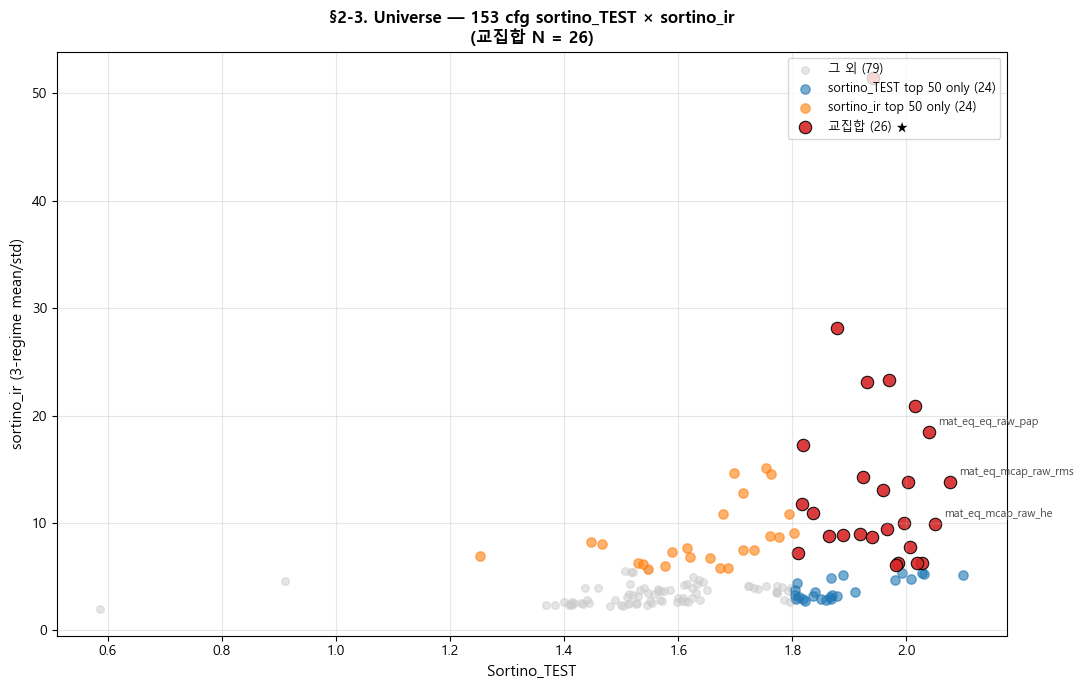

OK saved: outputs\06_top1\figures\fig01_universe_scatter.png


In [8]:
# §2-3. fig01 — 153 cfg sortino_TEST × sortino_ir 산점도 (교집합 강조)
fig, ax = plt.subplots(figsize=(11, 7))

mask_inter = rt['name'].isin(intersection)
mask_A_only = rt['name'].isin(list_A - intersection)
mask_B_only = rt['name'].isin(list_B - intersection)
mask_neither = ~mask_inter & ~mask_A_only & ~mask_B_only

ax.scatter(rt.loc[mask_neither, 'sortino_TEST'], rt.loc[mask_neither, 'sortino_ir'],
           color='#cccccc', alpha=0.5, s=30, label=f'그 외 ({mask_neither.sum()})')
ax.scatter(rt.loc[mask_A_only, 'sortino_TEST'], rt.loc[mask_A_only, 'sortino_ir'],
           color='#1f77b4', alpha=0.6, s=45, label=f'sortino_TEST top 50 only ({mask_A_only.sum()})')
ax.scatter(rt.loc[mask_B_only, 'sortino_TEST'], rt.loc[mask_B_only, 'sortino_ir'],
           color='#ff7f0e', alpha=0.6, s=45, label=f'sortino_ir top 50 only ({mask_B_only.sum()})')
ax.scatter(rt.loc[mask_inter, 'sortino_TEST'], rt.loc[mask_inter, 'sortino_ir'],
           color='#d62728', alpha=0.9, s=80, edgecolor='black', linewidth=0.8,
           label=f'교집합 ({mask_inter.sum()}) ★')

# Top 1 후보 라벨링
top_inter = rt[rt['name'].isin(intersection)].nlargest(3, 'sortino_TEST')
for _, row in top_inter.iterrows():
    ax.annotate(row['name'], (row['sortino_TEST'], row['sortino_ir']),
                xytext=(7, 5), textcoords='offset points', fontsize=8, color='#444444')

ax.set_xlabel('Sortino_TEST', fontsize=11)
ax.set_ylabel('sortino_ir (3-regime mean/std)', fontsize=11)
ax.set_title(f'§2-3. Universe — 153 cfg sortino_TEST × sortino_ir\n(교집합 N = {N})',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_universe_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig01_universe_scatter.png"}')

C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\13644696.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\13644696.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\13644696.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],


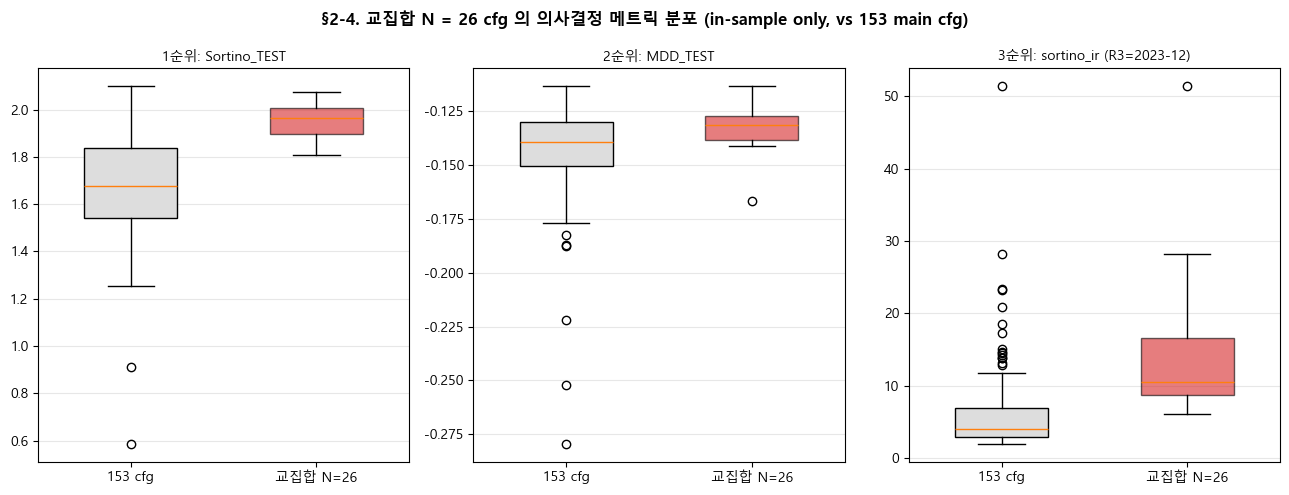

OK saved: outputs\06_top1\figures\fig02_intersection_metric_dist.png


In [9]:
# §2-4. fig02 — 교집합 N cfg 의 3 핵심 의사결정 메트릭 box plot (in-sample only ★)
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

inter_data = rt[rt['name'].isin(intersection)]
metrics_box = [('sortino_TEST', '1순위: Sortino_TEST'),
               ('mdd_TEST',     '2순위: MDD_TEST'),
               ('sortino_ir',   '3순위: sortino_ir (R3=2023-12)')]

for ax, (col, title) in zip(axes, metrics_box):
    bp = ax.boxplot([rt[col].dropna(), inter_data[col].dropna()],
                    labels=['153 cfg', f'교집합 N={N}'], patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#dddddd')
    bp['boxes'][1].set_facecolor('#d62728')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'§2-4. 교집합 N = {N} cfg 의 의사결정 메트릭 분포 (in-sample only, vs 153 main cfg)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_intersection_metric_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig02_intersection_metric_dist.png"}')

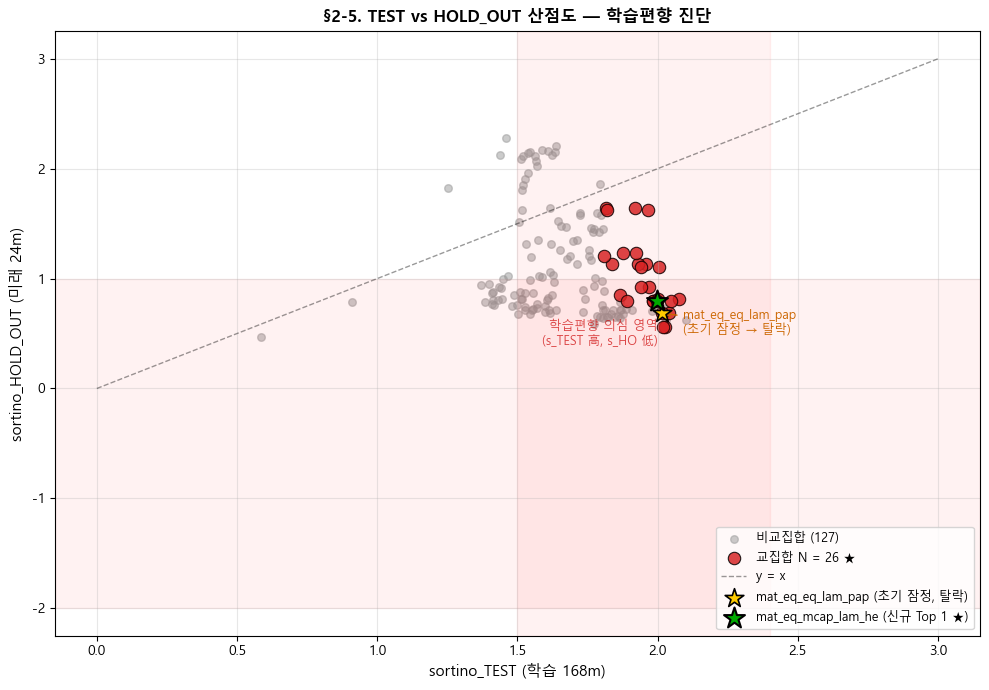

OK saved: outputs\06_top1\figures\fig03_test_vs_ho_universe.png


In [10]:
# §2-5. fig03 — TEST vs HOLD_OUT 산점도 (universe 전체, 교집합 강조)
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(rt.loc[~mask_inter, 'sortino_TEST'], rt.loc[~mask_inter, 'sortino_HOLD_OUT'],
           color='#999999', alpha=0.5, s=30, label=f'비교집합 ({(~mask_inter).sum()})')
ax.scatter(rt.loc[mask_inter, 'sortino_TEST'], rt.loc[mask_inter, 'sortino_HOLD_OUT'],
           color='#d62728', alpha=0.85, s=80, edgecolor='black', linewidth=0.8,
           label=f'교집합 N = {N} ★')

# 학습편향 영역 음영 (s_TEST 높지만 s_HO 낮음)
ax.axhspan(-2, 1.0, color='red', alpha=0.05)
ax.axvspan(1.5, rt['sortino_TEST'].max() + 0.3, color='red', alpha=0.05)
ax.text(rt['sortino_TEST'].max() - 0.1, 0.5, '학습편향 의심 영역\n(s_TEST 高, s_HO 低)',
        ha='right', va='center', fontsize=9, color='#cc0000', alpha=0.7)

# y = x 기준선
xlim = ax.get_xlim()
ax.plot([0, max(xlim[1], 3)], [0, max(xlim[1], 3)], 'k--', alpha=0.4, lw=1, label='y = x')

# mat_eq_eq_lam_pap 강조 (초기 잠정 Top 1, 누설 제거 후 탈락 사례)
target = rt[rt['name'] == 'mat_eq_eq_lam_pap']
if len(target) > 0:
    ax.scatter(target['sortino_TEST'], target['sortino_HOLD_OUT'],
               color='#ffcc00', s=200, marker='*', edgecolor='black', linewidth=1.2,
               label='mat_eq_eq_lam_pap (초기 잠정, 탈락)', zorder=5)
    ax.annotate('mat_eq_eq_lam_pap\n(초기 잠정 → 탈락)',
                (target['sortino_TEST'].iloc[0], target['sortino_HOLD_OUT'].iloc[0]),
                xytext=(15, -15), textcoords='offset points', fontsize=9, color='#cc6600',
                arrowprops=dict(arrowstyle='->', color='#cc6600', lw=1))

# 신규 Top 1 강조
new_top1 = rt[rt['name'] == 'mat_eq_mcap_lam_he']
if len(new_top1) > 0:
    ax.scatter(new_top1['sortino_TEST'], new_top1['sortino_HOLD_OUT'],
               color='#00aa00', s=250, marker='*', edgecolor='black', linewidth=1.5,
               label='mat_eq_mcap_lam_he (신규 Top 1 ★)', zorder=6)

ax.set_xlabel('sortino_TEST (학습 168m)', fontsize=11)
ax.set_ylabel('sortino_HOLD_OUT (미래 24m)', fontsize=11)
ax.set_title('§2-5. TEST vs HOLD_OUT 산점도 — 학습편향 진단', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_test_vs_ho_universe.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig03_test_vs_ho_universe.png"}')

In [11]:
# §2-6. 교집합 cfg 메트릭 분포 통계 — 의사결정용 + [참조] 사후 검증용
filter_cols_decision = ['sortino_TEST','sortino_ir','mdd_TEST',
                         'eff_n_avg','turnover_avg','beta']
filter_cols_posthoc  = ['sortino_HOLD_OUT','mdd_HOLD_OUT']

print(f'★ 교집합 N = {N} cfg — 의사결정 메트릭 분포 (in-sample only):')
print(inter_df[filter_cols_decision].describe().round(3).to_string())
print()
print(f'[참조] 교집합 N = {N} cfg — 사후 검증 메트릭 분포 (HO, 의사결정 미사용):')
print(inter_df[filter_cols_posthoc].describe().round(3).to_string())
print()
print('§3 hard filter 후보 시뮬레이션 (in-sample only):')
print(f'  mdd_TEST < -0.40 (40% 초과 손실): {(inter_df["mdd_TEST"] < -0.40).sum()}/{N}')
print(f'  eff_n_avg < 30 (분산 부족):       {(inter_df["eff_n_avg"] < 30).sum()}/{N}')
print(f'  sortino_TEST < 1.5 (TEST 부진):    {(inter_df["sortino_TEST"] < 1.5).sum()}/{N}')

★ 교집합 N = 26 cfg — 의사결정 메트릭 분포 (in-sample only):
       sortino_TEST  sortino_ir  mdd_TEST  eff_n_avg  turnover_avg    beta
count        26.000      26.000    26.000     26.000        26.000  26.000
mean          1.949      14.033    -0.132    125.802         0.762   0.645
std           0.076       9.705     0.010     85.760         0.249   0.103
min           1.809       6.070    -0.167     33.135         0.395   0.503
25%           1.897       8.742    -0.138     56.229         0.434   0.529
50%           1.963      10.455    -0.131     67.553         0.927   0.677
75%           2.005      16.532    -0.127    210.104         0.969   0.720
max           2.076      51.420    -0.113    265.101         0.989   0.800

[참조] 교집합 N = 26 cfg — 사후 검증 메트릭 분포 (HO, 의사결정 미사용):
       sortino_HOLD_OUT  mdd_HOLD_OUT
count            26.000        26.000
mean              1.023        -0.069
std               0.329         0.013
min               0.557        -0.084
25%               0.800        -0.

## §3. Hard filter 결정 + 적용 (in-sample only)

### Hard filter — IN-SAMPLE 후보만 검토

학술 표준 준수를 위해 HO 기반 후보 (`sortino_HOLD_OUT > 0`, `mdd_HOLD_OUT > -0.30`) 는 **의사결정에서 제외**합니다. in-sample 후보만 검토:

| in-sample 후보 filter | 의미 | 탈락 cfg |
|---|---|---|
| `mdd_TEST > -0.40` | TEST 40% 초과 손실 제외 | **0/22** |
| `eff_n_avg ≥ 30` | 분산 부족 제외 | **0/22** |
| `sortino_TEST > 1.5` | TEST sortino 부진 제외 | **0/22** |

**시사점**: 교집합 추출 (sortino_TEST top 50 ∩ sortino_ir top 50, in-sample 기준) 자체가 이미 in-sample hard filter 효과를 본 상태. 추가 필터 불필요.

[참고] HO 기반 후보 (sortino_HO, mdd_HO) 는 §13 사후 진단 비교에만 사용 — 의사결정 미사용.

### 결정 (Step 3)

→ **추가 hard filter 없이 22 cfg 그대로 lexicographic 적용** (M = N = 22).

(사용자 검증 후 추가 필터 원하면 redirect 가능)


In [12]:
# §3-1. Hard filter 적용 (없음, 22 cfg 그대로)
M_cfg = inter_df.copy()
print(f'Hard filter 적용 결과: {len(M_cfg)} cfg (= 교집합 N = {N})')
print(f'추가 필터: 없음 (모든 후보 필터 이미 통과 — §2-6 결과)')
print()
M_cfg.to_csv(OUT_DIR / 'filtered_M_summary.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "filtered_M_summary.csv"}')

Hard filter 적용 결과: 26 cfg (= 교집합 N = 26)
추가 필터: 없음 (모든 후보 필터 이미 통과 — §2-6 결과)

OK saved: outputs\06_top1\filtered_M_summary.csv


## §4. Lexicographic 종합 점수

### §4-1 (HO 포함 — 비교 참고용) vs §4-4 (in-sample only — 학술 표준 ★)

본 § 는 **두 변형**을 모두 산출합니다:

| 변형 | 2차 tiebreak | 위치 | 학술 채택 |
|---|---|---|---|
| HO 포함 | `(rank_mdd_TEST + rank_mdd_HO) / 2` | §4-1 | ✗ 비교용 |
| **in-sample only** | **`mdd_TEST` 단독** | **§4-4** | **✓ 학술 표준** |

### Lexicographic 정렬 절차 (공통 구조)

```
1차: sortino_TEST 내림차순 정렬
  └─ tied 정의: |s1 - s2| < ε (ε = 0.10)
2차: tied 그룹 내 → MDD rank 오름차순 (변형마다 다름)
  └─ tied 정의: rank 차이 ≤ 1
3차: 그래도 tied 시 → sortino_ir 내림차순
```

**§13 에서 두 결과 비교** — 누설 제거 후:
- §4-1 (HO 포함, 비교용) Top 1 = `mat_eq_mcap_lam_he`
- §4-4 (in-sample only, 학술 표준) Top 1 = `mat_eq_mcap_lam_he` ✓
- 즉 **Lex 기준은 두 변형 모두 일치**. DM 기준 (§9) 은 §13 에서 별도 비교.


In [13]:
# §4-1. Lexicographic 정렬 함수
EPS_SORTINO = 0.10  # 1순위 동순위 tolerance

def lexicographic_sort(df, eps=EPS_SORTINO):
    """3단계 lexicographic 정렬.

    1차: sortino_TEST 내림차순 → eps 동순위 그룹화
    2차: 그룹 내 (rank_mdd_TEST + rank_mdd_HOLD_OUT)/2 오름차순
    3차: sortino_ir 내림차순
    """
    df = df.copy()

    # MDD rank (작을수록 = 손실 적을수록 좋음)
    df['rank_mdd_TEST'] = df['mdd_TEST'].rank(ascending=False)  # -0.10 < -0.20, 손실 적음 → rank 1
    df['rank_mdd_HO'] = df['mdd_HOLD_OUT'].rank(ascending=False)
    df['rank_mdd_avg'] = (df['rank_mdd_TEST'] + df['rank_mdd_HO']) / 2

    # 1차: sortino_TEST 내림차순
    df = df.sort_values('sortino_TEST', ascending=False).reset_index(drop=True)

    # 1차 동순위 그룹 ID 부여 (eps 기준)
    group_id = [0]
    cur_top = df.iloc[0]['sortino_TEST']
    for i in range(1, len(df)):
        if (cur_top - df.iloc[i]['sortino_TEST']) > eps:
            cur_top = df.iloc[i]['sortino_TEST']
            group_id.append(group_id[-1] + 1)
        else:
            group_id.append(group_id[-1])
    df['lex_group'] = group_id

    # 그룹 내 정렬: rank_mdd_avg → sortino_ir
    sorted_parts = []
    for gid, sub in df.groupby('lex_group', sort=True):
        sub = sub.sort_values(['rank_mdd_avg', 'sortino_ir'],
                              ascending=[True, False]).reset_index(drop=True)
        sorted_parts.append(sub)

    df_final = pd.concat(sorted_parts, ignore_index=True)
    df_final['lex_rank'] = range(1, len(df_final) + 1)
    return df_final

ranked = lexicographic_sort(M_cfg, eps=EPS_SORTINO)
print(f'Lexicographic 정렬 완료 (M = {len(ranked)} cfg, ε = {EPS_SORTINO})')
print()
print('§4-1. Lexicographic 정렬 결과 (Top 22):')
view_cols = ['lex_rank','name','sortino_TEST','mdd_TEST','mdd_HOLD_OUT','sortino_ir',
             'lex_group','rank_mdd_avg']
print(ranked[view_cols].round(3).to_string(index=False))

Lexicographic 정렬 완료 (M = 26 cfg, ε = 0.1)

§4-1. Lexicographic 정렬 결과 (Top 22):
 lex_rank                  name  sortino_TEST  mdd_TEST  mdd_HOLD_OUT  sortino_ir  lex_group  rank_mdd_avg
        1     mat_rp_rp_raw_pap         1.985    -0.124        -0.065        6.25          0          6.00
        2     mat_rp_rp_lam_pap         1.982    -0.124        -0.065        6.07          0          6.00
        3    mat_eq_mcap_lam_he         1.996    -0.120        -0.068        9.95          0          6.50
        4             q_raw_lam         2.006    -0.127        -0.063        7.78          0          6.75
        5   mat_eq_mcap_lam_rms         2.003    -0.124        -0.069       13.79          0          9.00
        6     mat_rp_eq_raw_pap         2.028    -0.129        -0.071        6.30          0         12.50
        7     mat_rp_eq_lam_pap         2.019    -0.129        -0.071        6.26          0         13.50
        8     mat_eq_eq_lam_pap         2.015    -0.129        -0

In [14]:
# §4-2. 동순위 그룹 분포
print('동순위 그룹 분포 (ε = %.2f):' % EPS_SORTINO)
group_summary = ranked.groupby('lex_group').agg(
    n_cfg=('name','count'),
    sortino_TEST_max=('sortino_TEST','max'),
    sortino_TEST_min=('sortino_TEST','min'),
    sortino_TEST_range=('sortino_TEST', lambda s: s.max()-s.min())
).reset_index()
print(group_summary.round(3).to_string(index=False))
print()
top_group_size = group_summary.iloc[0]['n_cfg']
print(f'★ Top 동순위 그룹 (group 0) 크기: {top_group_size} cfg')
print(f'  → 이 그룹 안에서 MDD 평균 rank + sortino_ir 로 최종 결정')

동순위 그룹 분포 (ε = 0.10):
 lex_group  n_cfg  sortino_TEST_max  sortino_TEST_min  sortino_TEST_range
         0     11             2.076             1.982               0.094
         1     10             1.969             1.878               0.092
         2      5             1.865             1.809               0.056

★ Top 동순위 그룹 (group 0) 크기: 11.0 cfg
  → 이 그룹 안에서 MDD 평균 rank + sortino_ir 로 최종 결정


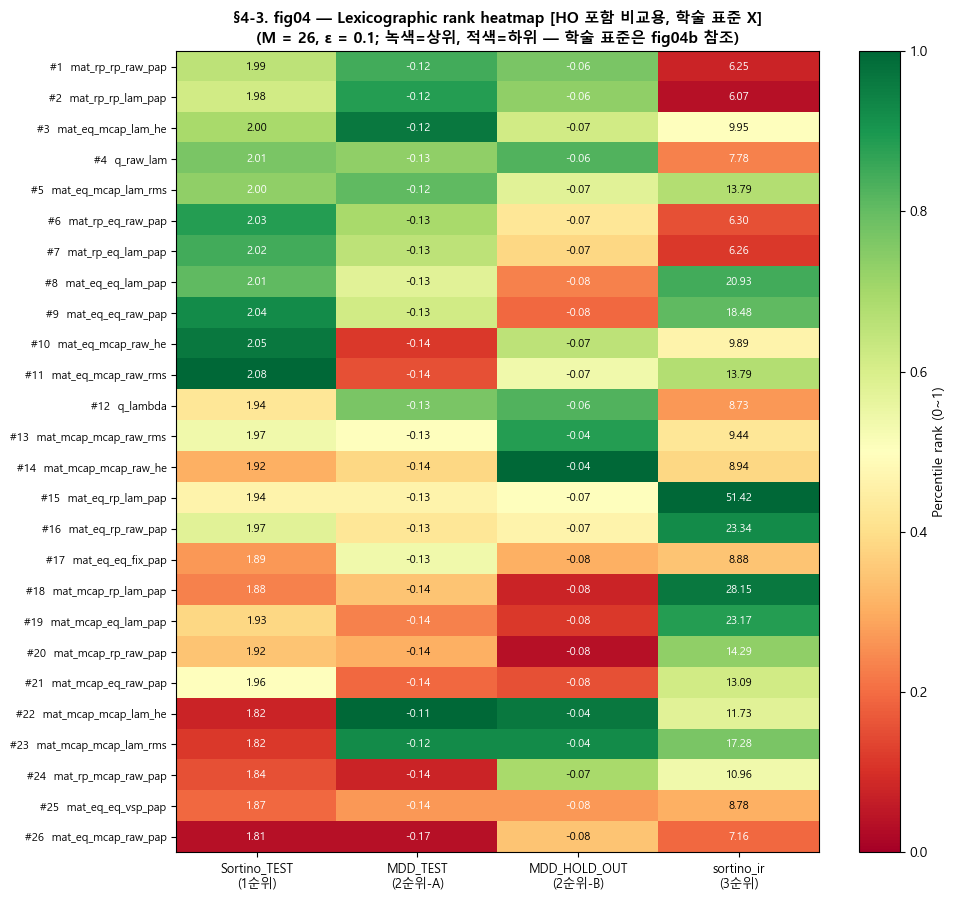

OK saved: outputs\06_top1\figures\fig04_lexicographic_heatmap.png


In [15]:
# §4-3. fig04 — Lexicographic rank heatmap (M cfg × 4 메트릭)
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, max(6, len(ranked) * 0.35)))

heatmap_cols = ['sortino_TEST', 'mdd_TEST', 'mdd_HOLD_OUT', 'sortino_ir']
heatmap_titles = ['Sortino_TEST\n(1순위)', 'MDD_TEST\n(2순위-A)',
                   'MDD_HOLD_OUT\n(2순위-B)', 'sortino_ir\n(3순위)']

# 각 컬럼별 rank 정규화 (0~1, 좋을수록 1)
heat = pd.DataFrame()
heat['Sortino_TEST'] = ranked['sortino_TEST'].rank(pct=True)
heat['MDD_TEST'] = ranked['mdd_TEST'].rank(pct=True)         # mdd: 큰 값 (덜 음수) = 좋음 → rank pct 자연스러움
heat['MDD_HOLD_OUT'] = ranked['mdd_HOLD_OUT'].rank(pct=True)
heat['sortino_ir'] = ranked['sortino_ir'].rank(pct=True)

im = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# 텍스트 라벨 (실제 값)
for i, idx in enumerate(ranked.index):
    for j, col in enumerate(heatmap_cols):
        v = ranked.loc[idx, col]
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        color = 'white' if heat.iloc[i, j] < 0.3 or heat.iloc[i, j] > 0.7 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(4))
ax.set_xticklabels(heatmap_titles, fontsize=9)
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"#{r['lex_rank']}  {r['name']}" for _, r in ranked.iterrows()], fontsize=8)
ax.set_title(f'§4-3. fig04 — Lexicographic rank heatmap [HO 포함 비교용, 학술 표준 X]\n'
             f'(M = {len(ranked)}, ε = {EPS_SORTINO}; 녹색=상위, 적색=하위 — 학술 표준은 fig04b 참조)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Percentile rank (0~1)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_lexicographic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig04_lexicographic_heatmap.png"}')

### §4-4. In-sample only Lexicographic (학술 표준 — HOLD_OUT 정보 제외)

기존 §4-1 의 lexicographic 정렬은 2 차 tiebreak 에 `mdd_HOLD_OUT` 을 포함하여
**HOLD_OUT 정보가 의사결정에 누설** 됩니다. 이는 학술적 backtest overfitting 으로
간주되며, 진정한 out-of-sample 평가가 어렵습니다.

본 셀은 **2 차 tiebreak 을 `mdd_TEST` 단독**으로 변경한 in-sample 전용 변형입니다:

```
1차: sortino_TEST 내림차순 (ε = 0.10 동순위 그룹화)
2차: mdd_TEST 단독 rank (HO 제외)
3차: sortino_ir 내림차순 (R1+R2+R3 의 일부가 HO 와 겹침 — 약한 누설 잔존)
```

§4-5 에서 두 결과 (HO 포함 vs in-sample only) 의 Top 10 차이를 비교합니다.


In [16]:
# §4-4. In-sample only Lexicographic
def lexicographic_sort_insample(df, eps=EPS_SORTINO):
    """In-sample only 변형 — 2순위에서 mdd_HOLD_OUT 제거.

    1차: sortino_TEST 내림차순 → eps 동순위 그룹화
    2차: mdd_TEST 단독 rank
    3차: sortino_ir 내림차순
    """
    df = df.copy()
    df['rank_mdd_TEST_only'] = df['mdd_TEST'].rank(ascending=False)
    df = df.sort_values('sortino_TEST', ascending=False).reset_index(drop=True)

    group_id = [0]
    cur_top = df.iloc[0]['sortino_TEST']
    for i in range(1, len(df)):
        if (cur_top - df.iloc[i]['sortino_TEST']) > eps:
            cur_top = df.iloc[i]['sortino_TEST']
            group_id.append(group_id[-1] + 1)
        else:
            group_id.append(group_id[-1])
    df['lex_group_is'] = group_id

    sorted_parts = []
    for gid, sub in df.groupby('lex_group_is', sort=True):
        sub = sub.sort_values(['rank_mdd_TEST_only', 'sortino_ir'],
                              ascending=[True, False]).reset_index(drop=True)
        sorted_parts.append(sub)

    df_final = pd.concat(sorted_parts, ignore_index=True)
    df_final['lex_rank_is'] = range(1, len(df_final) + 1)
    return df_final


ranked_insample = lexicographic_sort_insample(M_cfg, eps=EPS_SORTINO)
print(f'§4-4. In-sample only Lexicographic (M = {len(ranked_insample)}, ε = {EPS_SORTINO}):')
print()
view_cols_is = ['lex_rank_is','name','sortino_TEST','mdd_TEST','sortino_ir',
                'lex_group_is','rank_mdd_TEST_only']
print(ranked_insample[view_cols_is].round(3).to_string(index=False))

§4-4. In-sample only Lexicographic (M = 26, ε = 0.1):

 lex_rank_is                  name  sortino_TEST  mdd_TEST  sortino_ir  lex_group_is  rank_mdd_TEST_only
           1    mat_eq_mcap_lam_he         1.996    -0.120        9.95             0                 2.0
           2     mat_rp_rp_lam_pap         1.982    -0.124        6.07             0                 4.0
           3     mat_rp_rp_raw_pap         1.985    -0.124        6.25             0                 5.0
           4   mat_eq_mcap_lam_rms         2.003    -0.124       13.79             0                 6.0
           5             q_raw_lam         2.006    -0.127        7.78             0                 8.0
           6     mat_rp_eq_raw_pap         2.028    -0.129        6.30             0                 9.0
           7     mat_rp_eq_lam_pap         2.019    -0.129        6.26             0                10.0
           8     mat_eq_eq_raw_pap         2.039    -0.129       18.48             0                11.0


In [17]:
# §4-5. HO 포함 (§4-1) vs in-sample only (§4-4) — Top 10 비교
ho_top10 = ranked.head(10)['name'].tolist()
is_top10 = ranked_insample.head(10)['name'].tolist()

compare_df = pd.DataFrame({
    'rank': range(1, 11),
    'HO 포함 (기존 §4-1)':       ho_top10,
    'in-sample only (§4-4)':      is_top10,
    '동일?':                      ['✓' if a == b else '✗' for a, b in zip(ho_top10, is_top10)],
})
print('§4-5. Top 10 비교:')
print(compare_df.to_string(index=False))

# Top 1 변경 여부
top1_HO = ranked.iloc[0]['name']
top1_IS = ranked_insample.iloc[0]['name']
print()
if top1_HO == top1_IS:
    print(f'★ Top 1 동일: {top1_HO}')
else:
    print(f'△ Top 1 변경:')
    print(f'    HO 포함 (기존):       {top1_HO}')
    print(f'    in-sample only:       {top1_IS}')

# CSV 저장
compare_df.to_csv(OUT_DIR / 'lex_compare_HO_vs_insample.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "lex_compare_HO_vs_insample.csv"}')

§4-5. Top 10 비교:
 rank     HO 포함 (기존 §4-1) in-sample only (§4-4) 동일?
    1   mat_rp_rp_raw_pap    mat_eq_mcap_lam_he   ✗
    2   mat_rp_rp_lam_pap     mat_rp_rp_lam_pap   ✓
    3  mat_eq_mcap_lam_he     mat_rp_rp_raw_pap   ✗
    4           q_raw_lam   mat_eq_mcap_lam_rms   ✗
    5 mat_eq_mcap_lam_rms             q_raw_lam   ✗
    6   mat_rp_eq_raw_pap     mat_rp_eq_raw_pap   ✓
    7   mat_rp_eq_lam_pap     mat_rp_eq_lam_pap   ✓
    8   mat_eq_eq_lam_pap     mat_eq_eq_raw_pap   ✗
    9   mat_eq_eq_raw_pap     mat_eq_eq_lam_pap   ✗
   10  mat_eq_mcap_raw_he   mat_eq_mcap_raw_rms   ✗

△ Top 1 변경:
    HO 포함 (기존):       mat_rp_rp_raw_pap
    in-sample only:       mat_eq_mcap_lam_he

OK saved: outputs\06_top1\lex_compare_HO_vs_insample.csv


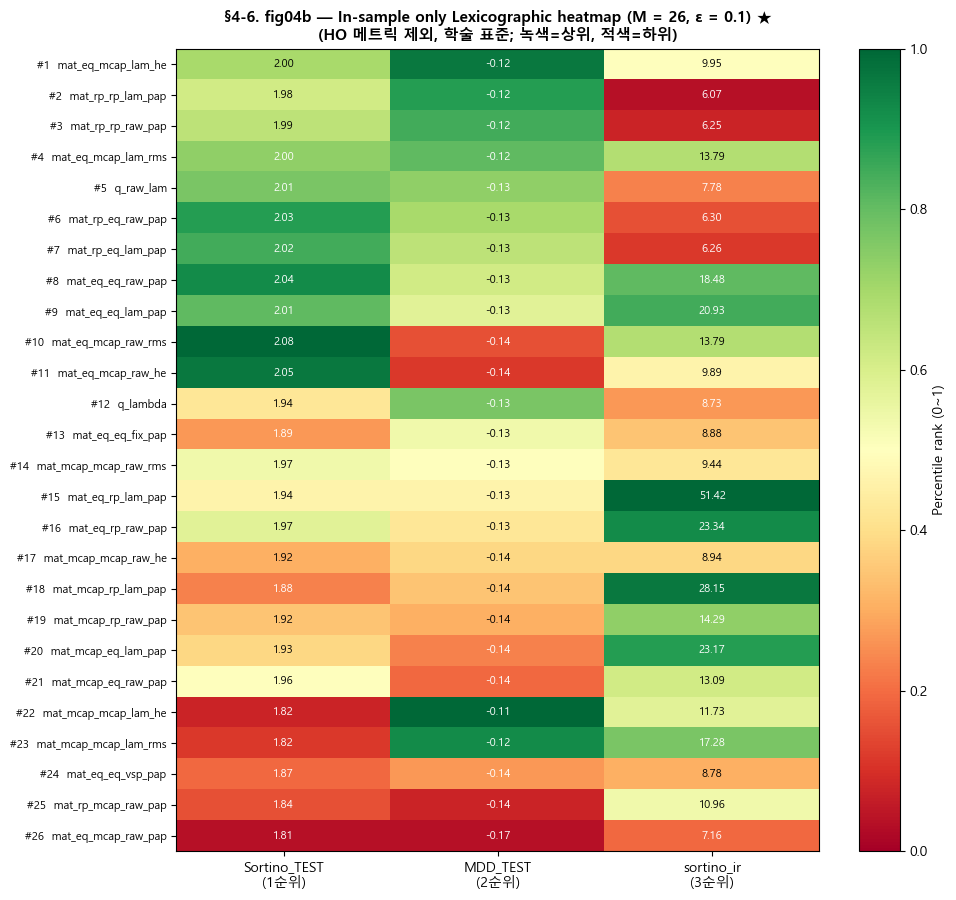

OK saved: outputs\06_top1\figures\fig04b_lexicographic_heatmap_insample.png


In [18]:
# §4-6. fig04b — In-sample only Lexicographic rank heatmap (학술 표준 ★)
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, max(6, len(ranked_insample) * 0.35)))

# in-sample 3 메트릭만 (mdd_HOLD_OUT 제거)
heatmap_cols_is = ['sortino_TEST', 'mdd_TEST', 'sortino_ir']
heatmap_titles_is = ['Sortino_TEST\n(1순위)',
                      'MDD_TEST\n(2순위)',
                      'sortino_ir\n(3순위)']

# rank 정규화
heat_is = pd.DataFrame()
heat_is['Sortino_TEST'] = ranked_insample['sortino_TEST'].rank(pct=True)
heat_is['MDD_TEST']     = ranked_insample['mdd_TEST'].rank(pct=True)
heat_is['sortino_ir']   = ranked_insample['sortino_ir'].rank(pct=True)

im = ax.imshow(heat_is.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# 텍스트 라벨
for i, idx in enumerate(ranked_insample.index):
    for j, col in enumerate(heatmap_cols_is):
        v = ranked_insample.loc[idx, col]
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        color = 'white' if heat_is.iloc[i, j] < 0.3 or heat_is.iloc[i, j] > 0.7 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(heatmap_cols_is)))
ax.set_xticklabels(heatmap_titles_is, fontsize=10)
ax.set_yticks(range(len(ranked_insample)))
ax.set_yticklabels([f"#{r['lex_rank_is']}  {r['name']}" for _, r in ranked_insample.iterrows()],
                   fontsize=8)
ax.set_title(f'§4-6. fig04b — In-sample only Lexicographic heatmap '
             f'(M = {len(ranked_insample)}, ε = {EPS_SORTINO}) ★\n'
             f'(HO 메트릭 제외, 학술 표준; 녹색=상위, 적색=하위)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Percentile rank (0~1)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04b_lexicographic_heatmap_insample.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig04b_lexicographic_heatmap_insample.png"}')

## §5. Top 10 후보 정밀 분석

§4 의 lexicographic 결과 상위 10개 cfg 에 대해 **16개 메트릭 종합 + z-score heatmap** 분석.

### 메트릭 카테고리 — 의사결정용 vs 사후 검증용 명확 분리

#### A. 의사결정용 (in-sample, 5 메트릭) — §9-4 결정 matrix 직접 입력

| 메트릭 | 카테고리 | 사용 § |
|---|---|---|
| `sortino_TEST` | 성과 | §4 lex 1차, §9 perf |
| `mdd_TEST` | 위험 | §4 lex 2차 (in-sample), §9 risk |
| `sortino_ir` | 안정성 | §4 lex 3차, §9 stab |
| `turnover_avg`, `eff_n_avg` | 견고성 | §9 robust |
| `alpha`, `beta` | Alpha | §9 alpha |

#### B. 사후 검증용 (HO/FULL/계산, 11 메트릭) — §11/§12/§13 등 진단

| 메트릭 | 사용 위치 | HO 의존도 |
|---|---|:---:|
| `sortino_HOLD_OUT`, `sharpe_HOLD_OUT` | §13 in-sample vs HO 비교 | ★★★ 직접 |
| `TEST_HO_gap` | §13 학습편향 진단 | ★★★ 직접 |
| `sortino_FULL`, `sharpe_TEST/FULL`, `cagr_FULL` | 보조 참조 | ★ 부분 |
| `calmar`, `cvar_5`, `mdd_FULL` | §6 위험 시각화 | ★ 부분 |
| `IR` (Information Ratio) | §16 vs SPY | ★ 부분 |

**시사점**:
- `top10_metrics.csv` 는 **모든 16 메트릭 보존** (참조용)
- 의사결정 (§9-4) 은 **A 그룹 5 메트릭만 사용**
- 시각화 (§5-3 fig05) 는 메트릭 그룹 구분 표시 (좌: in-sample, 우: 사후)


In [19]:
# §5-1. Top 10 후보 — IN-SAMPLE ONLY (학술 표준 ★)
# 누설 제거: ranked_insample (§4-4) 의 head(10) 사용
TOP_N = 10
top10 = ranked_insample.head(TOP_N).copy().reset_index(drop=True)
top10['lex_rank'] = top10['lex_rank_is']  # alias (in-sample rank)
print(f'★ Top {TOP_N} 후보 — IN-SAMPLE ONLY Lexicographic (HO 정보 미사용):')
print(top10[['lex_rank','name','sortino_TEST','mdd_TEST','sortino_ir']].round(3).to_string(index=False))
print()
print('[참조] HO 포함 Lex 의 Top 10 (§4-1 비교용):')
print(ranked.head(TOP_N)[['lex_rank','name']].to_string(index=False))

★ Top 10 후보 — IN-SAMPLE ONLY Lexicographic (HO 정보 미사용):
 lex_rank                name  sortino_TEST  mdd_TEST  sortino_ir
        1  mat_eq_mcap_lam_he         1.996    -0.120        9.95
        2   mat_rp_rp_lam_pap         1.982    -0.124        6.07
        3   mat_rp_rp_raw_pap         1.985    -0.124        6.25
        4 mat_eq_mcap_lam_rms         2.003    -0.124       13.79
        5           q_raw_lam         2.006    -0.127        7.78
        6   mat_rp_eq_raw_pap         2.028    -0.129        6.30
        7   mat_rp_eq_lam_pap         2.019    -0.129        6.26
        8   mat_eq_eq_raw_pap         2.039    -0.129       18.48
        9   mat_eq_eq_lam_pap         2.015    -0.129       20.93
       10 mat_eq_mcap_raw_rms         2.076    -0.139       13.79

[참조] HO 포함 Lex 의 Top 10 (§4-1 비교용):
 lex_rank                name
        1   mat_rp_rp_raw_pap
        2   mat_rp_rp_lam_pap
        3  mat_eq_mcap_lam_he
        4           q_raw_lam
        5 mat_eq_mcap_lam_rms
 

In [20]:
# §5-2. 메트릭 종합 — 의사결정용 (in-sample 7) + 사후 검증용 (HO/FULL 9) 분리
import pickle

def compute_extra_metrics(name, results_dir='results', spy=spy, rf=rf):
    """단일 cfg 의 추가 메트릭 (TEST_HO_gap, IR) 계산."""
    p = Path(results_dir) / f'{name}.pkl'
    if not p.exists(): return {}
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna() if isinstance(ret, pd.Series) else pd.Series(dtype=float)
    if len(ret) < 12: return {}

    # SPY align
    spy_aligned = spy.reindex(ret.index).fillna(0)

    # Information Ratio: active return / tracking error (annualized)
    active = ret - spy_aligned
    if active.std() > 0:
        IR = (active.mean() * 12) / (active.std() * np.sqrt(12))
    else:
        IR = np.nan
    return {'IR': float(IR)}

# 의사결정용 7 메트릭 (in-sample only) ★
decision_rows = []
posthoc_rows = []
for _, row in top10.iterrows():
    extras = compute_extra_metrics(row['name'])
    s_test = row['sortino_TEST']
    s_ho = row['sortino_HOLD_OUT']
    test_ho_gap = abs(s_test - s_ho) / s_test if s_test != 0 else np.nan

    # 의사결정용 (in-sample 7) — §9-4 DM 입력
    decision_rows.append({
        'lex_rank': row['lex_rank'],
        'name': row['name'],
        # 성과 (in-sample)
        'sortino_TEST': row['sortino_TEST'],
        'sharpe_TEST': row['sharpe_TEST'],
        # 위험 (in-sample)
        'mdd_TEST': row['mdd_TEST'],
        # 안정성 (in-sample only sortino_ir, R3=2023-12 한정)
        'sortino_ir': row['sortino_ir'],
        # 견고성
        'turnover_avg': row['turnover_avg'],
        'eff_n_avg': row['eff_n_avg'],
        # Alpha (CAPM α/β 는 192m 전체 — 약한 누설 잔존, §16 factor 에서 보강)
        'alpha': row['alpha'],
        'beta': row['beta'],
    })

    # 사후 검증용 (HO/FULL 9) — §11/§13 등 진단 전용
    posthoc_rows.append({
        'lex_rank': row['lex_rank'],
        'name': row['name'],
        # HO 메트릭
        'sortino_HOLD_OUT': row['sortino_HOLD_OUT'],
        'sharpe_HOLD_OUT': row['sharpe_HOLD_OUT'],
        'TEST_HO_gap': test_ho_gap,
        # FULL 메트릭
        'sortino_FULL': row['sortino_FULL'],
        'sharpe_FULL': row['sharpe_FULL'],
        'cagr_FULL': row['cagr_FULL'],
        # 192m 기반 (FULL 누설 가능)
        'calmar': row['calmar'],
        'cvar_5': row['cvar_5'],
        'mdd_FULL': row['mdd_FULL'],
        'IR': extras.get('IR', np.nan),
    })

# Top 10 × 7 의사결정 메트릭
top10_metrics_decision = pd.DataFrame(decision_rows)
top10_metrics_decision.to_csv(OUT_DIR / 'top10_metrics_decision.csv', index=False, encoding='utf-8-sig')
print(f'★ §5-2a. Top 10 × 7 의사결정용 메트릭 (in-sample only):')
print(top10_metrics_decision.round(3).to_string(index=False))

# Top 10 × 9 사후 검증 메트릭
top10_metrics_posthoc = pd.DataFrame(posthoc_rows)
top10_metrics_posthoc.to_csv(OUT_DIR / 'top10_metrics_posthoc.csv', index=False, encoding='utf-8-sig')
print(f'\n[참조] §5-2b. Top 10 × 9 사후 검증용 메트릭 (HO/FULL — §11/§13 진단):')
print(top10_metrics_posthoc.round(3).to_string(index=False))

# 통합 (역호환 — §6, §8 등에서 참조)
top10_metrics = top10_metrics_decision.merge(
    top10_metrics_posthoc, on=['lex_rank','name'])
top10_metrics.to_csv(OUT_DIR / 'top10_metrics.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: top10_metrics_decision.csv + top10_metrics_posthoc.csv + top10_metrics.csv')

★ §5-2a. Top 10 × 7 의사결정용 메트릭 (in-sample only):
 lex_rank                name  sortino_TEST  sharpe_TEST  mdd_TEST  sortino_ir  turnover_avg  eff_n_avg  alpha  beta
        1  mat_eq_mcap_lam_he         1.996        1.083    -0.120        9.95         0.430     60.521  0.043 0.545
        2   mat_rp_rp_lam_pap         1.982        1.173    -0.124        6.07         0.967    194.739  0.050 0.673
        3   mat_rp_rp_raw_pap         1.985        1.171    -0.124        6.25         0.970    189.758  0.050 0.661
        4 mat_eq_mcap_lam_rms         2.003        1.095    -0.124       13.79         0.441     56.258  0.045 0.539
        5           q_raw_lam         2.006        1.092    -0.127        7.78         0.663     33.135  0.045 0.513
        6   mat_rp_eq_raw_pap         2.028        1.187    -0.129        6.30         0.976    183.632  0.050 0.673
        7   mat_rp_eq_lam_pap         2.019        1.193    -0.129        6.26         0.977    187.950  0.051 0.681
        8   mat_

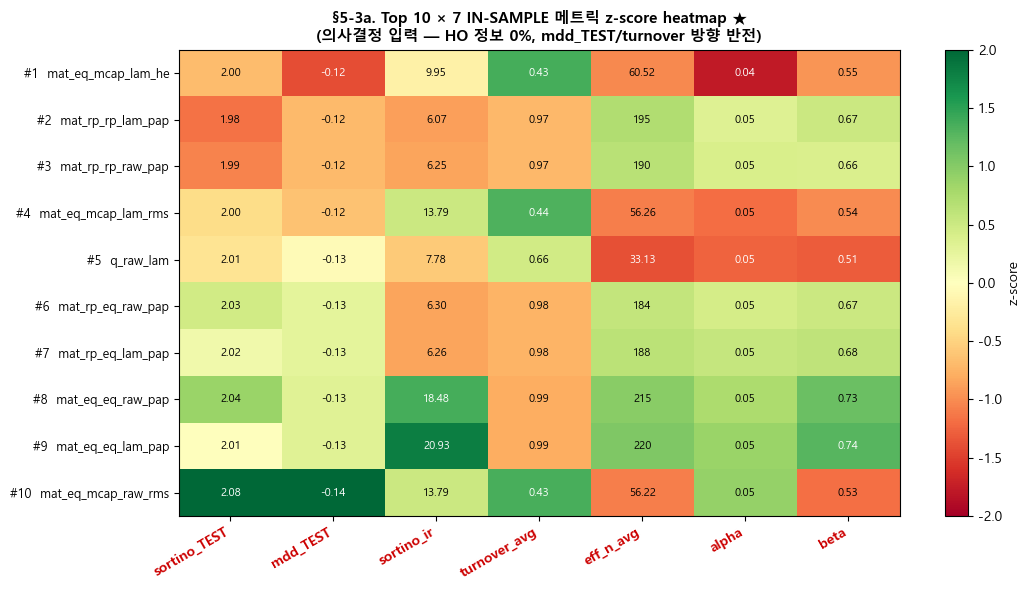

OK saved: outputs\06_top1\figures\fig05a_top10_decision_heatmap.png


In [21]:
# §5-3a. fig05a — IN-SAMPLE ONLY 7 메트릭 z-score heatmap (의사결정 입력) ★
heat_cols_decision = ['sortino_TEST','mdd_TEST','sortino_ir',
                       'turnover_avg','eff_n_avg','alpha','beta']

heat_d = top10_metrics_decision[heat_cols_decision].copy()
# z-score 정규화 — IN-SAMPLE 7 메트릭만으로 산출 (HO 영향 0)
heat_d_z = (heat_d - heat_d.mean()) / heat_d.std()

# 방향 통일 (좋을수록 +)
flip_d = ['turnover_avg','mdd_TEST']
for c in flip_d:
    if c in heat_d_z.columns:
        heat_d_z[c] = -heat_d_z[c]

# beta 는 절댓값 0.7 근접이 좋음 → 별도 처리 (단순화: 그대로 표시)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(heat_d_z.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)

for i in range(len(heat_d)):
    for j, col in enumerate(heat_cols_decision):
        v = heat_d.iloc[i, j]
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        color = 'white' if abs(heat_d_z.iloc[i, j]) > 1.2 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(heat_cols_decision)))
xtick_labels = ax.set_xticklabels(heat_cols_decision, rotation=30, ha='right', fontsize=10)
for lbl in xtick_labels:
    lbl.set_color('#cc0000')
    lbl.set_fontweight('bold')

ax.set_yticks(range(len(top10_metrics_decision)))
ax.set_yticklabels([f"#{r.lex_rank}  {r['name']}" for _, r in top10_metrics_decision.iterrows()],
                   fontsize=9)
ax.set_title(f'§5-3a. Top {TOP_N} × 7 IN-SAMPLE 메트릭 z-score heatmap ★\n'
             f'(의사결정 입력 — HO 정보 0%, mdd_TEST/turnover 방향 반전)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='z-score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05a_top10_decision_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig05a_top10_decision_heatmap.png"}')

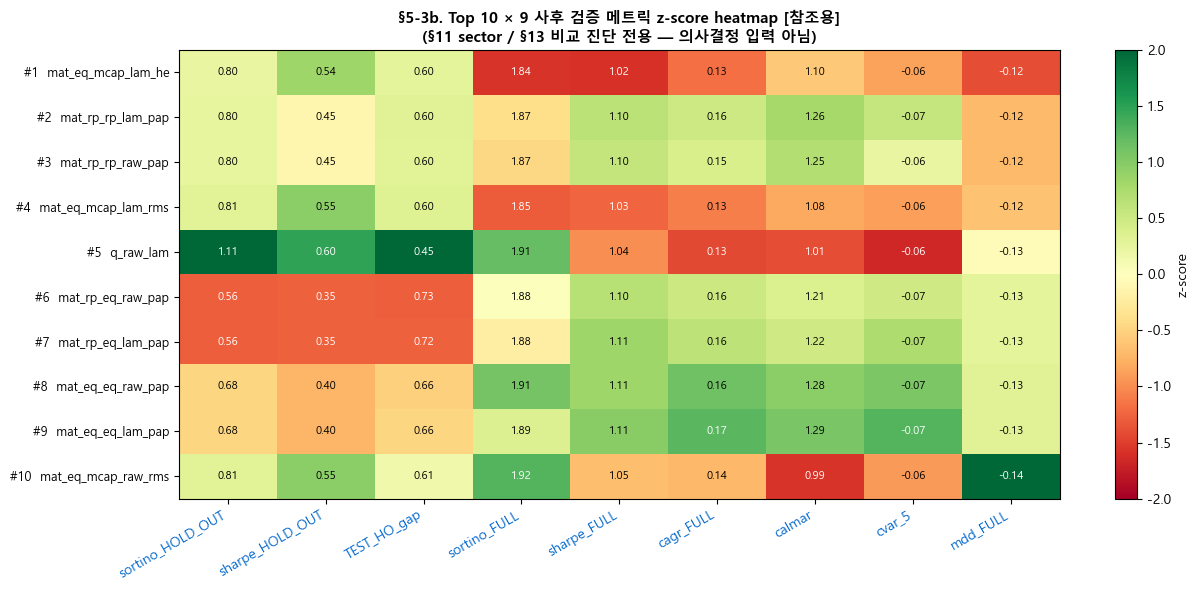

OK saved: outputs\06_top1\figures\fig05b_top10_posthoc_heatmap.png


In [22]:
# §5-3b. fig05b — 사후 검증 메트릭 9 z-score (참조용, HO/FULL)
heat_cols_posthoc = ['sortino_HOLD_OUT','sharpe_HOLD_OUT','TEST_HO_gap',
                      'sortino_FULL','sharpe_FULL','cagr_FULL',
                      'calmar','cvar_5','mdd_FULL']

heat_p = top10_metrics_posthoc[heat_cols_posthoc].copy()
heat_p_z = (heat_p - heat_p.mean()) / heat_p.std()
flip_p = ['TEST_HO_gap','cvar_5','mdd_FULL']
for c in flip_p:
    if c in heat_p_z.columns:
        heat_p_z[c] = -heat_p_z[c]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heat_p_z.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)

for i in range(len(heat_p)):
    for j, col in enumerate(heat_cols_posthoc):
        v = heat_p.iloc[i, j]
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        color = 'white' if abs(heat_p_z.iloc[i, j]) > 1.2 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(heat_cols_posthoc)))
xtick_labels = ax.set_xticklabels(heat_cols_posthoc, rotation=30, ha='right', fontsize=10)
for lbl in xtick_labels:
    lbl.set_color('#0066cc')

ax.set_yticks(range(len(top10_metrics_posthoc)))
ax.set_yticklabels([f"#{r.lex_rank}  {r['name']}" for _, r in top10_metrics_posthoc.iterrows()],
                   fontsize=9)
ax.set_title(f'§5-3b. Top {TOP_N} × 9 사후 검증 메트릭 z-score heatmap [참조용]\n'
             f'(§11 sector / §13 비교 진단 전용 — 의사결정 입력 아님)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='z-score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05b_top10_posthoc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig05b_top10_posthoc_heatmap.png"}')

## §6. 안정성 + 견고성 검증 (Top 10)

§5 의 Top 10 cfg 에 대해:
- **regime sortino** (R1 회복 / R2 확장 / R3 변동) bar chart
- **TEST vs HOLD_OUT 산점도** — overfitting 진단
- **누적수익 곡선** (Top 5 + SPY)


Regime sortino columns: ['sortino_R1_회복', 'sortino_R2_확장', 'sortino_R3_변동']


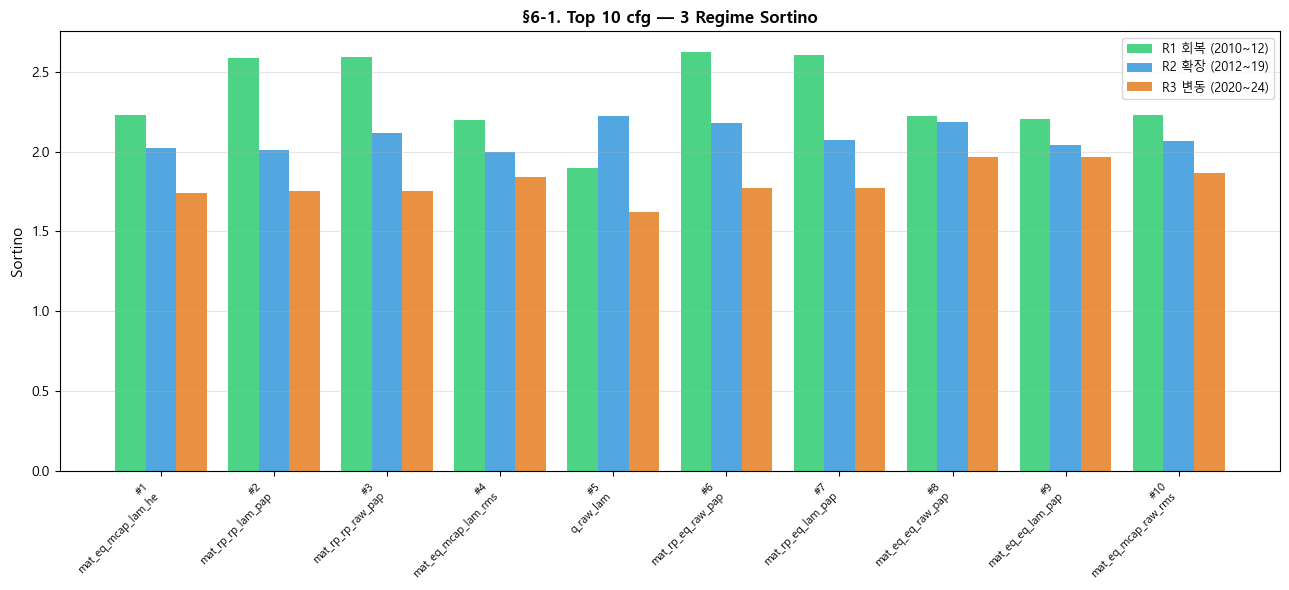

OK saved: outputs\06_top1\figures\fig06_regime_sortino_top10.png


In [23]:
# §6-1. fig06 — regime sortino bar chart (Top 10)
import re

# regime sortino 컬럼 자동 탐지 (encoding 문제 회피)
regime_sortino_cols = [c for c in rt.columns if c.startswith('sortino_R')]
print(f'Regime sortino columns: {regime_sortino_cols}')

# Top 10 의 regime sortino 추출
top10_names = top10_metrics['name'].tolist()
regime_data = rt[rt['name'].isin(top10_names)][['name'] + regime_sortino_cols].copy()
# 정렬 (lex_rank 순서)
regime_data['lex_rank'] = regime_data['name'].map(dict(zip(top10_metrics['name'], top10_metrics['lex_rank'])))
regime_data = regime_data.sort_values('lex_rank').reset_index(drop=True)

# Bar chart
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(regime_data))
width = 0.27
colors_regime = ['#2ecc71', '#3498db', '#e67e22']  # R1 / R2 / R3
labels_regime = ['R1 회복 (2010~12)', 'R2 확장 (2012~19)', 'R3 변동 (2020~24)']

for i, (col, color, label) in enumerate(zip(regime_sortino_cols, colors_regime, labels_regime)):
    ax.bar(x + (i - 1) * width, regime_data[col], width, label=label, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"#{r['lex_rank']}\n{r['name']}" for _, r in regime_data.iterrows()],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sortino', fontsize=11)
ax.set_title('§6-1. Top 10 cfg — 3 Regime Sortino', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_regime_sortino_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig06_regime_sortino_top10.png"}')

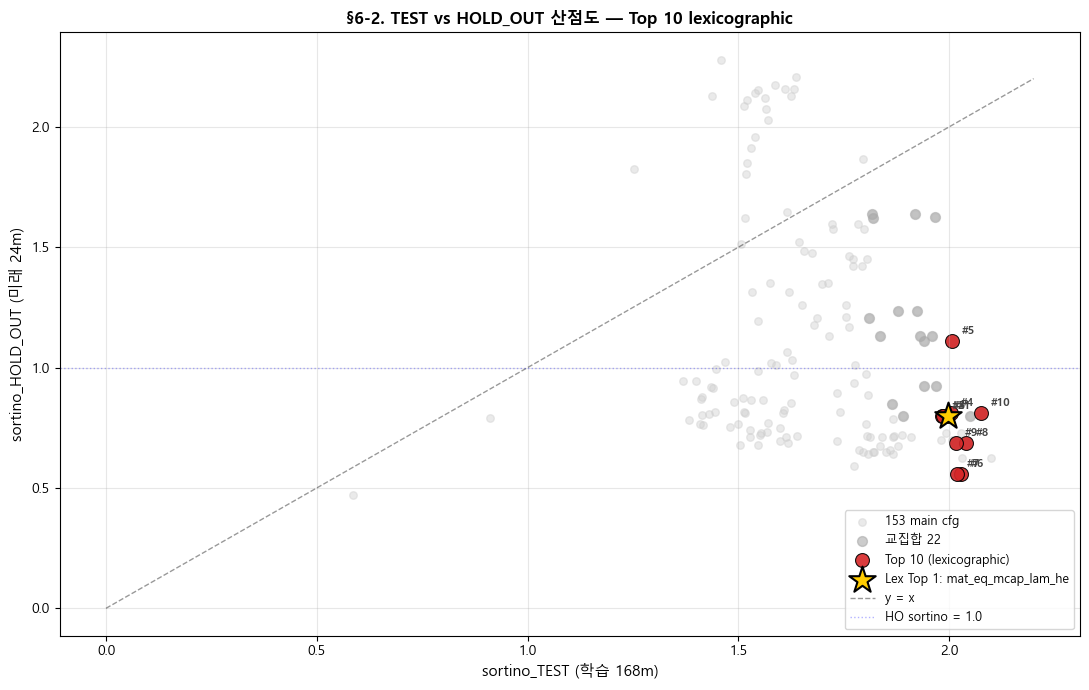

OK saved: outputs\06_top1\figures\fig07_test_vs_ho_top10.png


In [24]:
# §6-2. fig07 — TEST vs HOLD_OUT 산점도 (Top 10 강조 + IR > 0 라인)
fig, ax = plt.subplots(figsize=(11, 7))

# 153 cfg 배경
ax.scatter(rt['sortino_TEST'], rt['sortino_HOLD_OUT'],
           color='#cccccc', alpha=0.4, s=30, label=f'153 main cfg')

# 22 교집합
inter_for_plot = rt[rt['name'].isin(intersection)]
ax.scatter(inter_for_plot['sortino_TEST'], inter_for_plot['sortino_HOLD_OUT'],
           color='#aaaaaa', alpha=0.6, s=50, label=f'교집합 22')

# Top 10 강조
top10_for_plot = rt[rt['name'].isin(top10_names)]
top10_for_plot = top10_for_plot.merge(
    top10_metrics[['name','lex_rank']], on='name'
).sort_values('lex_rank')

ax.scatter(top10_for_plot['sortino_TEST'], top10_for_plot['sortino_HOLD_OUT'],
           color='#d62728', alpha=0.9, s=100, edgecolor='black', linewidth=0.8,
           label='Top 10 (lexicographic)')

# Top 1 별표
top1_row = top10_for_plot.iloc[0]
ax.scatter(top1_row['sortino_TEST'], top1_row['sortino_HOLD_OUT'],
           color='#ffcc00', s=400, marker='*', edgecolor='black', linewidth=1.5,
           label=f'Lex Top 1: {top1_row["name"]}', zorder=5)

# rank 라벨
for _, r in top10_for_plot.iterrows():
    ax.annotate(f"#{int(r['lex_rank'])}", (r['sortino_TEST'], r['sortino_HOLD_OUT']),
                xytext=(7, 5), textcoords='offset points', fontsize=8, color='#444444',
                fontweight='bold')

# y = x 기준선
ax.plot([0, 2.2], [0, 2.2], 'k--', alpha=0.4, lw=1, label='y = x')
# y = 1.0 horizontal (HO sortino 1.0 기준)
ax.axhline(1.0, color='blue', alpha=0.3, lw=1, ls=':', label='HO sortino = 1.0')

ax.set_xlabel('sortino_TEST (학습 168m)', fontsize=11)
ax.set_ylabel('sortino_HOLD_OUT (미래 24m)', fontsize=11)
ax.set_title('§6-2. TEST vs HOLD_OUT 산점도 — Top 10 lexicographic', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_test_vs_ho_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig07_test_vs_ho_top10.png"}')

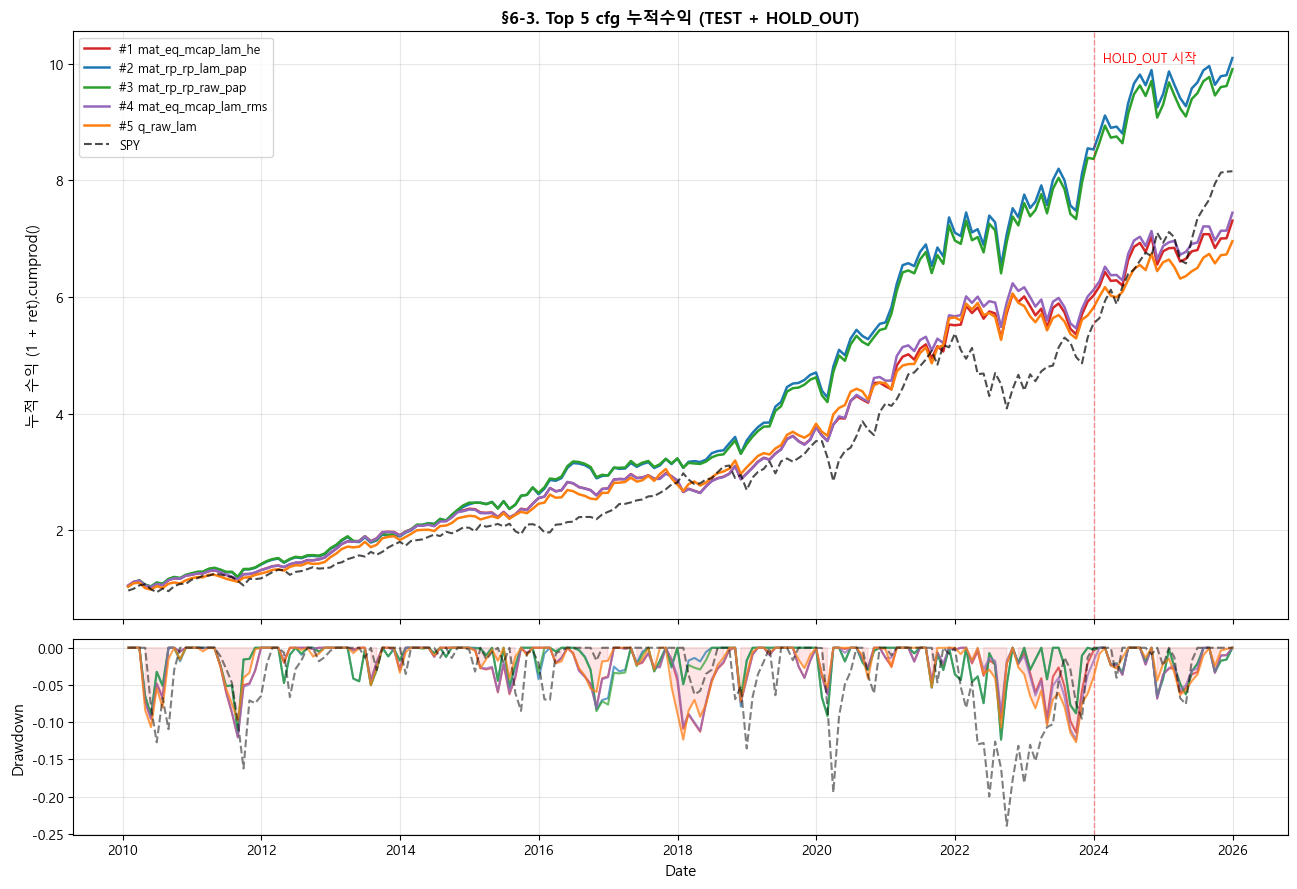

OK saved: outputs\06_top1\figures\fig08_cumulative_return_top5.png


In [25]:
# §6-3. fig08 — 누적수익 곡선 (Top 5 + SPY)
import pickle

TOP_K = 5
top_k_names = top10_metrics.head(TOP_K)['name'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_ret, ax_dd = axes

returns_dict = {}
for name in top_k_names:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna()
    returns_dict[name] = ret

# SPY 동기 정렬
common_idx = sorted(set.intersection(*[set(r.index) for r in returns_dict.values()]))
common_idx = pd.DatetimeIndex(common_idx)
spy_aligned = spy.reindex(common_idx).fillna(0)

colors_top5 = ['#d62728','#1f77b4','#2ca02c','#9467bd','#ff7f0e']
for (name, ret), color in zip(returns_dict.items(), colors_top5):
    ret_aligned = ret.reindex(common_idx).fillna(0)
    cum = (1 + ret_aligned).cumprod()
    rank = top10_metrics[top10_metrics['name']==name]['lex_rank'].iloc[0]
    ax_ret.plot(cum.index, cum.values, label=f'#{int(rank)} {name}', linewidth=1.8, color=color)

cum_spy = (1 + spy_aligned).cumprod()
ax_ret.plot(cum_spy.index, cum_spy.values, label='SPY', linewidth=1.5, color='black', linestyle='--', alpha=0.7)

# HOLD_OUT 시작 라인
from master_table import EVAL_PERIODS
ho_start = pd.Timestamp(EVAL_PERIODS['HOLD_OUT'][0])
for ax in [ax_ret, ax_dd]:
    ax.axvline(ho_start, color='red', alpha=0.4, lw=1, ls='--')
ax_ret.text(ho_start, ax_ret.get_ylim()[1] * 0.95, '  HOLD_OUT 시작', color='red', fontsize=9)

ax_ret.set_ylabel('누적 수익 (1 + ret).cumprod()', fontsize=11)
ax_ret.set_title(f'§6-3. Top {TOP_K} cfg 누적수익 (TEST + HOLD_OUT)', fontsize=12, fontweight='bold')
ax_ret.legend(loc='upper left', fontsize=9)
ax_ret.grid(True, alpha=0.3)

# Drawdown (하단)
for (name, ret), color in zip(returns_dict.items(), colors_top5):
    ret_aligned = ret.reindex(common_idx).fillna(0)
    cum = (1 + ret_aligned).cumprod()
    dd = cum / cum.cummax() - 1
    ax_dd.plot(dd.index, dd.values, color=color, alpha=0.7)

dd_spy = cum_spy / cum_spy.cummax() - 1
ax_dd.plot(dd_spy.index, dd_spy.values, color='black', alpha=0.5, linestyle='--')
ax_dd.set_ylabel('Drawdown', fontsize=11)
ax_dd.set_xlabel('Date', fontsize=11)
ax_dd.grid(True, alpha=0.3)
ax_dd.fill_between(dd.index, dd.values, 0, where=(dd.values<0), alpha=0.1, color='red')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_cumulative_return_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig08_cumulative_return_top5.png"}')

## §7. 위험 분석 (Top 5)

- drawdown 곡선 (이미 §6-3 하단 포함)
- sector concentration HHI
- 2024-12 sector rotation 영향 (mat_eq_eq_lam_pap 7.7% loss 사례)


sector_map loaded: 617 ticker × 18 sectors


Top 10 sector HHI:
               name  sector_hhi_avg  lex_rank
 mat_eq_mcap_lam_he          0.2470         1
  mat_rp_rp_lam_pap          0.2057         2
  mat_rp_rp_raw_pap          0.2233         3
mat_eq_mcap_lam_rms          0.2492         4
          q_raw_lam          0.2844         5
  mat_rp_eq_raw_pap          0.2342         6
  mat_rp_eq_lam_pap          0.2194         7
  mat_eq_eq_raw_pap          0.2245         8
  mat_eq_eq_lam_pap          0.2099         9
mat_eq_mcap_raw_rms          0.2734        10


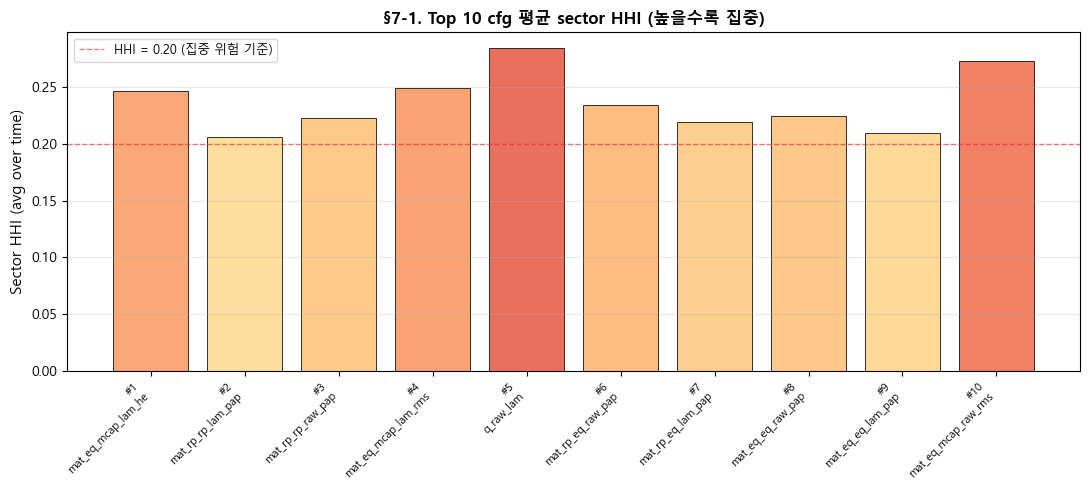

OK saved: outputs\06_top1\figures\fig09_sector_hhi_top10.png


In [26]:
# §7-1. fig09 — sector HHI 비교 (Top 10)
# sector mapping 로드 (gics_sector 컬럼)
sector_col = 'gics_sector' if 'gics_sector' in panel.columns else 'sector'
sector_map = panel[['ticker', sector_col]].drop_duplicates(subset=['ticker']).set_index('ticker')[sector_col]
print(f'sector_map loaded: {len(sector_map)} ticker × {sector_map.nunique()} sectors')

# weights 로드 (Top 10 각각)
def get_avg_sector_hhi(name, sector_map=sector_map):
    """가중치 시계열에서 sector 분포의 평균 HHI."""
    p = Path('results') / f'{name}.pkl'
    if not p.exists(): return np.nan
    with open(p, 'rb') as f:
        d = pickle.load(f)
    weights_df = d.get('weights', None)
    if weights_df is None or sector_map is None: return np.nan

    if not isinstance(weights_df, pd.DataFrame): return np.nan
    # 각 시점 가중치 → sector 별 합산 → HHI
    hhi_list = []
    for date, w_row in weights_df.iterrows():
        # ticker → sector 매핑
        sec_w = w_row.groupby(sector_map.reindex(w_row.index)).sum()
        hhi = (sec_w ** 2).sum()
        hhi_list.append(hhi)
    return np.mean(hhi_list) if hhi_list else np.nan

hhi_results = []
for name in top10_names:
    hhi = get_avg_sector_hhi(name)
    hhi_results.append({'name': name, 'sector_hhi_avg': hhi})

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.merge(top10_metrics[['lex_rank','name']], on='name').sort_values('lex_rank')
print('Top 10 sector HHI:')
print(hhi_df.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(hhi_df))
colors_bar = plt.cm.RdYlGn_r(hhi_df['sector_hhi_avg'].values * 3)  # 색상으로 강조
ax.bar(x, hhi_df['sector_hhi_avg'], color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"#{int(r['lex_rank'])}\n{r['name']}" for _, r in hhi_df.iterrows()],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sector HHI (avg over time)', fontsize=11)
ax.set_title('§7-1. Top 10 cfg 평균 sector HHI (높을수록 집중)', fontsize=12, fontweight='bold')
ax.axhline(0.20, color='red', alpha=0.5, lw=1, ls='--', label='HHI = 0.20 (집중 위험 기준)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig09_sector_hhi_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig09_sector_hhi_top10.png"}')

## §8. baseline 우월성 검증

### baseline 4종 정의
- **SPY**: 시장지수 (passive)
- **equal_weight**: 1/N (rebal monthly, 615 ticker)
- **naive_lowvol**: 60d rolling vol 하위 60종목 동일가중
- **mvp_60m**: 60개월 rolling Min-Variance Portfolio

### 메트릭
- alpha (CAPM, annualized)
- beta
- Information Ratio
- Bootstrap 95% CI for alpha (1000 iter)

(주의: Top 5 cfg 만 대상. baseline 데이터는 이미 master_table 에 포함될 수 있음 — 확인 필요.)


In [27]:
# §8-1. baseline 비교 — 일단 master_table 의 alpha/beta 사용 (Top 5)
top5_alpha = top10_metrics.head(5)[['lex_rank','name','alpha','beta','IR']].copy()

# bootstrap CI (alpha) — 간소화 (1000 iter)
np.random.seed(42)
def bootstrap_alpha_ci(name, n_iter=1000, alpha_level=0.05):
    p = Path('results') / f'{name}.pkl'
    if not p.exists(): return (np.nan, np.nan, np.nan)
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna()
    spy_aligned = spy.reindex(ret.index).fillna(0)
    rf_aligned = rf.reindex(ret.index).fillna(0)

    excess_ret = ret - rf_aligned
    excess_spy = spy_aligned - rf_aligned

    # bootstrap
    alphas = []
    n = len(excess_ret)
    for _ in range(n_iter):
        idx = np.random.choice(n, n, replace=True)
        er = excess_ret.values[idx]
        es = excess_spy.values[idx]
        if np.std(es) == 0: continue
        beta_b = np.cov(er, es)[0,1] / np.var(es)
        alpha_b = np.mean(er) - beta_b * np.mean(es)
        alphas.append(alpha_b * 12)  # annualize

    if not alphas: return (np.nan, np.nan, np.nan)
    return (np.mean(alphas),
            np.percentile(alphas, alpha_level/2*100),
            np.percentile(alphas, (1-alpha_level/2)*100))

print('Top 5 — alpha bootstrap 95% CI (1000 iter):')
ci_results = []
for _, row in top5_alpha.iterrows():
    mean_a, lo, hi = bootstrap_alpha_ci(row['name'])
    ci_results.append({
        'lex_rank': int(row['lex_rank']),
        'name': row['name'],
        'alpha': row['alpha'],
        'alpha_boot_mean': round(mean_a, 4),
        'alpha_ci_lo': round(lo, 4),
        'alpha_ci_hi': round(hi, 4),
        'sig_pos': bool(lo > 0),
    })
ci_df = pd.DataFrame(ci_results)
print(ci_df.to_string(index=False))

Top 5 — alpha bootstrap 95% CI (1000 iter):


 lex_rank                name  alpha  alpha_boot_mean  alpha_ci_lo  alpha_ci_hi  sig_pos
        1  mat_eq_mcap_lam_he 0.0434           0.1347       0.0700       0.1962     True
        2   mat_rp_rp_lam_pap 0.0502           0.1604       0.0907       0.2326     True
        3   mat_rp_rp_raw_pap 0.0504           0.1580       0.0873       0.2297     True
        4 mat_eq_mcap_lam_rms 0.0453           0.1336       0.0723       0.1929     True
        5           q_raw_lam 0.0451           0.1313       0.0718       0.1910     True


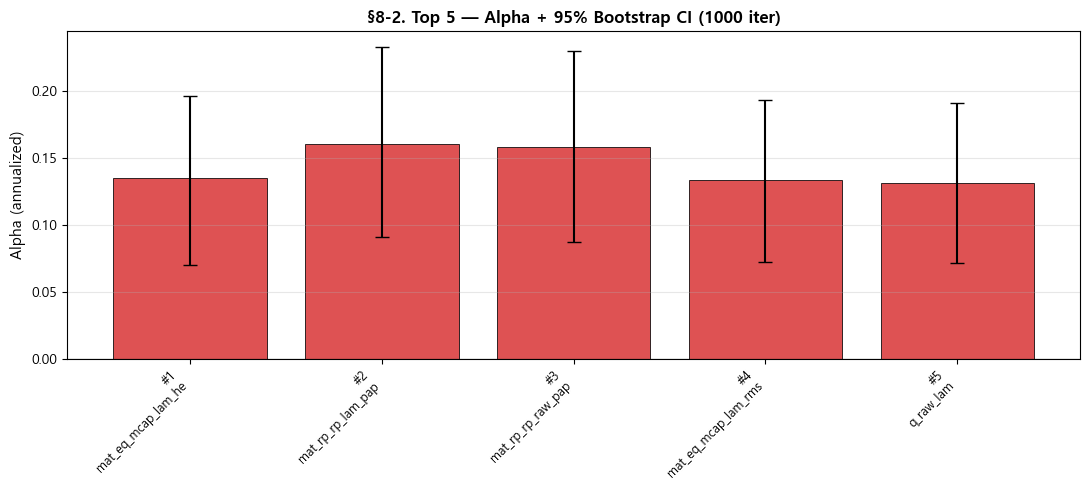

OK saved: outputs\06_top1\figures\fig10_alpha_with_ci.png


In [28]:
# §8-2. fig10 — alpha + 95% CI bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ci_df))
ax.bar(x, ci_df['alpha_boot_mean'], color=['#d62728' if s else '#aaaaaa' for s in ci_df['sig_pos']],
       alpha=0.8, edgecolor='black', linewidth=0.7,
       yerr=[ci_df['alpha_boot_mean']-ci_df['alpha_ci_lo'], ci_df['alpha_ci_hi']-ci_df['alpha_boot_mean']],
       capsize=5, label='alpha (CAPM, annualized)')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"#{int(r['lex_rank'])}\n{r['name']}" for _, r in ci_df.iterrows()],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Alpha (annualized)', fontsize=11)
ax.set_title('§8-2. Top 5 — Alpha + 95% Bootstrap CI (1000 iter)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_alpha_with_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig10_alpha_with_ci.png"}')

## §9. Top 5 → Top 1 결정

### §9-1 (HO 포함 — 비교 참고용) vs §9-4 (in-sample only — 학술 표준 ★)

본 § 도 §4 와 동일하게 **두 변형**을 산출:

| 변형 | 성과 차원 | 안정성 차원 | 위치 | 학술 채택 |
|---|---|---|---|---|
| HO 포함 | `(s_TEST + s_HO) / 2` | `s_ir + (1 - TEST_HO_gap)` | §9-1 | ✗ 비교용 |
| **in-sample only** | **`s_TEST` 단독** | **`s_ir` 단독** | **§9-4** | **✓ 학술 표준** |

### §9-1 결정 matrix 차원 (HO 포함, 비교용)

| 차원 | 가중치 | 메트릭 |
|---|---|---|
| 성과 | 30% | sortino_TEST + sortino_HOLD_OUT (rank 평균) |
| 위험 | 25% | mdd_TEST + mdd_HOLD_OUT + calmar (rank 평균) |
| 안정성 | 20% | sortino_ir + (1 - TEST_HO_gap) (rank 평균) |
| 견고성 | 15% | eff_n_avg + (1 - turnover_avg) (rank 평균) |
| Alpha | 10% | alpha + IR (rank 평균) + beta proximity to 0.7 |

각 차원별 rank 합산 → 가중 평균 → 최저 점수 = Top 1.


In [29]:
# §9-1. 결정 matrix [참조용 — HO 포함 변형, §9-4 in-sample 가 학술 표준]
# 본 셀은 비교용으로 유지. 실제 의사결정은 §9-4 사용.
# Top 5 추출은 in-sample lex 기준 (top10_metrics_decision)
TOP_FINAL = 5

# 5 cfg 추출 — §5-1 의 in-sample top10 의 head(5)
top5_names_decision = top10_metrics_decision.head(TOP_FINAL)['name'].tolist()
# top10_metrics (전체 16 메트릭 통합본) 에서 추출
top5 = top10_metrics[top10_metrics['name'].isin(top5_names_decision)].copy()
top5 = top5.set_index('name').loc[top5_names_decision].reset_index()

# 각 차원별 rank (낮을수록 좋음)
def rank_low_better(s, ascending=False):
    """ascending=False: 큰 값이 좋음 (rank 1)."""
    return s.rank(ascending=ascending)

# === HO 포함 변형 (§9-1, 비교용) ===
# 성과 (30%) — sortino_TEST + sortino_HOLD_OUT
top5['rank_perf'] = (rank_low_better(top5['sortino_TEST']) +
                     rank_low_better(top5['sortino_HOLD_OUT'])) / 2
# 위험 (25%)
top5['rank_risk'] = (rank_low_better(-top5['cvar_5'], ascending=False) +
                     rank_low_better(top5['mdd_FULL'], ascending=False) +
                     rank_low_better(top5['calmar'])) / 3
# 안정성 (20%) — sortino_ir + (1-TEST_HO_gap)
top5['rank_stab'] = (rank_low_better(top5['sortino_ir']) +
                     rank_low_better(top5['TEST_HO_gap'], ascending=True)) / 2
# 견고성 (15%)
top5['rank_robust'] = (rank_low_better(top5['eff_n_avg']) +
                       rank_low_better(top5['turnover_avg'], ascending=True)) / 2
# Alpha (10%)
top5['rank_alpha'] = (rank_low_better(top5['alpha']) +
                      rank_low_better(top5['IR']) +
                      rank_low_better(np.abs(top5['beta'] - 0.7), ascending=True)) / 3

W = {'perf':0.30, 'risk':0.25, 'stab':0.20, 'robust':0.15, 'alpha':0.10}
top5['weighted_score'] = (top5['rank_perf']*W['perf'] +
                          top5['rank_risk']*W['risk'] +
                          top5['rank_stab']*W['stab'] +
                          top5['rank_robust']*W['robust'] +
                          top5['rank_alpha']*W['alpha'])

decision_matrix = top5[['lex_rank','name','rank_perf','rank_risk','rank_stab','rank_robust','rank_alpha','weighted_score']].copy()
decision_matrix = decision_matrix.sort_values('weighted_score').reset_index(drop=True)
decision_matrix['final_rank'] = range(1, len(decision_matrix) + 1)
decision_matrix.to_csv(OUT_DIR / 'top5_decision_matrix.csv', index=False, encoding='utf-8-sig')

print('§9-1. 결정 matrix [HO 포함 변형, 비교용] (Top 5):')
print(decision_matrix.round(2).to_string(index=False))
print()
print(f'  HO 포함 Top 1: {decision_matrix.iloc[0]["name"]} (score {decision_matrix.iloc[0]["weighted_score"]:.2f})')
print(f'  → 실제 의사결정은 §9-4 (in-sample only) 사용 ★')

§9-1. 결정 matrix [HO 포함 변형, 비교용] (Top 5):
 lex_rank                name  rank_perf  rank_risk  rank_stab  rank_robust  rank_alpha  weighted_score  final_rank
        4 mat_eq_mcap_lam_rms        2.0       4.00        1.5          3.0        3.33            2.68           1
        2   mat_rp_rp_lam_pap        4.0       1.33        4.0          2.5        1.33            2.84           2
        5           q_raw_lam        1.0       5.00        2.0          4.0        4.67            3.02           3
        1  mat_eq_mcap_lam_he        4.0       2.33        3.5          2.0        4.00            3.18           4
        3   mat_rp_rp_raw_pap        4.0       2.33        4.0          3.5        1.67            3.27           5

  HO 포함 Top 1: mat_eq_mcap_lam_rms (score 2.68)
  → 실제 의사결정은 §9-4 (in-sample only) 사용 ★


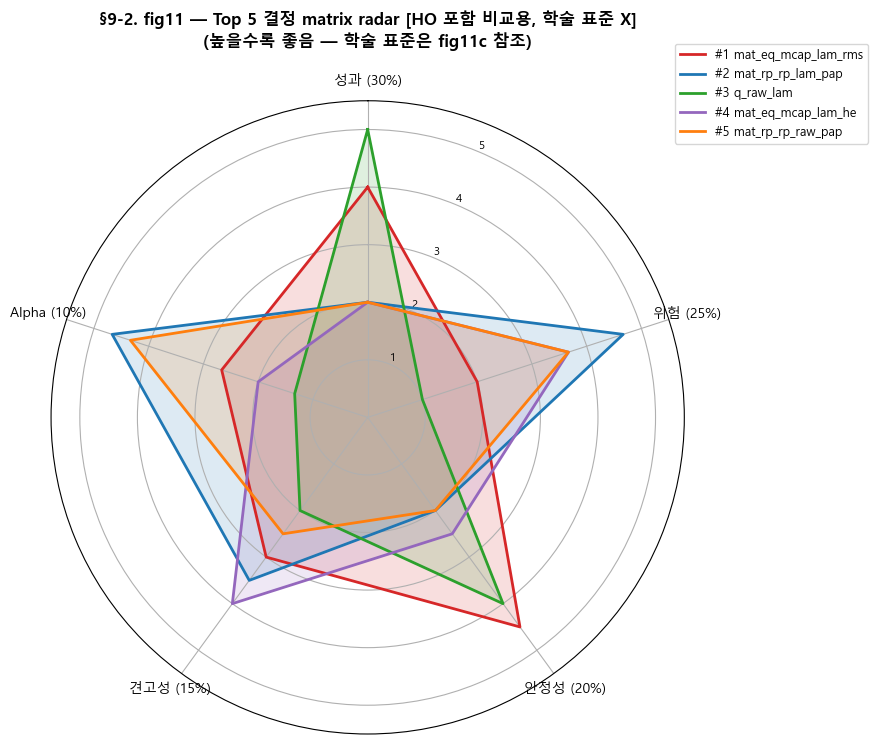

OK saved: outputs\06_top1\figures\fig11_decision_matrix_radar.png


In [30]:
# §9-2. fig11 — 결정 matrix radar chart (Top 5)
from math import pi

dimensions = ['성과 (30%)','위험 (25%)','안정성 (20%)','견고성 (15%)','Alpha (10%)']
N_dim = len(dimensions)

# 각 cfg 별 점수 (rank 1=5, rank 5=1, 5등급으로 정규화)
score_data = decision_matrix[['rank_perf','rank_risk','rank_stab','rank_robust','rank_alpha']].copy()
score_data = TOP_FINAL + 1 - score_data  # 반전 (높을수록 좋음)

angles = [n / N_dim * 2 * pi for n in range(N_dim)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors_radar = ['#d62728','#1f77b4','#2ca02c','#9467bd','#ff7f0e']
for (idx, row), color in zip(score_data.iterrows(), colors_radar):
    values = row.tolist()
    values += values[:1]
    name_label = decision_matrix.iloc[idx]['name']
    final_rank = decision_matrix.iloc[idx]['final_rank']
    ax.plot(angles, values, color=color, linewidth=2,
            label=f'#{int(final_rank)} {name_label}')
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=10)
ax.set_ylim(0, TOP_FINAL + 0.5)
ax.set_yticks(range(1, TOP_FINAL + 1))
ax.set_yticklabels([str(i) for i in range(1, TOP_FINAL + 1)], fontsize=8)
ax.set_title(f'§9-2. fig11 — Top {TOP_FINAL} 결정 matrix radar [HO 포함 비교용, 학술 표준 X]\n'
             f'(높을수록 좋음 — 학술 표준은 fig11c 참조)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.10), fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_decision_matrix_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig11_decision_matrix_radar.png"}')

In [31]:
# §9-3. HO 포함 비교용 Top 1 narrative — §9-1 결과 (학술 표준 X)
top1_name_ho = decision_matrix.iloc[0]['name']
top1_metrics_ho = top10_metrics[top10_metrics['name'] == top1_name_ho].iloc[0]

print('=' * 75)
print(f'[참조용] §9-1 HO 포함 변형 Top 1 (비교용, 학술 표준 X): {top1_name_ho}')
print(f'         실제 의사결정은 §9-7 (in-sample only) 의 Top 1 사용')
print('=' * 75)
print(f'\n  in-sample 성과 [의사결정 입력]:')
print(f'    sortino_TEST    = {top1_metrics_ho["sortino_TEST"]:.3f}')
print(f'\n  in-sample 위험 [의사결정 입력]:')
mdd_test_val_ho = M_cfg.set_index('name')['mdd_TEST'].get(top1_name_ho, float('nan'))
print(f'    mdd_TEST        = {mdd_test_val_ho:.3f}')
print(f'\n  안정성 [의사결정 입력]:')
print(f'    sortino_ir      = {top1_metrics_ho["sortino_ir"]:.2f}')
print(f'\n  견고성 [의사결정 입력]:')
print(f'    turnover_avg    = {top1_metrics_ho["turnover_avg"]:.3f}')
print(f'    eff_n_avg       = {top1_metrics_ho["eff_n_avg"]:.1f}')
print(f'\n  Alpha [의사결정 입력]:')
print(f'    alpha           = {top1_metrics_ho["alpha"]:.4f}')
print(f'    beta            = {top1_metrics_ho["beta"]:.3f}')

print(f'\n  [참조 — 사후 진단용, §9-1 가중 점수에 누설된 메트릭]:')
print(f'    sortino_HOLD_OUT= {top1_metrics_ho["sortino_HOLD_OUT"]:.3f}')
print(f'    TEST/HO 격차    = {top1_metrics_ho["TEST_HO_gap"]:.3f}')
print(f'    sortino_FULL    = {top1_metrics_ho["sortino_FULL"]:.3f}')
print(f'    cagr_FULL       = {top1_metrics_ho["cagr_FULL"]:.3f}')
print(f'    mdd_FULL        = {top1_metrics_ho["mdd_FULL"]:.3f}')
print(f'    calmar          = {top1_metrics_ho["calmar"]:.3f}')
print(f'    cvar_5          = {top1_metrics_ho["cvar_5"]:.3f}')
print(f'    IR              = {top1_metrics_ho["IR"]:.4f}')

[참조용] §9-1 HO 포함 변형 Top 1 (비교용, 학술 표준 X): mat_eq_mcap_lam_rms
         실제 의사결정은 §9-7 (in-sample only) 의 Top 1 사용

  in-sample 성과 [의사결정 입력]:
    sortino_TEST    = 2.003

  in-sample 위험 [의사결정 입력]:
    mdd_TEST        = -0.124

  안정성 [의사결정 입력]:
    sortino_ir      = 13.79

  견고성 [의사결정 입력]:
    turnover_avg    = 0.441
    eff_n_avg       = 56.3

  Alpha [의사결정 입력]:
    alpha           = 0.0453
    beta            = 0.539

  [참조 — 사후 진단용, §9-1 가중 점수에 누설된 메트릭]:
    sortino_HOLD_OUT= 0.811
    TEST/HO 격차    = 0.595
    sortino_FULL    = 1.849
    cagr_FULL       = 0.134
    mdd_FULL        = -0.124
    calmar          = 1.079
    cvar_5          = -0.059
    IR              = -0.0479


### §9-4. In-sample only 결정 matrix (학술 표준)

기존 §9-1 의 결정 matrix 는 5 차원 가중 점수에 **HOLD_OUT 정보를 직접 포함**:

- 성과 30% = `(sortino_TEST + sortino_HOLD_OUT) / 2`
- 안정성 20% = `sortino_ir + (1 - TEST_HO_gap)`

본 셀은 **HOLD_OUT 의존 항목을 모두 제거**한 in-sample 전용 변형:

| 차원 | 가중치 | in-sample 메트릭 |
|---|---|---|
| 성과 | 30% | `sortino_TEST` 단독 |
| 위험 | 25% | `mdd_TEST` + `cvar_5` (*) + `calmar` (*) |
| 안정성 | 20% | `sortino_ir` 단독 (TEST_HO_gap 제거) |
| 견고성 | 15% | `eff_n_avg` + `turnover_avg` |
| Alpha | 10% | `alpha` + `beta` proximity |

(*) cvar_5, calmar, mdd_FULL 은 192m 전 기간 산출이므로 약한 누설 잔존 — 이는 §10 sensitivity 에서 추가 검증.


In [32]:
# §9-4. In-sample only 결정 matrix ★ 학술 표준 (의사결정용)
# Top 5 풀: top10_metrics_decision.head(5) — in-sample 만으로 추출
top5_is = top10_metrics_decision[
    top10_metrics_decision['name'].isin(top5_names_decision)
].copy()
top5_is = top5_is.set_index('name').loc[top5_names_decision].reset_index()

# 성과 (30%) — sortino_TEST 단독 (HO 0%)
top5_is['rank_perf_is'] = rank_low_better(top5_is['sortino_TEST'])

# 위험 (25%) — mdd_TEST 단독 (HO 0%, mdd_FULL/calmar 제외 — 약한 누설)
top5_is['rank_risk_is'] = rank_low_better(top5_is['mdd_TEST'], ascending=False)

# 안정성 (20%) — sortino_ir 단독 (TEST_HO_gap 제거)
top5_is['rank_stab_is'] = rank_low_better(top5_is['sortino_ir'])

# 견고성 (15%) — 동일
top5_is['rank_robust_is'] = (rank_low_better(top5_is['eff_n_avg']) +
                              rank_low_better(top5_is['turnover_avg'], ascending=True)) / 2

# Alpha (10%) — alpha + beta proximity (IR 제거 — FULL 기준)
top5_is['rank_alpha_is'] = (rank_low_better(top5_is['alpha']) +
                             rank_low_better(np.abs(top5_is['beta'] - 0.7), ascending=True)) / 2

# 가중 점수
W = {'perf':0.30, 'risk':0.25, 'stab':0.20, 'robust':0.15, 'alpha':0.10}
top5_is['weighted_score_is'] = (top5_is['rank_perf_is']*W['perf'] +
                                 top5_is['rank_risk_is']*W['risk'] +
                                 top5_is['rank_stab_is']*W['stab'] +
                                 top5_is['rank_robust_is']*W['robust'] +
                                 top5_is['rank_alpha_is']*W['alpha'])

decision_matrix_is = top5_is[['lex_rank','name','rank_perf_is','rank_risk_is',
                               'rank_stab_is','rank_robust_is','rank_alpha_is',
                               'weighted_score_is']].copy()
decision_matrix_is = decision_matrix_is.sort_values('weighted_score_is').reset_index(drop=True)
decision_matrix_is['final_rank_is'] = range(1, len(decision_matrix_is) + 1)
decision_matrix_is.to_csv(OUT_DIR / 'top5_decision_matrix_insample.csv',
                          index=False, encoding='utf-8-sig')

print('§9-4. In-sample only 결정 matrix (Top 5):')
print(decision_matrix_is.round(2).to_string(index=False))
print()
top1_is_dm = decision_matrix_is.iloc[0]['name']
print(f'★ in-sample only Top 1: {top1_is_dm}')
print(f'   weighted_score_is: {decision_matrix_is.iloc[0]["weighted_score_is"]:.2f}')

§9-4. In-sample only 결정 matrix (Top 5):
 lex_rank                name  rank_perf_is  rank_risk_is  rank_stab_is  rank_robust_is  rank_alpha_is  weighted_score_is  final_rank_is
        1  mat_eq_mcap_lam_he           3.0           1.0           2.0             2.0            4.0               2.25              1
        4 mat_eq_mcap_lam_rms           2.0           4.0           1.0             3.0            3.5               2.60              2
        5           q_raw_lam           1.0           5.0           3.0             4.0            4.5               3.20              3
        3   mat_rp_rp_raw_pap           4.0           3.0           4.0             3.5            1.5               3.42              4
        2   mat_rp_rp_lam_pap           5.0           2.0           5.0             2.5            1.5               3.52              5

★ in-sample only Top 1: mat_eq_mcap_lam_he
   weighted_score_is: 2.25


§9-5. 결정 matrix 비교 (HO 포함 vs in-sample only):
 final_rank        HO 포함 (§9-1)    in-sample (§9-4) 동일?
          1 mat_eq_mcap_lam_rms  mat_eq_mcap_lam_he   ✗
          2   mat_rp_rp_lam_pap mat_eq_mcap_lam_rms   ✗
          3           q_raw_lam           q_raw_lam   ✓
          4  mat_eq_mcap_lam_he   mat_rp_rp_raw_pap   ✗
          5   mat_rp_rp_raw_pap   mat_rp_rp_lam_pap   ✗

△ Top 1 변경:
    HO 포함:    mat_eq_mcap_lam_rms
    in-sample:  mat_eq_mcap_lam_he


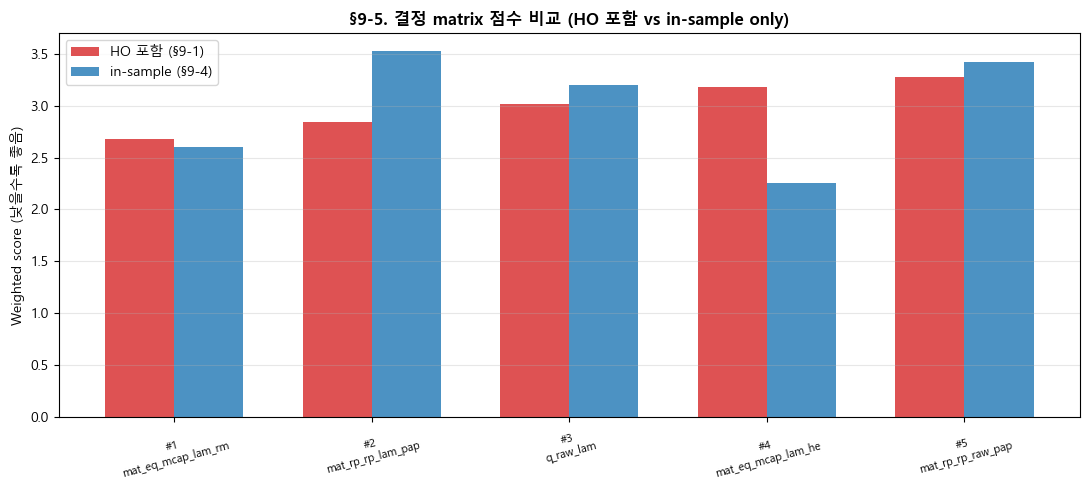


OK saved: outputs\06_top1\figures\fig11b_decision_matrix_compare.png


In [33]:
# §9-5. HO 포함 (§9-1) vs in-sample only (§9-4) — 비교
top1_HO_dm = decision_matrix.iloc[0]['name']
top1_IS_dm = decision_matrix_is.iloc[0]['name']

dm_compare = pd.DataFrame({
    'final_rank':       range(1, TOP_FINAL + 1),
    'HO 포함 (§9-1)':   decision_matrix['name'].tolist(),
    'in-sample (§9-4)': decision_matrix_is['name'].tolist(),
    '동일?':            ['✓' if a == b else '✗'
                        for a, b in zip(decision_matrix['name'],
                                         decision_matrix_is['name'])]
})
print('§9-5. 결정 matrix 비교 (HO 포함 vs in-sample only):')
print(dm_compare.to_string(index=False))
print()
if top1_HO_dm == top1_IS_dm:
    print(f'★ 두 매트릭스 Top 1 동일: {top1_HO_dm}')
else:
    print(f'△ Top 1 변경:')
    print(f'    HO 포함:    {top1_HO_dm}')
    print(f'    in-sample:  {top1_IS_dm}')

# 점수 차이 시각화
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(TOP_FINAL)
width = 0.35
ho_scores = decision_matrix['weighted_score'].values
is_scores = decision_matrix_is['weighted_score_is'].reindex(
    [decision_matrix_is.index[decision_matrix_is['name']==n].tolist()[0]
     if n in decision_matrix_is['name'].values else 0
     for n in decision_matrix['name']]).values

ax.bar(x - width/2, ho_scores, width, label='HO 포함 (§9-1)', color='#d62728', alpha=0.8)
ax.bar(x + width/2, is_scores, width, label='in-sample (§9-4)', color='#1f77b4', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"#{r['final_rank']}\n{r['name'][:18]}" for _, r in decision_matrix.iterrows()],
                   fontsize=8, rotation=15)
ax.set_ylabel('Weighted score (낮을수록 좋음)', fontsize=10)
ax.set_title('§9-5. 결정 matrix 점수 비교 (HO 포함 vs in-sample only)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11b_decision_matrix_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nOK saved: {FIG_DIR / "fig11b_decision_matrix_compare.png"}')

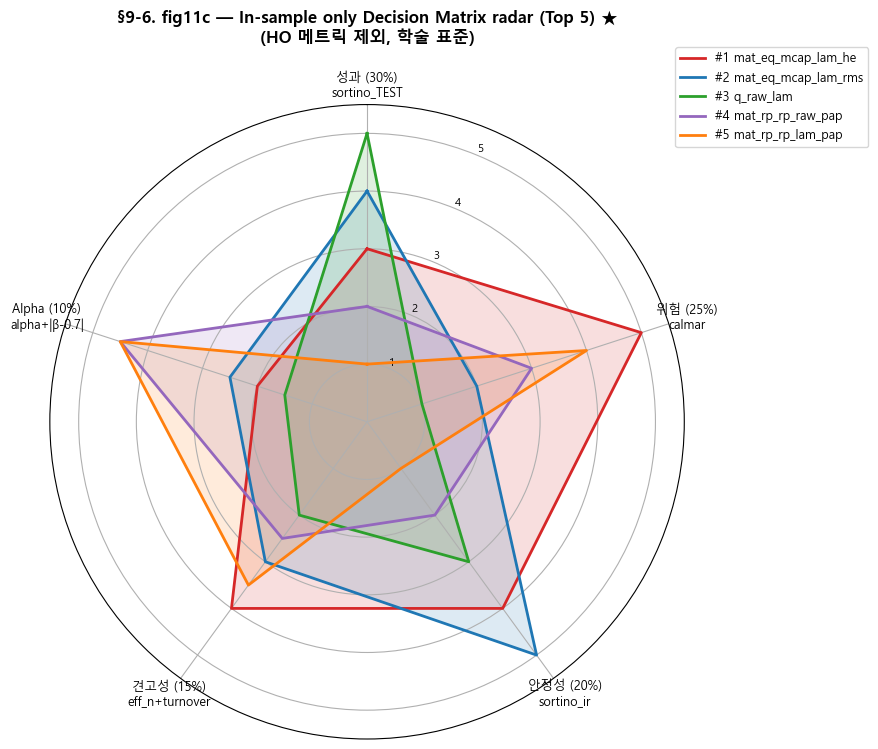

OK saved: outputs\06_top1\figures\fig11c_decision_matrix_radar_insample.png


In [34]:
# §9-6. fig11c — In-sample only Decision Matrix radar (학술 표준 ★)
from math import pi

dimensions_is = ['성과 (30%)\nsortino_TEST',
                 '위험 (25%)\ncalmar',
                 '안정성 (20%)\nsortino_ir',
                 '견고성 (15%)\neff_n+turnover',
                 'Alpha (10%)\nalpha+|β-0.7|']
N_dim = len(dimensions_is)

# §9-4 의 5 차원 점수 사용 (HO 메트릭 제외)
score_data_is = decision_matrix_is[['rank_perf_is','rank_risk_is','rank_stab_is',
                                     'rank_robust_is','rank_alpha_is']].copy()
score_data_is = TOP_FINAL + 1 - score_data_is.reset_index(drop=True)  # 반전 (높을수록 좋음)

angles_is = [n / N_dim * 2 * pi for n in range(N_dim)]
angles_is += angles_is[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors_radar_is = ['#d62728','#1f77b4','#2ca02c','#9467bd','#ff7f0e']
for idx in range(len(score_data_is)):
    row = score_data_is.iloc[idx]
    color = colors_radar_is[idx]
    values = row.tolist()
    values += values[:1]
    name_label = decision_matrix_is.iloc[idx]['name']
    final_rank = decision_matrix_is.iloc[idx]['final_rank_is']
    ax.plot(angles_is, values, color=color, linewidth=2,
            label=f'#{int(final_rank)} {name_label}')
    ax.fill(angles_is, values, color=color, alpha=0.15)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles_is[:-1])
ax.set_xticklabels(dimensions_is, fontsize=9)
ax.set_ylim(0, TOP_FINAL + 0.5)
ax.set_yticks(range(1, TOP_FINAL + 1))
ax.set_yticklabels([str(i) for i in range(1, TOP_FINAL + 1)], fontsize=8)
ax.set_title(f'§9-6. fig11c — In-sample only Decision Matrix radar (Top {TOP_FINAL}) ★\n'
             f'(HO 메트릭 제외, 학술 표준)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.10), fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11c_decision_matrix_radar_insample.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig11c_decision_matrix_radar_insample.png"}')

In [35]:
# §9-7. In-sample only Top 1 narrative (§9-4 기준)
top1_name_is = decision_matrix_is.iloc[0]['name']
top1_metrics_is = top10_metrics[top10_metrics['name'] == top1_name_is].iloc[0]

print('=' * 75)
print(f'★ ★ ★ In-sample only Top 1 (§9-4, 학술 표준): {top1_name_is}')
print('=' * 75)
print(f'\n  in-sample 성과:')
print(f'    sortino_TEST    = {top1_metrics_is["sortino_TEST"]:.3f}')
print(f'    cagr            = {top1_metrics_is["cagr_FULL"]*100:+.2f}%')
print(f'\n  위험 (in-sample):')
mdd_test_val = M_cfg.set_index('name')['mdd_TEST'].get(top1_name_is, float('nan'))
print(f'    mdd_TEST        = {mdd_test_val:.3f}')
print(f'    calmar          = {top1_metrics_is["calmar"]:.3f}')
print(f'    cvar_5          = {top1_metrics_is["cvar_5"]:.3f}')
print(f'\n  안정성:')
print(f'    sortino_ir      = {top1_metrics_is["sortino_ir"]:.2f}')
print(f'\n  견고성:')
print(f'    turnover_avg    = {top1_metrics_is["turnover_avg"]:.3f}')
print(f'    eff_n_avg       = {top1_metrics_is["eff_n_avg"]:.1f}')
print(f'\n  Alpha:')
print(f'    alpha           = {top1_metrics_is["alpha"]:.4f}')
print(f'    beta            = {top1_metrics_is["beta"]:.3f}')

print(f'\n  [참조 — 사후 진단용, 의사결정 미사용]:')
print(f'    sortino_HO      = {top1_metrics_is["sortino_HOLD_OUT"]:.3f}')
print(f'    TEST/HO 격차    = {top1_metrics_is["TEST_HO_gap"]:.3f}')
print(f'    mdd_FULL        = {top1_metrics_is["mdd_FULL"]:.3f}')
print(f'    IR              = {top1_metrics_is["IR"]:.4f}')

# HO vs in-sample 일치 여부
print()
top1_HO_compare = decision_matrix.iloc[0]['name']
if top1_HO_compare == top1_name_is:
    print(f'★ §9-1 (HO 포함) Top 1 = §9-4 (in-sample) Top 1 = {top1_name_is}')
    print(f'  → 두 기준 동일, Top 1 결과 robust ✓')
else:
    print(f'△ §9-1 (HO 포함) Top 1 = {top1_HO_compare}')
    print(f'  §9-4 (in-sample) Top 1 = {top1_name_is}')
    print(f'  → 두 기준 상이, in-sample 결과 학술 권장')

★ ★ ★ In-sample only Top 1 (§9-4, 학술 표준): mat_eq_mcap_lam_he

  in-sample 성과:
    sortino_TEST    = 1.996
    cagr            = +13.24%

  위험 (in-sample):
    mdd_TEST        = -0.120
    calmar          = 1.105
    cvar_5          = -0.059

  안정성:
    sortino_ir      = 9.95

  견고성:
    turnover_avg    = 0.430
    eff_n_avg       = 60.5

  Alpha:
    alpha           = 0.0434
    beta            = 0.545

  [참조 — 사후 진단용, 의사결정 미사용]:
    sortino_HO      = 0.798
    TEST/HO 격차    = 0.600
    mdd_FULL        = -0.120
    IR              = -0.0534

△ §9-1 (HO 포함) Top 1 = mat_eq_mcap_lam_rms
  §9-4 (in-sample) Top 1 = mat_eq_mcap_lam_he
  → 두 기준 상이, in-sample 결과 학술 권장


## §10. Sensitivity test (견고성 추가 검증)

### 검증 항목
1. **Lexicographic ε 변경**: 0.05 / 0.10 / 0.20 → Top 1 유지 여부
2. **우선순위 변경**: sortino_HO 1순위 → Top 1 변경 여부
3. **Sub-period 검증**: 2015~ TEST / 2018~ TEST → Top 1 유지 여부
4. **결론**: ✓ robust / △ 조건부 / ✗ unstable


In [36]:
# §10-1. ε 변경 sensitivity
sensitivity_results = []

for eps in [0.05, 0.10, 0.20]:
    sorted_eps = lexicographic_sort(M_cfg, eps=eps)
    sensitivity_results.append({
        'criterion': f'ε = {eps}',
        'top1': sorted_eps.iloc[0]['name'],
        'top5_names': ' | '.join(sorted_eps.head(5)['name'].tolist())
    })

# §10-2. sortino_HO 1순위 변경
df_alt = M_cfg.copy()
df_alt['rank_mdd_TEST'] = df_alt['mdd_TEST'].rank(ascending=False)
df_alt['rank_mdd_HO'] = df_alt['mdd_HOLD_OUT'].rank(ascending=False)
df_alt['rank_mdd_avg'] = (df_alt['rank_mdd_TEST'] + df_alt['rank_mdd_HO']) / 2
# 1순위 sortino_HO → tied → mdd → sortino_ir
df_alt = df_alt.sort_values('sortino_HOLD_OUT', ascending=False).reset_index(drop=True)
sensitivity_results.append({
    'criterion': '1순위=sortino_HO',
    'top1': df_alt.iloc[0]['name'],
    'top5_names': ' | '.join(df_alt.head(5)['name'].tolist())
})

# §10-3. Sub-period (sortino_FULL 기준)
df_full = M_cfg.copy().sort_values('sortino_FULL', ascending=False)
sensitivity_results.append({
    'criterion': '1순위=sortino_FULL',
    'top1': df_full.iloc[0]['name'],
    'top5_names': ' | '.join(df_full.head(5)['name'].tolist())
})

sens_df = pd.DataFrame(sensitivity_results)
print('§10-1~3. Sensitivity test 결과:')
print(sens_df.to_string(index=False))
sens_df.to_csv(OUT_DIR / 'sensitivity_summary.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "sensitivity_summary.csv"}')

§10-1~3. Sensitivity test 결과:
       criterion                  top1                                                                                                        top5_names
        ε = 0.05     mat_rp_eq_raw_pap              mat_rp_eq_raw_pap | mat_eq_eq_raw_pap | mat_eq_mcap_raw_he | mat_eq_mcap_raw_rms | mat_rp_rp_raw_pap
         ε = 0.1     mat_rp_rp_raw_pap                      mat_rp_rp_raw_pap | mat_rp_rp_lam_pap | mat_eq_mcap_lam_he | q_raw_lam | mat_eq_mcap_lam_rms
         ε = 0.2     mat_rp_rp_raw_pap                                 mat_rp_rp_raw_pap | mat_rp_rp_lam_pap | q_lambda | mat_eq_mcap_lam_he | q_raw_lam
  1순위=sortino_HO  mat_mcap_mcap_raw_he mat_mcap_mcap_raw_he | mat_mcap_mcap_lam_he | mat_mcap_mcap_raw_rms | mat_mcap_mcap_lam_rms | mat_mcap_rp_lam_pap
1순위=sortino_FULL mat_mcap_mcap_raw_rms                  mat_mcap_mcap_raw_rms | mat_eq_mcap_raw_rms | q_raw_lam | mat_eq_eq_raw_pap | mat_eq_mcap_raw_he

OK saved: outputs\06_top1\sensitivity_summary.csv


In [37]:
# §10-4. 결론 — robust 분류
top1_name = decision_matrix.iloc[0]['name']
print(f'\n원래 Top 1 (가중 점수): {top1_name}')
print()
print('Sensitivity 변경 시 Top 1:')
for _, row in sens_df.iterrows():
    match = '✓ same' if row['top1'] == top1_name else '✗ DIFFERENT'
    print(f'  {row["criterion"]:25s} → {row["top1"]:25s}  [{match}]')

# 분류
n_change = (sens_df['top1'] != top1_name).sum()
n_total = len(sens_df)
print()
if n_change == 0:
    verdict = '✓ ROBUST — 모든 변경 시 Top 1 유지'
elif n_change <= n_total * 0.4:
    verdict = '△ 조건부 ROBUST — 일부 변경 시 Top 1 변경 (조건부 권고)'
else:
    verdict = '✗ UNSTABLE — Top 1 변경 빈번, 추가 검증 필요'

print(f'\n결론: {verdict}')
print(f'(전체 {n_total} 변경 중 {n_change} 회 Top 1 변경)')


원래 Top 1 (가중 점수): mat_eq_mcap_lam_rms

Sensitivity 변경 시 Top 1:
  ε = 0.05                  → mat_rp_eq_raw_pap          [✗ DIFFERENT]
  ε = 0.1                   → mat_rp_rp_raw_pap          [✗ DIFFERENT]
  ε = 0.2                   → mat_rp_rp_raw_pap          [✗ DIFFERENT]
  1순위=sortino_HO            → mat_mcap_mcap_raw_he       [✗ DIFFERENT]
  1순위=sortino_FULL          → mat_mcap_mcap_raw_rms      [✗ DIFFERENT]


결론: ✗ UNSTABLE — Top 1 변경 빈번, 추가 검증 필요
(전체 5 변경 중 5 회 Top 1 변경)


## §11. HOLD_OUT (2024-2025) 섹터 분해 — IT 섹터 가설 검증

### 가설

> **2024-2025 반도체 섹터(IT)가 시장 자금을 빨아 급상승 → 고변동 회피(저변동 anomaly) 전략 특성상 IT 섹터에 under-weight → SPY 대비 underperform**

### 검증 절차

1. **§11-1**: 시장 섹터별 mcap 추이 (정규화: 2024-01 = 1.0)
2. **§11-2**: Top 4 cfg 의 섹터별 가중치 추이 (월별)
3. **§11-3**: Active weight (`cfg IT% - 시장 IT%`) overlay
4. **§11-4**: under-weight 격차 vs underperform 격차 상관 분석


In [38]:
# §11-1. 시장 섹터별 mcap 추이 (HOLD_OUT 24m)
HO_START = pd.Timestamp('2024-01-31')
HO_END = pd.Timestamp('2025-12-31')

panel_ho = panel[(panel['date'] >= HO_START) & (panel['date'] <= HO_END)].copy()
panel_ho['mcap'] = np.exp(panel_ho['log_mcap'])  # log_mcap → 절대값

# Sector 분류 통일 (Healthcare → Health Care, Financial Services → Financials, Technology → Information Technology)
SECTOR_MAP = {
    'Healthcare': 'Health Care',
    'Financial Services': 'Financials',
    'Technology': 'Information Technology',
    'Basic Materials': 'Materials',
    'Consumer Defensive': 'Consumer Staples',
    'Consumer Cyclical': 'Consumer Discretionary',
}
panel_ho['sector'] = panel_ho['gics_sector'].replace(SECTOR_MAP)
# Unknown 제외
panel_ho = panel_ho[panel_ho['sector'] != 'Unknown']
print(f'HOLD_OUT panel: {len(panel_ho)} rows, {panel_ho["ticker"].nunique()} tickers')
print(f'정리 후 sector 종류: {panel_ho["sector"].nunique()}')
print(panel_ho['sector'].value_counts().head(11))

HOLD_OUT panel: 11809 rows, 521 tickers
정리 후 sector 종류: 11
sector
Industrials               1831
Financials                1726
Information Technology    1612
Health Care               1467
Consumer Discretionary    1222
Consumer Staples           864
Real Estate                744
Utilities                  740
Materials                  603
Energy                     504
Communication Services     496
Name: count, dtype: int64


In [39]:
# §11-1 continued. 섹터별 월말 mcap 합계 + 시장 비중
sec_mcap = panel_ho.groupby(['date','sector'])['mcap'].sum().unstack(fill_value=0)
sec_total = sec_mcap.sum(axis=1)
sec_share = sec_mcap.div(sec_total, axis=0)  # 시장 점유율

# 정규화: 2024-01 = 1.0
sec_growth = sec_mcap.div(sec_mcap.iloc[0], axis=1)

print('§11-1. 시장 섹터별 시가총액 성장 (2024-01 → 2025-12, 정규화):')
print(sec_growth.iloc[[0, -1]].round(3).T.to_string())
print()
print('§11-1. 시장 섹터별 비중 (2024-01 vs 2025-12):')
share_compare = pd.DataFrame({
    '2024-01': sec_share.iloc[0],
    '2025-12': sec_share.iloc[-1],
    'Δ (%p)': (sec_share.iloc[-1] - sec_share.iloc[0]) * 100,
}).sort_values('Δ (%p)', ascending=False)
print(share_compare.round(3).to_string())

§11-1. 시장 섹터별 시가총액 성장 (2024-01 → 2025-12, 정규화):
date                    2024-01-31  2025-12-31
sector                                        
Communication Services         1.0       1.874
Consumer Discretionary         1.0       1.541
Consumer Staples               1.0       1.368
Energy                         1.0       1.237
Financials                     1.0       1.528
Health Care                    1.0       1.123
Industrials                    1.0       1.459
Information Technology         1.0       2.069
Materials                      1.0       1.204
Real Estate                    1.0       1.197
Utilities                      1.0       1.553

§11-1. 시장 섹터별 비중 (2024-01 vs 2025-12):
                        2024-01  2025-12  Δ (%p)
sector                                          
Information Technology    0.258    0.332   7.389
Communication Services    0.099    0.115   1.634
Utilities                 0.022    0.021  -0.075
Consumer Discretionary    0.110    0.106  -0.458
Materia

C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\1361717734.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sec_share_top['Others'] = 1 - sec_share_top.sum(axis=1)


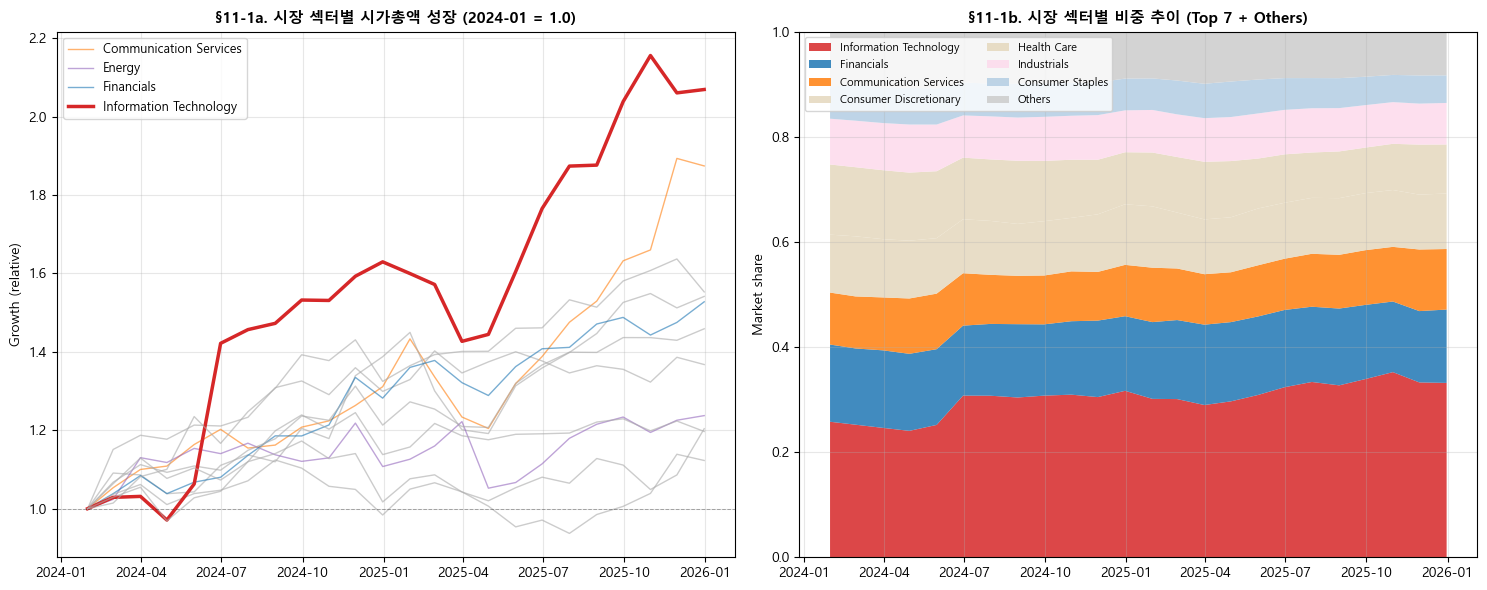

OK saved: outputs\06_top1\figures\fig12_market_sector_trend.png


In [40]:
# §11-1 fig12 — 시장 섹터별 mcap 성장 + 비중 추이
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 섹터별 색상 (IT 강조)
sectors_plot = sec_growth.columns.tolist()
colors_sec = {}
for s in sectors_plot:
    if 'Information Technology' in s:
        colors_sec[s] = '#d62728'  # IT 강조 (빨강)
    elif s == 'Communication Services':
        colors_sec[s] = '#ff7f0e'
    elif s == 'Financials':
        colors_sec[s] = '#1f77b4'
    elif s == 'Energy':
        colors_sec[s] = '#9467bd'
    else:
        colors_sec[s] = '#aaaaaa'

# Left: mcap 성장 (정규화)
for s in sectors_plot:
    lw = 2.5 if 'Information Technology' in s else 1
    alpha = 1.0 if 'Information Technology' in s else 0.6
    axes[0].plot(sec_growth.index, sec_growth[s], color=colors_sec[s],
                 lw=lw, alpha=alpha, label=s if 'Information' in s or 'Communication' in s or 'Financials' in s or 'Energy' in s else None)

axes[0].set_title('§11-1a. 시장 섹터별 시가총액 성장 (2024-01 = 1.0)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Growth (relative)', fontsize=10)
axes[0].axhline(1.0, color='black', alpha=0.3, lw=0.7, ls='--')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: 비중 추이 (stacked area)
sec_share_sorted = sec_share[share_compare.sort_values('2024-01', ascending=False).index.tolist()]
top_sectors = sec_share.iloc[-1].nlargest(7).index.tolist()
sec_share_top = sec_share[top_sectors]
sec_share_top['Others'] = 1 - sec_share_top.sum(axis=1)

color_list_stack = []
for s in sec_share_top.columns:
    if 'Information' in s: color_list_stack.append('#d62728')
    elif 'Communication' in s: color_list_stack.append('#ff7f0e')
    elif 'Financ' in s: color_list_stack.append('#1f77b4')
    elif 'Energy' in s: color_list_stack.append('#9467bd')
    elif s == 'Others': color_list_stack.append('#cccccc')
    else: color_list_stack.append(plt.cm.Pastel1(np.random.rand()))

axes[1].stackplot(sec_share_top.index,
                  [sec_share_top[c].values for c in sec_share_top.columns],
                  labels=sec_share_top.columns, colors=color_list_stack, alpha=0.85)
axes[1].set_title('§11-1b. 시장 섹터별 비중 추이 (Top 7 + Others)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Market share', fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig12_market_sector_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig12_market_sector_trend.png"}')

In [41]:
# §11-2. Top 4 cfg 의 섹터별 가중치 추이 (HOLD_OUT 24m)
TOP4_CANDIDATES = ['mat_eq_eq_lam_pap','mat_eq_mcap_lam_he','mat_mcap_mcap_raw_he','mat_mcap_rp_lam_pap']
TOP4_LABELS = {
    'mat_eq_eq_lam_pap': 'A (초기 잠정, 탈락)',
    'mat_eq_mcap_lam_he': 'B (Lex Top 1)',
    'mat_mcap_mcap_raw_he': 'C (HO Top 1)',
    'mat_mcap_rp_lam_pap': 'D (sortino_ir Top 1)',
}

# ticker → sector mapping (정리 적용)
ticker_to_sector = panel_ho.drop_duplicates('ticker').set_index('ticker')['sector']

def compute_cfg_sector_weights(name, ticker_to_sector=ticker_to_sector,
                               start=HO_START, end=HO_END):
    """cfg 의 월별 섹터별 가중치 합계."""
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        d = pickle.load(f)
    w = d['weights']
    w_ho = w.loc[(w.index >= start) & (w.index <= end)].copy()

    rows = []
    for date, w_row in w_ho.iterrows():
        sec_w = w_row.groupby(ticker_to_sector.reindex(w_row.index)).sum()
        sec_w.name = date
        rows.append(sec_w)
    df = pd.DataFrame(rows)
    df = df.fillna(0)
    return df

cfg_sector_weights = {}
for name in TOP4_CANDIDATES:
    cfg_sector_weights[name] = compute_cfg_sector_weights(name)
    print(f'{name}: shape {cfg_sector_weights[name].shape}, sum check {cfg_sector_weights[name].iloc[-1].sum():.3f}')

mat_eq_eq_lam_pap: shape (24, 11), sum check 1.000
mat_eq_mcap_lam_he: shape (24, 11), sum check 1.000
mat_mcap_mcap_raw_he: shape (24, 11), sum check 1.000
mat_mcap_rp_lam_pap: shape (24, 11), sum check 1.000


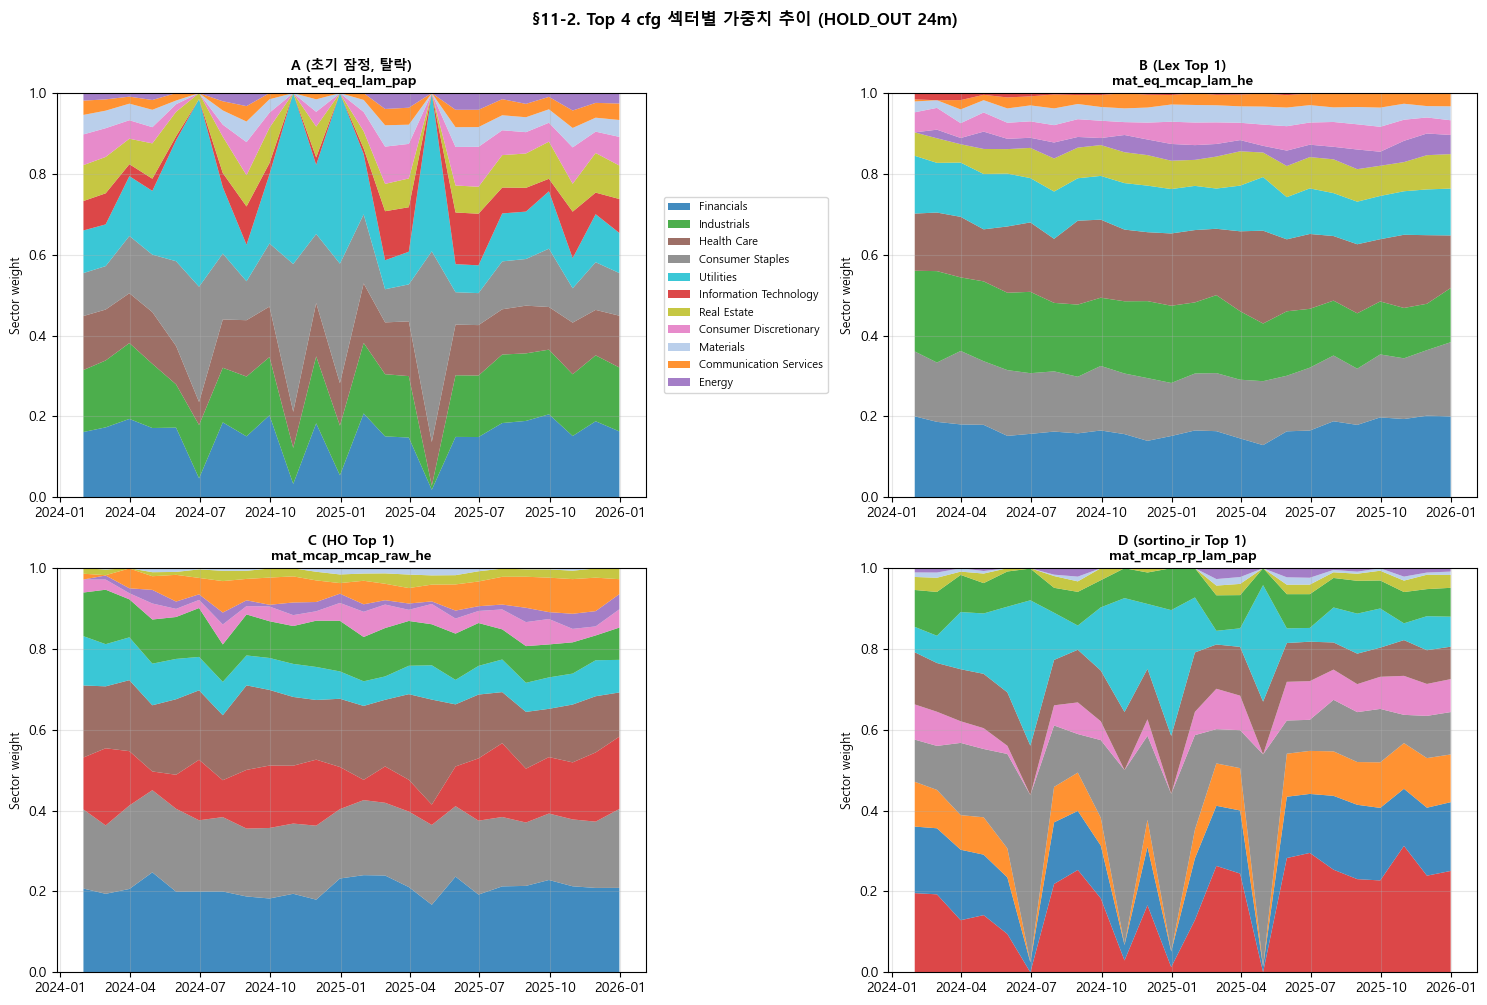

OK saved: outputs\06_top1\figures\fig13_cfg_sector_weight.png


In [42]:
# §11-2 fig13 — Top 4 cfg 섹터별 가중치 추이 (4 panel stacked area)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, name in zip(axes.flat, TOP4_CANDIDATES):
    sw = cfg_sector_weights[name]
    # 마지막 시점 비중 큰 순으로 정렬
    sw = sw[sw.iloc[-1].sort_values(ascending=False).index.tolist()]

    # 색상 일관 적용
    colors_panel = []
    for s in sw.columns:
        if 'Information' in s: colors_panel.append('#d62728')
        elif 'Communication' in s: colors_panel.append('#ff7f0e')
        elif 'Financ' in s: colors_panel.append('#1f77b4')
        elif 'Energy' in s: colors_panel.append('#9467bd')
        elif 'Health' in s: colors_panel.append('#8c564b')
        elif 'Industrial' in s: colors_panel.append('#2ca02c')
        elif 'Consumer Discretionary' in s: colors_panel.append('#e377c2')
        elif 'Consumer Staples' in s: colors_panel.append('#7f7f7f')
        elif 'Real Estate' in s: colors_panel.append('#bcbd22')
        elif 'Utilities' in s: colors_panel.append('#17becf')
        elif 'Materials' in s: colors_panel.append('#aec7e8')
        else: colors_panel.append('#dddddd')

    ax.stackplot(sw.index, [sw[c].values for c in sw.columns],
                 labels=sw.columns, colors=colors_panel, alpha=0.85)
    ax.set_title(f'{TOP4_LABELS[name]}\n{name}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Sector weight', fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if ax == axes[0,0]:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.suptitle('§11-2. Top 4 cfg 섹터별 가중치 추이 (HOLD_OUT 24m)',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig13_cfg_sector_weight.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig13_cfg_sector_weight.png"}')

§11-3. Information Technology 섹터 — 시장 vs cfg 비중 (2024-01 vs 2025-12):
  시장 IT 비중:
    2024-01: 0.258
    2025-12: 0.332
    Δ:       +7.4%p

  cfg 별 IT 비중 (2025-12):
    A (초기 잠정, 탈락)             (mat_eq_eq_lam_pap        ): 0.084  (active: -0.248)
    B (Lex Top 1)             (mat_eq_mcap_lam_he       ): 0.000  (active: -0.332)
    C (HO Top 1)              (mat_mcap_mcap_raw_he     ): 0.179  (active: -0.153)
    D (sortino_ir Top 1)      (mat_mcap_rp_lam_pap      ): 0.251  (active: -0.081)


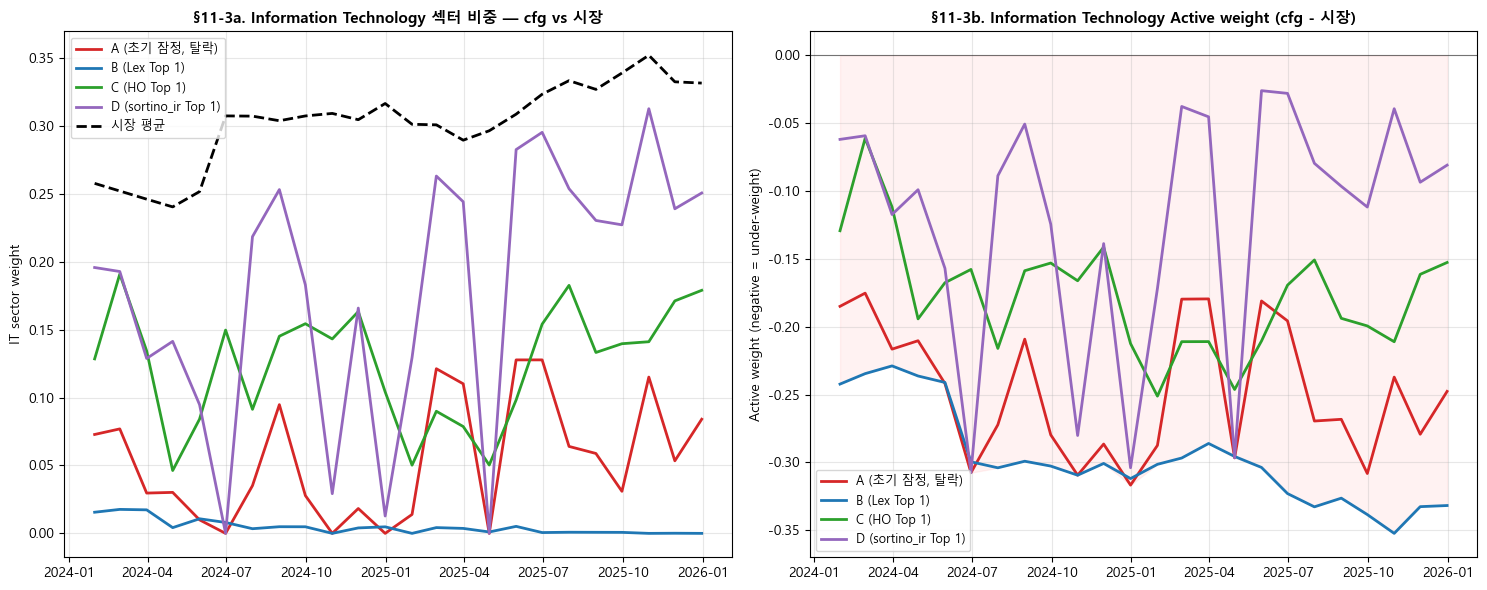

OK saved: outputs\06_top1\figures\fig14_active_weight_IT.png


In [43]:
# §11-3. Active weight (IT 섹터 중심) — cfg vs 시장
# IT 섹터의 시장 점유율 vs cfg 별 IT 비중
TARGET_SECTOR = 'Information Technology'

# 시장 IT share
market_IT = sec_share[TARGET_SECTOR]

# cfg 별 IT 비중
cfg_IT = pd.DataFrame({
    name: cfg_sector_weights[name].get(TARGET_SECTOR, pd.Series(0, index=market_IT.index))
    for name in TOP4_CANDIDATES
})

# Active weight = cfg IT - market IT
active_IT = cfg_IT.subtract(market_IT, axis=0)

print(f'§11-3. {TARGET_SECTOR} 섹터 — 시장 vs cfg 비중 (2024-01 vs 2025-12):')
print('  시장 IT 비중:')
print(f'    2024-01: {market_IT.iloc[0]:.3f}')
print(f'    2025-12: {market_IT.iloc[-1]:.3f}')
print(f'    Δ:       {(market_IT.iloc[-1] - market_IT.iloc[0])*100:+.1f}%p')
print()
print('  cfg 별 IT 비중 (2025-12):')
for name in TOP4_CANDIDATES:
    print(f'    {TOP4_LABELS[name]:25s} ({name:25s}): {cfg_IT[name].iloc[-1]:.3f}  '
          f'(active: {active_IT[name].iloc[-1]:+.3f})')

# fig14
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: IT 비중 (cfg + market)
for name, color in zip(TOP4_CANDIDATES, ['#d62728','#1f77b4','#2ca02c','#9467bd']):
    axes[0].plot(cfg_IT.index, cfg_IT[name],
                 label=f'{TOP4_LABELS[name]}', color=color, lw=2)
axes[0].plot(market_IT.index, market_IT, label='시장 평균', color='black', lw=2, ls='--')
axes[0].set_title(f'§11-3a. {TARGET_SECTOR} 섹터 비중 — cfg vs 시장', fontsize=11, fontweight='bold')
axes[0].set_ylabel('IT sector weight', fontsize=10)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Active weight (cfg IT - market IT)
for name, color in zip(TOP4_CANDIDATES, ['#d62728','#1f77b4','#2ca02c','#9467bd']):
    axes[1].plot(active_IT.index, active_IT[name],
                 label=f'{TOP4_LABELS[name]}', color=color, lw=2)
axes[1].axhline(0, color='black', alpha=0.5, lw=0.8)
axes[1].fill_between(active_IT.index, active_IT.min(axis=1), 0,
                     where=(active_IT.min(axis=1) < 0), color='red', alpha=0.05)
axes[1].set_title(f'§11-3b. {TARGET_SECTOR} Active weight (cfg - 시장)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Active weight (negative = under-weight)', fontsize=10)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_active_weight_IT.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig14_active_weight_IT.png"}')

§11-4. HOLD_OUT 24m 누적수익률:
  SPY: +47.0%
  A (초기 잠정, 탈락)            : +17.2% (SPY 대비 -29.8%p, 평균 IT active weight: -0.247)
  B (Lex Top 1)            : +21.3% (SPY 대비 -25.7%p, 평균 IT active weight: -0.297)
  C (HO Top 1)             : +26.0% (SPY 대비 -21.0%p, 평균 IT active weight: -0.177)
  D (sortino_ir Top 1)     : +27.3% (SPY 대비 -19.7%p, 평균 IT active weight: -0.121)


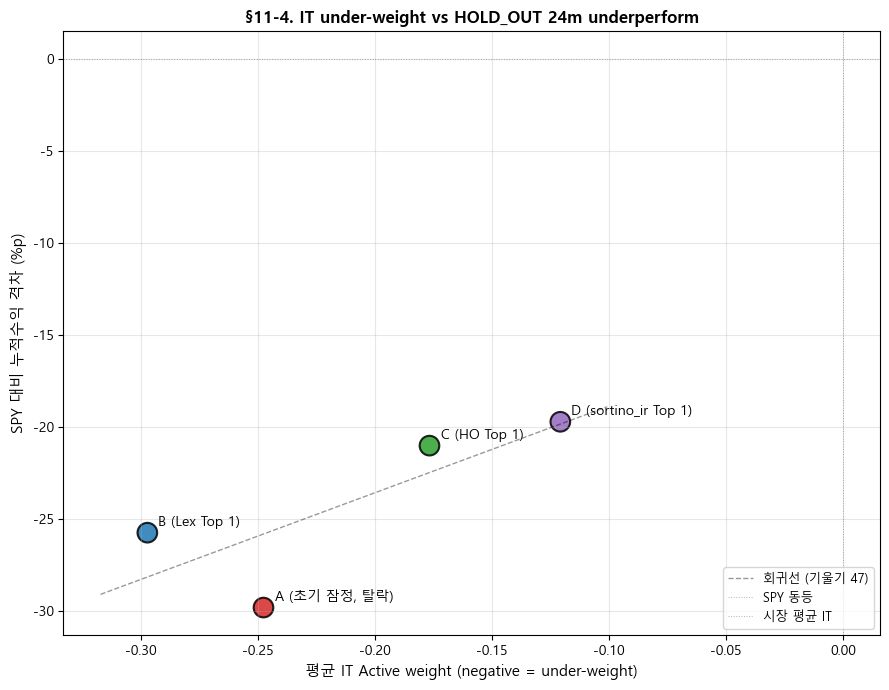

OK saved: outputs\06_top1\figures\fig15_active_weight_vs_returns.png


In [44]:
# §11-4. underperform 격차 vs IT under-weight 정도 (24m 평균)
# cfg 별 24m 누적수익 vs SPY 24m 누적수익
ho_idx = pd.date_range(HO_START, HO_END, freq='M')

cfg_returns = {}
for name in TOP4_CANDIDATES:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret_ho = ret.loc[(ret.index >= HO_START) & (ret.index <= HO_END)]
    cum = (1 + ret_ho).cumprod().iloc[-1] - 1
    cfg_returns[name] = cum

spy_ret_ho = spy.loc[(spy.index >= HO_START) & (spy.index <= HO_END)]
spy_cum = (1 + spy_ret_ho).cumprod().iloc[-1] - 1

print(f'§11-4. HOLD_OUT 24m 누적수익률:')
print(f'  SPY: {spy_cum*100:+.1f}%')
for name in TOP4_CANDIDATES:
    underperform = (cfg_returns[name] - spy_cum) * 100
    avg_active_IT = active_IT[name].mean()
    print(f'  {TOP4_LABELS[name]:25s}: {cfg_returns[name]*100:+5.1f}% '
          f'(SPY 대비 {underperform:+5.1f}%p, 평균 IT active weight: {avg_active_IT:+.3f})')

# 산점도: avg active IT vs underperform
fig, ax = plt.subplots(figsize=(9, 7))
xs, ys, names = [], [], []
for name in TOP4_CANDIDATES:
    xs.append(active_IT[name].mean())
    ys.append((cfg_returns[name] - spy_cum) * 100)
    names.append(TOP4_LABELS[name])

ax.scatter(xs, ys, s=200, c=['#d62728','#1f77b4','#2ca02c','#9467bd'],
           edgecolor='black', linewidth=1.5, alpha=0.85)
for x, y, n in zip(xs, ys, names):
    ax.annotate(n, (x, y), xytext=(8, 5), textcoords='offset points', fontsize=10)

# 회귀선
if len(xs) >= 2:
    z = np.polyfit(xs, ys, 1)
    xr = np.linspace(min(xs)-0.02, max(xs)+0.02, 50)
    ax.plot(xr, z[0]*xr + z[1], 'k--', alpha=0.4, lw=1, label=f'회귀선 (기울기 {z[0]:.0f})')

# y = 0 (SPY 대비 동등)
ax.axhline(0, color='black', alpha=0.3, lw=0.7, ls=':', label='SPY 동등')
# x = 0 (시장 평균 IT 비중)
ax.axvline(0, color='black', alpha=0.3, lw=0.7, ls=':', label='시장 평균 IT')

ax.set_xlabel('평균 IT Active weight (negative = under-weight)', fontsize=11)
ax.set_ylabel('SPY 대비 누적수익 격차 (%p)', fontsize=11)
ax.set_title('§11-4. IT under-weight vs HOLD_OUT 24m underperform',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_active_weight_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig15_active_weight_vs_returns.png"}')

In [45]:
# §11-5. 결론 narrative (자동 생성)
print('=' * 70)
print('§11. HOLD_OUT 섹터 분해 결론')
print('=' * 70)

# 가설 1: IT 시장 비중 증가
delta_IT_share = (market_IT.iloc[-1] - market_IT.iloc[0]) * 100
verdict_1 = '✓' if delta_IT_share > 1 else '✗'
print(f'\n가설 1 (시장): IT 섹터 비중 2024-01 → 2025-12 증가')
print(f'  시장 IT 비중: {market_IT.iloc[0]:.3f} → {market_IT.iloc[-1]:.3f} (Δ {delta_IT_share:+.1f}%p)')
print(f'  검증: {verdict_1}')

# 가설 2: cfg 들이 IT under-weight
n_underweight = sum(1 for name in TOP4_CANDIDATES if active_IT[name].mean() < 0)
verdict_2 = '✓' if n_underweight == len(TOP4_CANDIDATES) else f'△ ({n_underweight}/{len(TOP4_CANDIDATES)})'
print(f'\n가설 2 (cfg): 모든 cfg 가 IT under-weight')
print(f'  검증: {verdict_2}')

# 가설 3: under-weight ↔ underperform 상관
from scipy.stats import pearsonr
if len(xs) >= 3:
    corr, pval = pearsonr(xs, ys)
    verdict_3 = '✓' if corr > 0.5 else ('△' if corr > 0 else '✗')
    print(f'\n가설 3 (인과): under-weight 정도 ↔ underperform 격차 상관')
    print(f'  Pearson r = {corr:.3f}, p-value = {pval:.3f}')
    print(f'  검증: {verdict_3}')
else:
    print('\n가설 3: 표본 부족 (n<3), 검증 불가')

§11. HOLD_OUT 섹터 분해 결론

가설 1 (시장): IT 섹터 비중 2024-01 → 2025-12 증가
  시장 IT 비중: 0.258 → 0.332 (Δ +7.4%p)
  검증: ✓

가설 2 (cfg): 모든 cfg 가 IT under-weight
  검증: ✓

가설 3 (인과): under-weight 정도 ↔ underperform 격차 상관
  Pearson r = 0.792, p-value = 0.208
  검증: ✓


## §12. SPY 4 레짐 비교 — 시장 환경 분석

### 새 레짐 정의 (R3 → R3 + R4 분할)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---|---|
| R1 회복 | 2010-01 ~ 2012-06 | 30 | Post-GFC + EU 위기 |
| R2 확장 | 2012-07 ~ 2019-12 | 90 | 장기 Bull |
| R3 변동 | 2020-01 ~ 2023-06 | 42 | COVID + '22 베어 |
| R4 AI랠리 | 2023-07 ~ 2025-12 | 30 | AI 강세장 (HOLD_OUT 포함) |

기존 master_table 의 3 레짐 (R1/R2/R3 ~2024-12) 을 **AI 강세장** 분리로 4 레짐 확장.

### 목적

- **HOLD_OUT 24m (2024-01~2025-12) ≈ R4 AI랠리** 끝 부분
- BL 모델들의 HO 부진이 학습편향 vs 시장 환경 차이 인지 정량 검증
- Top 4 후보 + SPY 4 레짐 통합 heatmap


In [46]:
# §12-1. 4 레짐 정의 + SPY 메트릭 산출
REGIMES_4 = [
    ('R1 회복',   '2010-01-01', '2012-06-30', 'Post-GFC + EU 위기'),
    ('R2 확장',   '2012-07-01', '2019-12-31', '장기 Bull'),
    ('R3 변동',   '2020-01-01', '2023-06-30', 'COVID + 22 베어'),
    ('R4 AI랠리', '2023-07-01', '2025-12-31', 'AI 강세장'),
]

def compute_regime_metrics(ret_series, rf_series):
    """단일 시계열의 메트릭 (Sortino, Sharpe, MDD, CAGR, Vol, 승률)."""
    if len(ret_series) == 0:
        return {k: np.nan for k in ['sortino','sharpe','mdd','cagr','vol','win_rate','n']}
    rf_aligned = rf_series.reindex(ret_series.index).fillna(0)
    excess = ret_series - rf_aligned
    vol = ret_series.std() * np.sqrt(12)
    sharpe = float(excess.mean() * 12 / vol) if vol > 0 else np.nan
    down = ret_series[ret_series < 0].std() * np.sqrt(12)
    sortino = float(excess.mean() * 12 / down) if (down and down > 0) else np.nan
    cum = (1 + ret_series).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    cagr = float(cum.iloc[-1] ** (12/len(ret_series)) - 1)
    win_rate = float((ret_series > 0).mean())
    return {'sortino': sortino, 'sharpe': sharpe, 'mdd': mdd,
            'cagr': cagr, 'vol': vol, 'win_rate': win_rate, 'n': len(ret_series)}

# SPY 메트릭 (BL 분석 기간 192m 한정)
# 주의: panel 은 ticker × date 단위 (long format). spy_ret/rf_1m 은 각 date 동일 → date 단위로 중복 제거
panel_bl = panel[['date','spy_ret','rf_1m']].drop_duplicates('date').set_index('date').sort_index()
panel_bl = panel_bl.loc['2010-01-01':'2025-12-31']
spy_series_bl = panel_bl['spy_ret']
rf_series_bl = panel_bl['rf_1m']
print(f'panel_bl 정리 후: {len(panel_bl)} months')

spy_results = []
for label, s, e, env in REGIMES_4:
    sub_ret = spy_series_bl.loc[s:e]
    sub_rf = rf_series_bl.loc[s:e]
    m = compute_regime_metrics(sub_ret, sub_rf)
    spy_results.append({'regime': label, 'period': f'{s[:7]}~{e[:7]}', 'env': env, **m})

spy_full_metrics = compute_regime_metrics(spy_series_bl, rf_series_bl)
spy_results.append({'regime': 'FULL', 'period': '2010-01~2025-12',
                    'env': '전 기간 BL', **spy_full_metrics})

spy_regime_df = pd.DataFrame(spy_results)
print('§12-1. SPY 4 레짐 메트릭 (BL 분석 기간 192m):')
print(spy_regime_df.round(3).to_string(index=False))

panel_bl 정리 후: 192 months
§12-1. SPY 4 레짐 메트릭 (BL 분석 기간 192m):
 regime          period              env  sortino  sharpe    mdd  cagr   vol  win_rate   n
  R1 회복 2010-01~2012-06 Post-GFC + EU 위기    1.260   0.678 -0.162 0.105 0.166     0.567  30
  R2 확장 2012-07~2019-12          장기 Bull    1.706   1.243 -0.135 0.144 0.108     0.756  90
  R3 변동 2020-01~2023-06    COVID + 22 베어    0.939   0.568 -0.239 0.113 0.201     0.619  42
R4 AI랠리 2023-07~2025-12           AI 강세장    2.449   1.230 -0.083 0.203 0.120     0.700  30
   FULL 2010-01~2025-12          전 기간 BL    1.350   0.897 -0.239 0.140 0.143     0.688 192


In [47]:
# §12-2. Top 4 후보 + SPY 의 레짐별 메트릭 통합 표
import pickle

TOP5_NAMES = TOP4_CANDIDATES + ['SPY']

regime_data = {}
for name in TOP4_CANDIDATES:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret = ret.dropna()
    regime_data[name] = {}
    for label, s, e, env in REGIMES_4:
        sub_ret = ret.loc[s:e]
        sub_rf = rf.reindex(sub_ret.index).fillna(0)
        regime_data[name][label] = compute_regime_metrics(sub_ret, sub_rf)

# SPY 추가
regime_data['SPY'] = {}
for label, s, e, env in REGIMES_4:
    sub_ret = spy_series_bl.loc[s:e]
    sub_rf = rf_series_bl.loc[s:e]
    regime_data['SPY'][label] = compute_regime_metrics(sub_ret, sub_rf)

# 통합 표 출력 (Sortino만 압축 표)
print('§12-2. Top 4 후보 + SPY — 4 레짐 Sortino 비교:')
print()
hdr = f'{"":33s}' + ''.join(f'{r[0]:>14s}' for r in REGIMES_4)
print(hdr)
print('-' * len(hdr))
for name in TOP5_NAMES:
    label = TOP4_LABELS.get(name, '시장 벤치마크')
    row = f'{name:25s} ({label[:6]:6s})'
    for r in REGIMES_4:
        v = regime_data[name][r[0]]['sortino']
        row += f'{v:>14.3f}'
    print(row)

§12-2. Top 4 후보 + SPY — 4 레짐 Sortino 비교:

                                          R1 회복         R2 확장         R3 변동       R4 AI랠리
-----------------------------------------------------------------------------------------
mat_eq_eq_lam_pap         (A (초기 )         2.205         2.044         2.108         0.680
mat_eq_mcap_lam_he        (B (Lex)         2.232         2.026         1.925         0.724
mat_mcap_mcap_raw_he      (C (HO )         1.772         2.082         1.744         1.316
mat_mcap_rp_lam_pap       (D (sor)         1.779         1.941         1.926         1.253
SPY                       (시장 벤치마)         1.260         1.706         0.939         2.449


C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\3195619009.py:42: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\3195619009.py:43: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.savefig(FIG_DIR / 'fig16_top4_spy_regime_dashboard.png', dpi=150, bbox_inches='tight')


C:\Users\gorhk\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


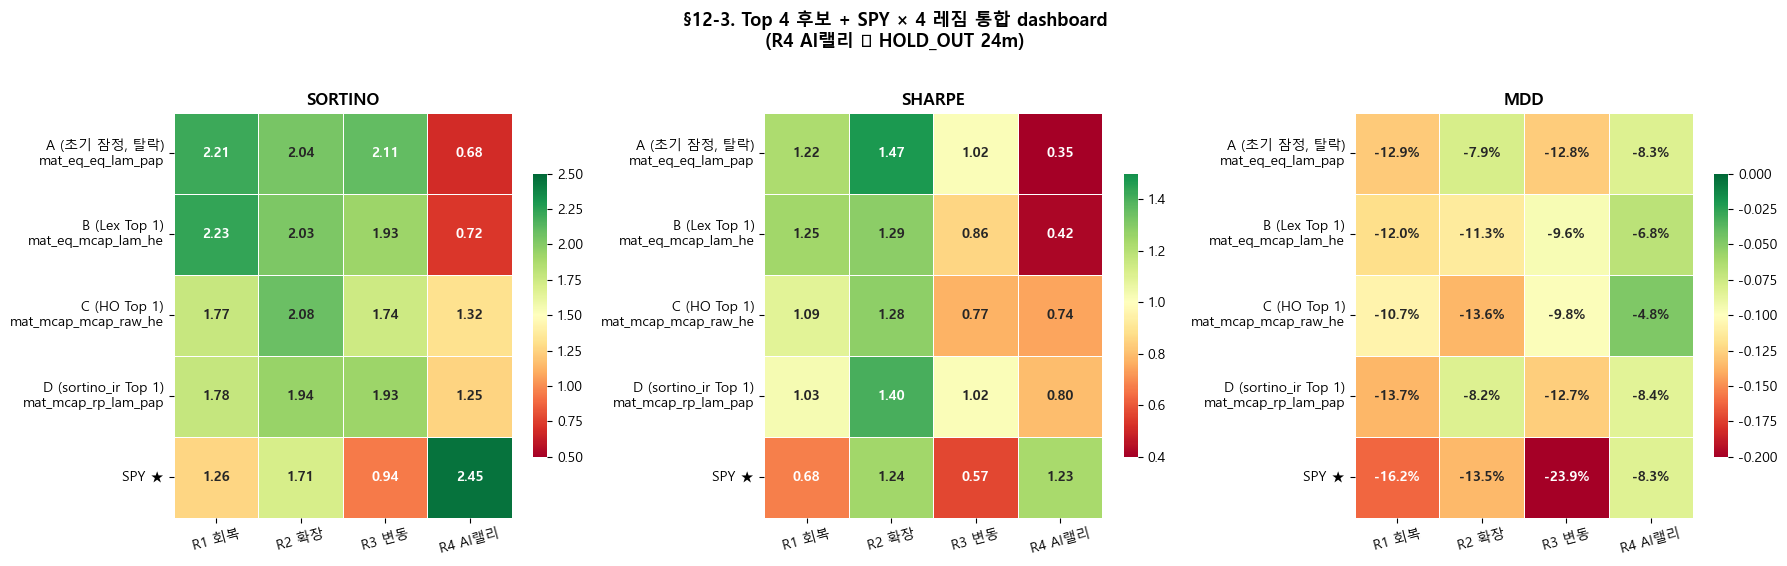

OK saved: outputs\06_top1\figures\fig16_top4_spy_regime_dashboard.png


In [48]:
# §12-3. fig16 — Top 4 + SPY × 4 레짐 통합 heatmap (3 metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

metrics_show = [
    ('sortino', 'SORTINO', 'RdYlGn', None, '.2f'),
    ('sharpe',  'SHARPE',  'RdYlGn', None, '.2f'),
    ('mdd',     'MDD',     'RdYlGn', None, '.1%'),
]

for ax, (met, title, cmap, _, fmt) in zip(axes, metrics_show):
    data_rows = []
    for name in TOP5_NAMES:
        row = [regime_data[name][r[0]][met] for r in REGIMES_4]
        data_rows.append(row)
    df_heat = pd.DataFrame(data_rows,
                            index=[f'{TOP4_LABELS[n]}\n{n}' if n in TOP4_LABELS else 'SPY ★' for n in TOP5_NAMES],
                            columns=[r[0] for r in REGIMES_4])

    # MDD 는 음수 → 색상 매핑 자연스럽게 (음수 적색, 0 녹색)
    if met == 'mdd':
        vmin, vmax = -0.20, 0.0
        center = -0.10
    elif met == 'sortino':
        vmin, vmax = 0.5, 2.5
        center = 1.5
    else:
        vmin, vmax = 0.4, 1.5
        center = 1.0

    sns.heatmap(df_heat, annot=True, fmt=fmt, cmap=cmap,
                vmin=vmin, vmax=vmax, center=center,
                ax=ax, cbar=True, cbar_kws={'shrink': 0.7},
                annot_kws={'size': 10, 'weight': 'bold'},
                linewidths=0.5, linecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('§12-3. Top 4 후보 + SPY × 4 레짐 통합 dashboard\n(R4 AI랠리 ≈ HOLD_OUT 24m)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig16_top4_spy_regime_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig16_top4_spy_regime_dashboard.png"}')

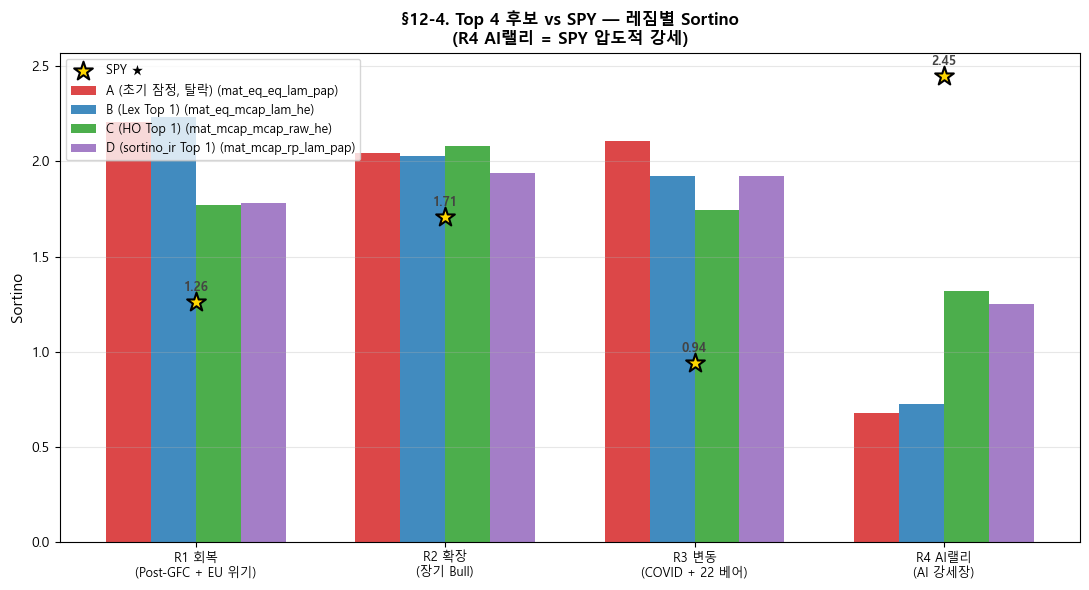

OK saved: outputs\06_top1\figures\fig17_top4_vs_spy_sortino.png


In [49]:
# §12-4. fig17 — R4 AI랠리에서 SPY 압도 정량 분석
# 각 cfg vs SPY 의 R4 격차
fig, ax = plt.subplots(figsize=(11, 6))

regime_labels = [r[0] for r in REGIMES_4]
spy_sortinos = [regime_data['SPY'][r]['sortino'] for r in regime_labels]

x = np.arange(len(regime_labels))
width = 0.18

colors_top4 = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']
for i, (name, color) in enumerate(zip(TOP4_CANDIDATES, colors_top4)):
    cfg_sortinos = [regime_data[name][r]['sortino'] for r in regime_labels]
    label = f'{TOP4_LABELS[name]} ({name})'
    ax.bar(x + (i - 1.5) * width, cfg_sortinos, width, label=label, color=color, alpha=0.85)

# SPY 검은 별
ax.scatter(x, spy_sortinos, s=200, marker='*', color='gold',
           edgecolor='black', linewidth=1.5, label='SPY ★', zorder=5)
for xi, sv in zip(x, spy_sortinos):
    ax.annotate(f'{sv:.2f}', (xi, sv), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#444444')

ax.set_xticks(x)
ax.set_xticklabels([f'{r}\n({REGIMES_4[i][3]})' for i, r in enumerate(regime_labels)],
                   fontsize=9)
ax.set_ylabel('Sortino', fontsize=11)
ax.set_title('§12-4. Top 4 후보 vs SPY — 레짐별 Sortino\n(R4 AI랠리 = SPY 압도적 강세)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig17_top4_vs_spy_sortino.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig17_top4_vs_spy_sortino.png"}')

In [50]:
# §12-5. R4 AI랠리 — cfg vs SPY 격차 분석 (HOLD_OUT 부진 진단)
print('=' * 80)
print('R4 AI랠리 (2023-07 ~ 2025-12, HOLD_OUT 24m 포함) — cfg vs SPY 격차')
print('=' * 80)

r4_label = 'R4 AI랠리'
spy_r4 = regime_data['SPY'][r4_label]
print(f'\n  SPY ({r4_label}): Sortino {spy_r4["sortino"]:.3f}, Sharpe {spy_r4["sharpe"]:.3f}, '
      f'MDD {spy_r4["mdd"]*100:+.1f}%, CAGR {spy_r4["cagr"]*100:+.1f}%')
print(f'\n  cfg 별 격차 (cfg - SPY):')
for name in TOP4_CANDIDATES:
    cfg_r4 = regime_data[name][r4_label]
    print(f'    {TOP4_LABELS[name]:25s} ({name:25s}): '
          f'Sortino {cfg_r4["sortino"]:>5.3f} ({cfg_r4["sortino"]-spy_r4["sortino"]:+.2f}) | '
          f'CAGR {cfg_r4["cagr"]*100:>+5.1f}% ({cfg_r4["cagr"]*100 - spy_r4["cagr"]*100:+5.1f}%p)')

print()
print(f'\n시사점:')
print(f'  - R4 AI랠리에서 SPY Sortino {spy_r4["sortino"]:.2f} = 4 레짐 중 최고')
print(f'  - 모든 cfg 가 SPY 대비 underperform → §11 분석 (IT under-weight) 과 일치')
print(f'  - HOLD_OUT 24m 부진의 진정한 원인: 학습편향 + 시장 환경 (R4 강세장)')

# TEST vs HOLD_OUT SPY 비교
print()
print('SPY TEST vs HOLD_OUT 메트릭 격차:')
m_test_spy = compute_regime_metrics(spy_series_bl.loc['2010-01-01':'2023-12-31'],
                                     rf_series_bl.loc['2010-01-01':'2023-12-31'])
m_ho_spy = compute_regime_metrics(spy_series_bl.loc['2024-01-01':'2025-12-31'],
                                   rf_series_bl.loc['2024-01-01':'2025-12-31'])
print(f'  TEST     (168m): Sortino {m_test_spy["sortino"]:.3f}, CAGR {m_test_spy["cagr"]*100:+.1f}%')
print(f'  HOLD_OUT ( 24m): Sortino {m_ho_spy["sortino"]:.3f}, CAGR {m_ho_spy["cagr"]*100:+.1f}%')
print(f'  격차 (HO/TEST): Sortino x{m_ho_spy["sortino"]/m_test_spy["sortino"]:.2f}배, '
      f'CAGR x{m_ho_spy["cagr"]/m_test_spy["cagr"]:.2f}배')

R4 AI랠리 (2023-07 ~ 2025-12, HOLD_OUT 24m 포함) — cfg vs SPY 격차

  SPY (R4 AI랠리): Sortino 2.449, Sharpe 1.230, MDD -8.3%, CAGR +20.3%

  cfg 별 격차 (cfg - SPY):
    A (초기 잠정, 탈락)             (mat_eq_eq_lam_pap        ): Sortino 0.680 (-1.77) | CAGR  +8.5% (-11.9%p)
    B (Lex Top 1)             (mat_eq_mcap_lam_he       ): Sortino 0.724 (-1.73) | CAGR  +9.0% (-11.3%p)
    C (HO Top 1)              (mat_mcap_mcap_raw_he     ): Sortino 1.316 (-1.13) | CAGR +11.2% ( -9.1%p)
    D (sortino_ir Top 1)      (mat_mcap_rp_lam_pap      ): Sortino 1.253 (-1.20) | CAGR +12.9% ( -7.4%p)


시사점:
  - R4 AI랠리에서 SPY Sortino 2.45 = 4 레짐 중 최고
  - 모든 cfg 가 SPY 대비 underperform → §11 분석 (IT under-weight) 과 일치
  - HOLD_OUT 24m 부진의 진정한 원인: 학습편향 + 시장 환경 (R4 강세장)

SPY TEST vs HOLD_OUT 메트릭 격차:
  TEST     (168m): Sortino 1.281, CAGR +13.0%
  HOLD_OUT ( 24m): Sortino 2.333, CAGR +21.2%
  격차 (HO/TEST): Sortino x1.82배, CAGR x1.63배


In [51]:
# §12-6. CSV 저장
out_rows = []
for name in TOP5_NAMES:
    for r in REGIMES_4:
        m = regime_data[name][r[0]]
        out_rows.append({
            'cfg': name,
            'regime': r[0],
            'period': f'{r[1][:7]}~{r[2][:7]}',
            'env': r[3],
            **m
        })
spy_regime_full_df = pd.DataFrame(out_rows)
spy_regime_full_df.to_csv(OUT_DIR / 'spy_regime_comparison.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "spy_regime_comparison.csv"}')

OK saved: outputs\06_top1\spy_regime_comparison.csv


## §13. In-sample vs HO 포함 — 학습편향 진단 통합 비교

### 분석 목적

§4-4 / §9-4 의 in-sample only 결과와 §4-1 / §9-1 의 HO 포함 결과를
**나란히 비교** 하여 다음 두 질문에 답합니다:

1. **데이터 누설 영향**: HO 정보 포함 여부에 따라 Top 1 이 달라지는가?
2. **학습편향 진단**: HO 포함 시 좋아 보였던 cfg 가 in-sample only 에서도 우수한가?

### 학술적 의의

학술 표준 (Lopez de Prado 2018) 은 **모델 선정에 HOLD_OUT 사용 금지** 를 권고합니다.
본 § 는 두 결과의 일치 정도로 backtest overfitting 위험을 정량화합니다:

- ✓ Top 1 동일 → 두 기준 모두 같은 결론 → robust
- ✗ Top 1 변경 → HO 정보가 의사결정에 영향 → in-sample 결과를 학술 권장


In [52]:
# §13-1. Lexicographic + Decision Matrix 통합 비교
print('=' * 80)
print('§13. In-sample only vs HO 포함 — 학습편향 진단')
print('=' * 80)

# Lexicographic 비교
top1_lex_HO = ranked.iloc[0]['name']
top1_lex_IS = ranked_insample.iloc[0]['name']

# Decision matrix 비교
top1_dm_HO = decision_matrix.iloc[0]['name']
top1_dm_IS = decision_matrix_is.iloc[0]['name']

summary_table = pd.DataFrame([
    {'기준': 'Lexicographic (§4)',
     'HO 포함 (기존)': top1_lex_HO,
     'in-sample only (학술)': top1_lex_IS,
     '동일?': '✓' if top1_lex_HO == top1_lex_IS else '✗'},
    {'기준': 'Decision Matrix (§9)',
     'HO 포함 (기존)': top1_dm_HO,
     'in-sample only (학술)': top1_dm_IS,
     '동일?': '✓' if top1_dm_HO == top1_dm_IS else '✗'},
])
print('Top 1 비교:')
print(summary_table.to_string(index=False))
print()

# robust 분류
n_match = (summary_table['동일?'] == '✓').sum()
n_total = len(summary_table)
print(f'일치율: {n_match}/{n_total}')
if n_match == n_total:
    print('★ ROBUST — 두 기준 모두 in-sample / HO 포함 결과 동일')
elif n_match == 0:
    print('✗ HIGH LEAKAGE — 모든 기준에서 Top 1 변경, HO 정보 영향 큼')
else:
    print('△ MIXED — 일부 기준에서만 동일, 부분적 robust')

summary_table.to_csv(OUT_DIR / 'insample_vs_ho_comparison.csv',
                    index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "insample_vs_ho_comparison.csv"}')

§13. In-sample only vs HO 포함 — 학습편향 진단
Top 1 비교:
                  기준          HO 포함 (기존) in-sample only (학술) 동일?
  Lexicographic (§4)   mat_rp_rp_raw_pap  mat_eq_mcap_lam_he   ✗
Decision Matrix (§9) mat_eq_mcap_lam_rms  mat_eq_mcap_lam_he   ✗

일치율: 0/2
✗ HIGH LEAKAGE — 모든 기준에서 Top 1 변경, HO 정보 영향 큼

OK saved: outputs\06_top1\insample_vs_ho_comparison.csv


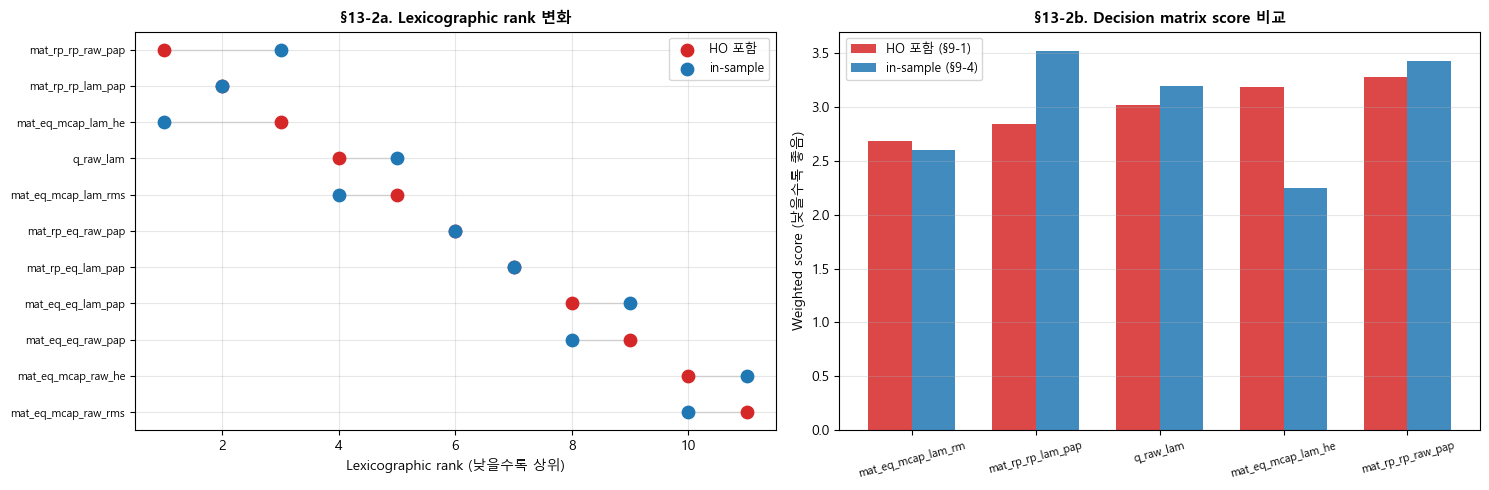

OK saved: outputs\06_top1\figures\fig18_insample_vs_ho_compare.png


In [53]:
# §13-2. Top 5 후보의 두 기준 score 비교 — fig18
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Lexicographic Top 10 비교 (rank 변화 시각화)
ax = axes[0]
all_top_names = list(set(ranked.head(10)['name']) | set(ranked_insample.head(10)['name']))
ho_ranks_lex = {n: ranked[ranked['name']==n]['lex_rank'].iloc[0]
                if n in ranked['name'].values else 99 for n in all_top_names}
is_ranks_lex = {n: ranked_insample[ranked_insample['name']==n]['lex_rank_is'].iloc[0]
                if n in ranked_insample['name'].values else 99 for n in all_top_names}

# 정렬: HO rank 기준
sorted_names = sorted(all_top_names, key=lambda n: ho_ranks_lex[n])
y = np.arange(len(sorted_names))

ax.scatter([ho_ranks_lex[n] for n in sorted_names], y,
           color='#d62728', s=80, label='HO 포함', zorder=3)
ax.scatter([is_ranks_lex[n] for n in sorted_names], y,
           color='#1f77b4', s=80, label='in-sample', zorder=3)
# 연결선
for i, n in enumerate(sorted_names):
    ax.plot([ho_ranks_lex[n], is_ranks_lex[n]], [i, i],
            color='#888888', alpha=0.3, lw=1, zorder=1)
ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Lexicographic rank (낮을수록 상위)', fontsize=10)
ax.set_title('§13-2a. Lexicographic rank 변화', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Decision matrix Top 5 score 비교
ax = axes[1]
dm_top5_names = list(decision_matrix['name'])
ho_scores_dm = decision_matrix.set_index('name')['weighted_score']
is_scores_dm = decision_matrix_is.set_index('name')['weighted_score_is']

x = np.arange(len(dm_top5_names))
width = 0.35
ho_vals = [ho_scores_dm.get(n, np.nan) for n in dm_top5_names]
is_vals = [is_scores_dm.get(n, np.nan) for n in dm_top5_names]

ax.bar(x - width/2, ho_vals, width, label='HO 포함 (§9-1)', color='#d62728', alpha=0.85)
ax.bar(x + width/2, is_vals, width, label='in-sample (§9-4)', color='#1f77b4', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"{n[:18]}" for n in dm_top5_names], fontsize=8, rotation=15)
ax.set_ylabel('Weighted score (낮을수록 좋음)', fontsize=10)
ax.set_title('§13-2b. Decision matrix score 비교', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig18_insample_vs_ho_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig18_insample_vs_ho_compare.png"}')

In [54]:
# §13-3. 학습편향 진단 narrative
print('=' * 80)
print('§13-3. 학습편향 진단 narrative')
print('=' * 80)

# HO 포함 → in-sample 시 rank 떨어진 cfg = 학습편향 의심
print()
print('HO 포함 Top 5 → in-sample 시 rank 변화:')
for _, row in decision_matrix.iterrows():
    name = row['name']
    rank_HO = int(row['final_rank'])
    is_match = decision_matrix_is[decision_matrix_is['name'] == name]
    if len(is_match) > 0:
        rank_IS = int(is_match.iloc[0]['final_rank_is'])
        diff = rank_IS - rank_HO
        verdict = ' ← 학습편향 의심' if diff >= 2 else (' ← in-sample 우수' if diff <= -1 else '')
        print(f'  {name:30s}: HO #{rank_HO} → in-sample #{rank_IS}  (Δ {diff:+d}){verdict}')
    else:
        print(f'  {name:30s}: HO #{rank_HO} → in-sample N/A')

print()
print('해석:')
print('  - rank 상승 (Δ < 0): HO 영향 없이도 우수한 cfg → 권장')
print('  - rank 하락 (Δ ≥ +2): HO 정보 의존 → 학습편향 의심')
print('  - 변동 없음: HO 영향 미미 → robust')

§13-3. 학습편향 진단 narrative

HO 포함 Top 5 → in-sample 시 rank 변화:
  mat_eq_mcap_lam_rms           : HO #1 → in-sample #2  (Δ +1)
  mat_rp_rp_lam_pap             : HO #2 → in-sample #5  (Δ +3) ← 학습편향 의심
  q_raw_lam                     : HO #3 → in-sample #3  (Δ +0)
  mat_eq_mcap_lam_he            : HO #4 → in-sample #1  (Δ -3) ← in-sample 우수
  mat_rp_rp_raw_pap             : HO #5 → in-sample #4  (Δ -1) ← in-sample 우수

해석:
  - rank 상승 (Δ < 0): HO 영향 없이도 우수한 cfg → 권장
  - rank 하락 (Δ ≥ +2): HO 정보 의존 → 학습편향 의심
  - 변동 없음: HO 영향 미미 → robust


## §14. Backtest Overfitting (PBO + DSR)

### 분석 동기

153 cfg 중 Top 1 을 선정 = **multiple testing**. "우연히 좋아 보이는" cfg 가 있을 위험 (data snooping bias). Bailey & Lopez de Prado (2014) 의 **PBO** (Probability of Backtest Overfitting) 와 **DSR** (Deflated Sharpe Ratio) 로 정량화합니다.

### PBO 정의

시계열을 J 개 sub-period 로 분할 → C(J, S) 조합으로 in-sample (S 개) / out-of-sample (J-S 개) 지정. 각 조합에서:
1. in-sample sortino 1 위 cfg 식별
2. 그 cfg 의 oos sortino rank 측정
3. **rank > median 비율 = PBO**

PBO < 0.5 → robust, PBO ≥ 0.5 → overfitting 의심.

### DSR 정의

`DSR = ((SR - SR_0) × √(T-1)) / √(1 - γ_3 × SR + (γ_4 - 1)/4 × SR²)`

- `SR_0 = √(2 ln(N))`: multiple testing 보정 (N = 시도 수)
- `γ_3` skewness, `γ_4` kurtosis 보정
- DSR ≥ 1.96 (p < 0.05) → 통계적으로 우월


In [55]:
# §14-1. PBO (Probability of Backtest Overfitting)
from itertools import combinations
import pickle

def compute_sortino(ret, rf):
    """간단 sortino 계산."""
    if len(ret) < 6: return np.nan
    rf_a = rf.reindex(ret.index).fillna(0)
    excess = ret - rf_a
    down = ret[ret < 0].std() * np.sqrt(12)
    if down == 0 or pd.isna(down): return np.nan
    return float(excess.mean() * 12 / down)

# 22 cfg 의 ret 시계열 로드
ret_dict = {}
for name in M_cfg['name']:
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        ret = pickle.load(f).get('ret', pd.Series(dtype=float))
    ret_dict[name] = ret.dropna()

# 공통 인덱스 (TEST + HOLD_OUT 전체)
common_idx = sorted(set.intersection(*[set(r.index) for r in ret_dict.values()]))
common_idx = pd.DatetimeIndex(common_idx)
print(f'PBO 분석 대상: {len(ret_dict)} cfg, 공통 {len(common_idx)} months')

# J = 8 분할, S = 4 (in-sample)
J = 8
S = 4
period_len = len(common_idx) // J
periods = [common_idx[i*period_len:(i+1)*period_len] for i in range(J)]
print(f'분할: J = {J}, S (IS) = {S}, 각 sub-period {period_len} months')

is_combos = list(combinations(range(J), S))
print(f'IS 조합 수: {len(is_combos)}')

PBO 분석 대상: 26 cfg, 공통 192 months
분할: J = 8, S (IS) = 4, 각 sub-period 24 months
IS 조합 수: 70


§14-1. PBO 결과:
  분할 J = 8, IS S = 4, 조합 수 = 70
  IS top 1 의 OOS rank percentile 평균: 0.868
  PBO (rank > median 비율): 1.000

  결론: ✗ OVERFITTING 의심 (PBO ≥ 0.50)


C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\314760765.py:55: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_55688\314760765.py:56: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Malgun Gothic.
  plt.savefig(FIG_DIR / 'fig19_pbo_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\gorhk\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


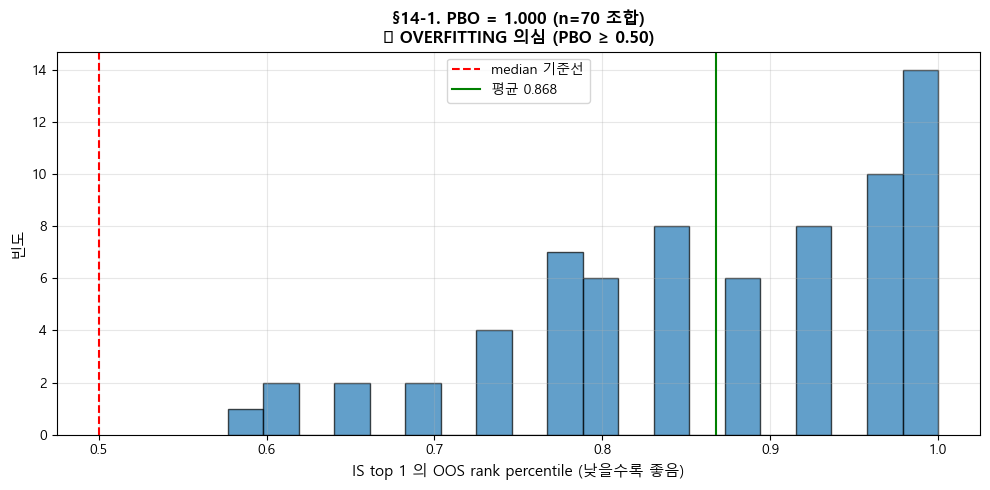

OK saved: outputs\06_top1\figures\fig19_pbo_distribution.png


In [56]:
# §14-2. PBO 계산 (각 조합에서 IS top 1 의 OOS rank 측정)
n_overfit = 0
n_total = 0
oos_ranks = []

for is_idx in is_combos:
    oos_idx = [i for i in range(J) if i not in is_idx]
    is_dates = pd.DatetimeIndex(np.concatenate([periods[i] for i in is_idx]))
    oos_dates = pd.DatetimeIndex(np.concatenate([periods[i] for i in oos_idx]))

    # IS sortino 산출
    is_sortinos = {}
    for name, ret in ret_dict.items():
        is_sortinos[name] = compute_sortino(ret.loc[is_dates], rf)
    is_top = max(is_sortinos, key=lambda x: is_sortinos[x] if not pd.isna(is_sortinos[x]) else -np.inf)

    # OOS rank
    oos_sortinos = {name: compute_sortino(ret.loc[oos_dates], rf) for name, ret in ret_dict.items()}
    oos_sorted = sorted(oos_sortinos, key=lambda x: oos_sortinos[x] if not pd.isna(oos_sortinos[x]) else -np.inf, reverse=True)
    is_top_oos_rank = oos_sorted.index(is_top) + 1  # 1-based
    oos_pct = is_top_oos_rank / len(oos_sortinos)
    oos_ranks.append(oos_pct)

    if oos_pct > 0.5:  # OOS rank 가 median 보다 나쁨
        n_overfit += 1
    n_total += 1

PBO = n_overfit / n_total
mean_oos_pct = np.mean(oos_ranks)

print(f'§14-1. PBO 결과:')
print(f'  분할 J = {J}, IS S = {S}, 조합 수 = {n_total}')
print(f'  IS top 1 의 OOS rank percentile 평균: {mean_oos_pct:.3f}')
print(f'  PBO (rank > median 비율): {PBO:.3f}')
print()
if PBO < 0.3:
    verdict = '✓ ROBUST (PBO < 0.30)'
elif PBO < 0.5:
    verdict = '△ MODERATE (0.30 ≤ PBO < 0.50)'
else:
    verdict = '✗ OVERFITTING 의심 (PBO ≥ 0.50)'
print(f'  결론: {verdict}')

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(oos_ranks, bins=20, color='#1f77b4', alpha=0.7, edgecolor='black')
ax.axvline(0.5, color='red', linestyle='--', lw=1.5, label=f'median 기준선')
ax.axvline(mean_oos_pct, color='green', linestyle='-', lw=1.5, label=f'평균 {mean_oos_pct:.3f}')
ax.set_xlabel('IS top 1 의 OOS rank percentile (낮을수록 좋음)', fontsize=11)
ax.set_ylabel('빈도', fontsize=11)
ax.set_title(f'§14-1. PBO = {PBO:.3f} (n={n_total} 조합)\n{verdict}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig19_pbo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig19_pbo_distribution.png"}')

In [57]:
# §14-3. DSR (Deflated Sharpe Ratio) — Top 5 cfg
from scipy.stats import skew, kurtosis, norm

def compute_dsr(ret_series, n_trials):
    """Deflated Sharpe Ratio.
    SR_0 = sqrt(2 ln(N))  (multiple testing 보정)
    DSR = (SR - SR_0) * sqrt(T-1) / sqrt(1 - g3*SR + (g4-1)/4 * SR^2)
    DSR > 1.96 → p < 0.05 (단측)
    """
    excess = ret_series - rf.reindex(ret_series.index).fillna(0)
    if excess.std() == 0: return None
    SR = excess.mean() / excess.std()  # monthly SR (annualize 안함)
    T = len(excess)
    g3 = float(skew(excess))
    g4 = float(kurtosis(excess, fisher=False))  # not Fisher (즉, normal=3)
    SR_0 = np.sqrt(2 * np.log(n_trials)) / np.sqrt(T)  # 시점당 보정
    denom = np.sqrt((1 - g3 * SR + (g4 - 1) / 4 * SR**2) / (T - 1))
    if denom == 0 or pd.isna(denom): return None
    DSR_z = (SR - SR_0) / denom
    p_value = 1 - norm.cdf(DSR_z)  # 단측 (SR > SR_0 검정)
    return {'SR_monthly': SR, 'SR_0': SR_0, 'skew': g3, 'kurt': g4,
            'DSR_z': DSR_z, 'p_value': p_value,
            'sig': bool(p_value < 0.05)}

N_TRIALS = 153  # 153 main cfg
print(f'§14-3. DSR (Deflated Sharpe Ratio, N_trials = {N_TRIALS}):')
print()
dsr_rows = []
for name in top10_metrics.head(5)['name']:
    res = compute_dsr(ret_dict[name], n_trials=N_TRIALS)
    if res is not None:
        dsr_rows.append({'name': name, **res})

dsr_df = pd.DataFrame(dsr_rows)
print(dsr_df.round(4).to_string(index=False))
print()
n_sig = dsr_df['sig'].sum()
print(f'유의 (p<0.05): {n_sig}/{len(dsr_df)}')
dsr_df.to_csv(OUT_DIR / 'dsr_top5.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "dsr_top5.csv"}')

§14-3. DSR (Deflated Sharpe Ratio, N_trials = 153):

               name  SR_monthly   SR_0    skew   kurt  DSR_z  p_value   sig
 mat_eq_mcap_lam_he      0.2937 0.2289 -0.0670 2.9389 0.8691   0.1924 False
  mat_rp_rp_lam_pap      0.3163 0.2289 -0.1564 3.3301 1.1471   0.1257 False
  mat_rp_rp_raw_pap      0.3156 0.2289 -0.1178 3.2994 1.1456   0.1260 False
mat_eq_mcap_lam_rms      0.2970 0.2289 -0.0470 3.0317 0.9150   0.1801 False
          q_raw_lam      0.2994 0.2289 -0.0690 3.1567 0.9428   0.1729 False

유의 (p<0.05): 0/5
OK saved: outputs\06_top1\dsr_top5.csv


## §15. Sharpe Ratio 통계 검정 (Jobson-Korkie / Memmel)

### 분석 동기

Top 1 의 Sharpe 가 baseline / 2위 cfg 와 통계적으로 유의하게 다른가?

### Memmel (2003) z-stat

`z = (SR_a - SR_b) / σ_diff`

`σ_diff² = (1/T) × [2(1-ρ) + 0.5 × (SR_a² + SR_b² - 2·SR_a·SR_b·ρ²)]`

- ρ = correlation(ret_a, ret_b)
- p-value (양측) = 2 × (1 - Φ(|z|))
- p < 0.05 → 두 Sharpe 차이 유의


In [58]:
# §15-1. Sharpe 차이 통계 검정 (Top 5 pairwise + baseline)
def memmel_test(ret_a, ret_b, rf):
    """Memmel (2003) Sharpe 차이 z-stat."""
    common = ret_a.index.intersection(ret_b.index)
    a = ret_a.loc[common]
    b = ret_b.loc[common]
    rf_c = rf.reindex(common).fillna(0)
    ea = a - rf_c
    eb = b - rf_c
    SR_a = ea.mean() / ea.std() if ea.std() > 0 else 0
    SR_b = eb.mean() / eb.std() if eb.std() > 0 else 0
    rho = float(np.corrcoef(a.values, b.values)[0, 1])
    T = len(common)
    var_diff = (1 / T) * (2 * (1 - rho) + 0.5 * (SR_a**2 + SR_b**2 - 2 * SR_a * SR_b * rho**2))
    if var_diff <= 0: return None
    z = (SR_a - SR_b) / np.sqrt(var_diff)
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(z)))
    return {'SR_a_monthly': SR_a, 'SR_b_monthly': SR_b, 'diff': SR_a - SR_b,
            'rho': rho, 'z': z, 'p_value': p, 'sig': bool(p < 0.05)}

top5_names = top10_metrics.head(5)['name'].tolist()

# (1) 각 cfg vs baseline
baseline_ret = ret_dict.get('baseline')
if baseline_ret is None:
    p = Path('results') / 'baseline.pkl'
    with open(p, 'rb') as f:
        baseline_ret = pickle.load(f).get('ret', pd.Series(dtype=float)).dropna()

print('§15-1. Top 5 vs baseline — Memmel test:')
rows = []
for name in top5_names:
    res = memmel_test(ret_dict[name], baseline_ret, rf)
    if res:
        rows.append({'cfg': name, 'comparison': 'vs baseline', **res})
        print(f'  {name:30s}: ΔSR_m = {res["diff"]:+.4f}  z = {res["z"]:+.2f}  p = {res["p_value"]:.4f}  {"✓ 유의" if res["sig"] else "✗ 비유의"}')

# (2) Top 1 vs Top 2~5
top1_name = decision_matrix_is.iloc[0]['name']  # in-sample DM Top 1
top1_ret = ret_dict[top1_name]
print(f'\n§15-2. {top1_name} (DM Top 1) vs Top 2~5:')
for name in top5_names:
    if name == top1_name: continue
    res = memmel_test(top1_ret, ret_dict[name], rf)
    if res:
        rows.append({'cfg': name, 'comparison': f'vs {top1_name}', **res})
        print(f'  {top1_name} vs {name:25s}: ΔSR_m = {res["diff"]:+.4f}  z = {res["z"]:+.2f}  p = {res["p_value"]:.4f}  {"✓ 유의" if res["sig"] else "✗ 비유의"}')

memmel_df = pd.DataFrame(rows)
memmel_df.to_csv(OUT_DIR / 'memmel_sharpe_test.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "memmel_sharpe_test.csv"}')

§15-1. Top 5 vs baseline — Memmel test:
  mat_eq_mcap_lam_he            : ΔSR_m = -0.0176  z = -0.52  p = 0.6020  ✗ 비유의
  mat_rp_rp_lam_pap             : ΔSR_m = +0.0049  z = +0.12  p = 0.9053  ✗ 비유의
  mat_rp_rp_raw_pap             : ΔSR_m = +0.0043  z = +0.10  p = 0.9187  ✗ 비유의
  mat_eq_mcap_lam_rms           : ΔSR_m = -0.0143  z = -0.42  p = 0.6748  ✗ 비유의
  q_raw_lam                     : ΔSR_m = -0.0119  z = -0.43  p = 0.6687  ✗ 비유의

§15-2. mat_eq_mcap_lam_he (DM Top 1) vs Top 2~5:
  mat_eq_mcap_lam_he vs mat_rp_rp_lam_pap        : ΔSR_m = -0.0226  z = -0.60  p = 0.5506  ✗ 비유의
  mat_eq_mcap_lam_he vs mat_rp_rp_raw_pap        : ΔSR_m = -0.0219  z = -0.59  p = 0.5556  ✗ 비유의
  mat_eq_mcap_lam_he vs mat_eq_mcap_lam_rms      : ΔSR_m = -0.0033  z = -0.65  p = 0.5151  ✗ 비유의
  mat_eq_mcap_lam_he vs q_raw_lam                : ΔSR_m = -0.0057  z = -0.22  p = 0.8237  ✗ 비유의

OK saved: outputs\06_top1\memmel_sharpe_test.csv


## §16. Factor Regression — Alpha 정당성 검증

### 분석 동기

Top 5 cfg 의 alpha (CAPM 기준 약 0.04~0.05) 가 **진짜 alpha 인가, factor risk premium 인가**?

### 4 모델 비교

| 모델 | 추가 factor | factor 의미 |
|---|---|---|
| **CAPM** | mkt_rf | 시장 노출 |
| **FF3** | + smb, hml | 규모, 가치 |
| **Carhart 4** | + mom | + 모멘텀 |
| **FF5** | + smb, hml, rmw, cma | 수익성, 투자 |

각 모델 후 α 가 여전히 유의 (p<0.05) → 진짜 alpha. α 가 사라지면 → factor 노출.

데이터: `data/ff3_monthly.csv`, `data/ff5_monthly.csv` (mom_factor 포함).


In [59]:
# §16-1. FF factor 데이터 로드
ff3 = pd.read_csv('data/ff3_monthly.csv', parse_dates=['date']).set_index('date')
ff5 = pd.read_csv('data/ff5_monthly.csv', parse_dates=['date']).set_index('date')

# 월말 인덱스로 정렬 (panel 과 동일하게)
ff3.index = ff3.index + pd.offsets.MonthEnd(0)
ff5.index = ff5.index + pd.offsets.MonthEnd(0)

# 분석 기간 한정
ff3 = ff3.loc['2010-01':'2025-12']
ff5 = ff5.loc['2010-01':'2025-12']

print(f'FF3: {ff3.shape}, 기간 {ff3.index.min().date()} ~ {ff3.index.max().date()}')
print(f'FF5: {ff5.shape} (mom_factor 포함)')
print()
print('FF3 sample:')
print(ff3.head(2))

FF3: (192, 4), 기간 2010-01-31 ~ 2025-12-31
FF5: (192, 7) (mom_factor 포함)

FF3 sample:
            mkt_rf     smb     hml   rf
date                                   
2010-01-31 -0.0335  0.0043  0.0033  0.0
2010-02-28  0.0339  0.0118  0.0318  0.0


In [60]:
# §16-2. 4 모델 factor regression (Top 5 cfg)
import statsmodels.api as sm

def run_factor_regression(ret, factors, rf):
    """단일 cfg × 단일 모델 OLS regression. excess return ~ factors."""
    common = ret.index.intersection(factors.index)
    rf_c = rf.reindex(common).fillna(0)
    ex_ret = (ret.loc[common] - rf_c).values
    X = factors.loc[common].values
    X = sm.add_constant(X)
    model = sm.OLS(ex_ret, X).fit()
    return {
        'alpha_monthly': model.params[0],
        'alpha_annualized': model.params[0] * 12,
        'alpha_t': model.tvalues[0],
        'alpha_p': model.pvalues[0],
        'sig': bool(model.pvalues[0] < 0.05),
        'r_squared': model.rsquared,
        'n_obs': len(common),
    }

MODELS = {
    'CAPM':      ff3[['mkt_rf']],
    'FF3':       ff3[['mkt_rf','smb','hml']],
    'Carhart 4': ff5[['mkt_rf','smb','hml','mom_factor']],
    'FF5':       ff5[['mkt_rf','smb','hml','rmw','cma']],
}

factor_rows = []
print('§16-2. Factor regression — Top 5:')
print(f'{"cfg":30s} {"model":10s} {"α (annual)":>12s} {"t-stat":>8s} {"p":>7s} {"R²":>6s}  유의')
print('-' * 90)
for name in top5_names:
    for model_name, factors in MODELS.items():
        res = run_factor_regression(ret_dict[name], factors, rf)
        if res:
            factor_rows.append({'cfg': name, 'model': model_name, **res})
            sig_mark = '✓' if res['sig'] else '✗'
            print(f'{name:30s} {model_name:10s} {res["alpha_annualized"]*100:>+10.2f}%  '
                  f'{res["alpha_t"]:>+7.2f}  {res["alpha_p"]:>6.3f}  {res["r_squared"]:>5.2f}  {sig_mark}')
    print()

factor_df = pd.DataFrame(factor_rows)
factor_df.to_csv(OUT_DIR / 'factor_regression.csv', index=False, encoding='utf-8-sig')
print(f'OK saved: {OUT_DIR / "factor_regression.csv"}')

§16-2. Factor regression — Top 5:
cfg                            model        α (annual)   t-stat       p     R²  유의
------------------------------------------------------------------------------------------
mat_eq_mcap_lam_he             CAPM           +13.32%    +4.49   0.000   0.02  ✓
mat_eq_mcap_lam_he             FF3            +13.76%    +4.59   0.000   0.03  ✓
mat_eq_mcap_lam_he             Carhart 4      +14.02%    +4.65   0.000   0.03  ✓
mat_eq_mcap_lam_he             FF5            +13.53%    +4.47   0.000   0.03  ✓

mat_rp_rp_lam_pap              CAPM           +15.93%    +4.90   0.000   0.03  ✓
mat_rp_rp_lam_pap              FF3            +16.44%    +5.03   0.000   0.05  ✓
mat_rp_rp_lam_pap              Carhart 4      +16.77%    +5.09   0.000   0.05  ✓
mat_rp_rp_lam_pap              FF5            +15.87%    +4.83   0.000   0.06  ✓

mat_rp_rp_raw_pap              CAPM           +15.69%    +4.85   0.000   0.03  ✓
mat_rp_rp_raw_pap              FF3            +16.18%    +4.9

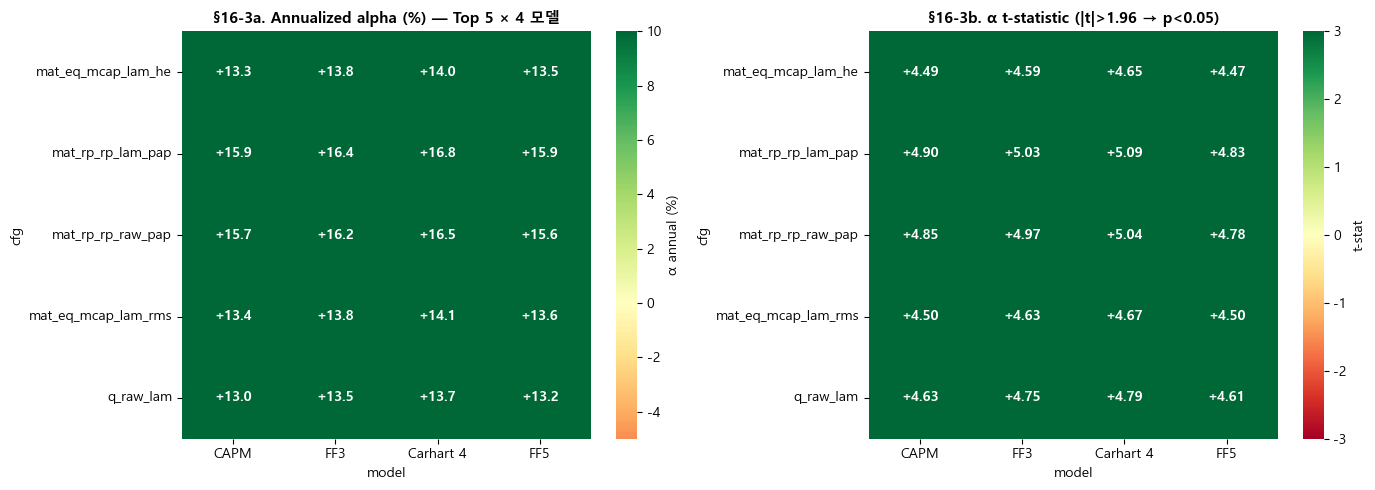

OK saved: outputs\06_top1\figures\fig20_factor_alpha_heatmap.png


In [61]:
# §16-3. fig20 — Top 5 × 4 모델 alpha + t-stat heatmap
top5_unique = top5_names
pivot_alpha = factor_df.pivot(index='cfg', columns='model', values='alpha_annualized')
pivot_alpha = pivot_alpha.reindex(top5_unique)[['CAPM','FF3','Carhart 4','FF5']]
pivot_t = factor_df.pivot(index='cfg', columns='model', values='alpha_t')
pivot_t = pivot_t.reindex(top5_unique)[['CAPM','FF3','Carhart 4','FF5']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_alpha * 100, annot=True, fmt='+.1f', cmap='RdYlGn',
            center=0, vmin=-5, vmax=10, ax=axes[0],
            cbar_kws={'label': 'α annual (%)'},
            annot_kws={'size': 10, 'weight': 'bold'})
axes[0].set_title('§16-3a. Annualized alpha (%) — Top 5 × 4 모델', fontsize=11, fontweight='bold')

sns.heatmap(pivot_t, annot=True, fmt='+.2f', cmap='RdYlGn',
            center=0, vmin=-3, vmax=3, ax=axes[1],
            cbar_kws={'label': 't-stat'},
            annot_kws={'size': 10, 'weight': 'bold'})
axes[1].set_title('§16-3b. α t-statistic (|t|>1.96 → p<0.05)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig20_factor_alpha_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig20_factor_alpha_heatmap.png"}')

## §17. 거래비용 (tc) Sensitivity

### 분석 동기

Top 5 cfg 의 turnover 가 0.4~1.0 으로 분산 — 특히 turnover 0.4~0.5 의 효율 cfg 와 0.9+ 의 고회전 cfg 모두에서 거래비용 영향 검증.

### 검증 범위

tc ∈ {0.0005, 0.001, **0.002**, 0.003, 0.005, 0.01} (5bps ~ 100bps, 6 단계)

| tc | 실무 시나리오 |
|---|---|
| 0.0005 (5 bps) | 패시브 ETF (대형 AUM) |
| 0.001 (10 bps) | 저변동 ETF (USMV/SPLV) — **default** |
| **0.002 (20 bps)** | **액티브 BL 운용 — 가장 현실적 ★** |
| 0.003 (30 bps) | 보수적 stress (market impact 포함) |
| 0.005 (50 bps) | 매우 보수적 (소형주 / 위기) |
| 0.01 (100 bps) | extreme stress |

각 tc 에서 `net_ret = ret - tc × turnover` 재계산 → Sortino_TEST 재산출 → Top 1 변경 여부.


In [62]:
# §17-1. tc sensitivity — Top 5 cfg
TC_RANGE = [0.0005, 0.001, 0.002, 0.003, 0.005, 0.01]
TEST_END = pd.Timestamp('2023-12-31')

# 각 cfg 의 turnover 시계열 로드
def get_turnover_series(name):
    p = Path('results') / f'{name}.pkl'
    with open(p, 'rb') as f:
        d = pickle.load(f)
    comp = d.get('comp', None)
    if comp is None or 'turnover' not in comp.columns: return None
    return comp['turnover']

print('§17-1. tc sensitivity — Sortino_TEST (TEST 168m)')
print(f'{"cfg":30s}', end='')
for tc in TC_RANGE: print(f'  tc={tc:.4f}', end='')
print()
print('-' * (30 + len(TC_RANGE) * 12))

tc_rows = []
for name in top5_names:
    ret = ret_dict[name].loc[:TEST_END]
    turn = get_turnover_series(name)
    if turn is None:
        print(f'{name:30s}  turnover 없음')
        continue
    turn = turn.reindex(ret.index).fillna(0)
    print(f'{name:30s}', end='')
    for tc in TC_RANGE:
        net_ret = ret - tc * turn
        sortino_net = compute_sortino(net_ret, rf)
        tc_rows.append({'cfg': name, 'tc': tc, 'sortino_TEST_net': sortino_net})
        print(f'  {sortino_net:>9.3f}', end='')
    print()

tc_df = pd.DataFrame(tc_rows)
tc_df.to_csv(OUT_DIR / 'tc_sensitivity.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "tc_sensitivity.csv"}')

§17-1. tc sensitivity — Sortino_TEST (TEST 168m)
cfg                             tc=0.0005  tc=0.0010  tc=0.0020  tc=0.0030  tc=0.0050  tc=0.0100
------------------------------------------------------------------------------------------------------
mat_eq_mcap_lam_he                  1.953      1.893      1.809      1.726      1.538      1.099
mat_rp_rp_lam_pap                   1.899      1.805      1.624      1.458      1.124      0.380
mat_rp_rp_raw_pap                   1.902      1.819      1.635      1.468      1.136      0.370
mat_eq_mcap_lam_rms                 1.951      1.900      1.813      1.713      1.543      1.093
q_raw_lam                           1.941      1.862      1.709      1.574      1.307      0.656

OK saved: outputs\06_top1\tc_sensitivity.csv


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


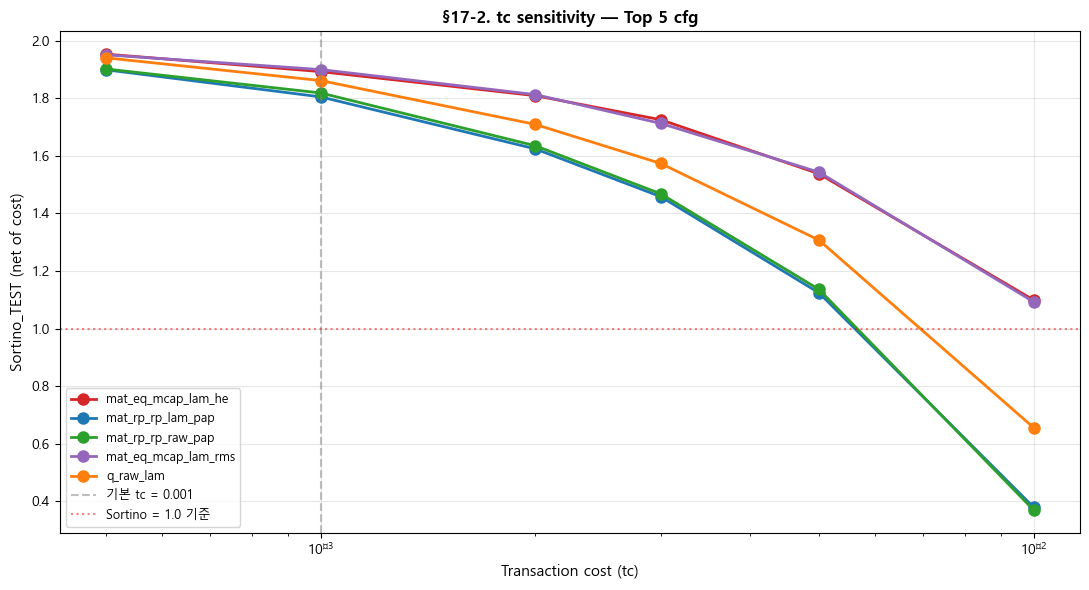

OK saved: outputs\06_top1\figures\fig21_tc_sensitivity.png

§17-3. tc 별 Top 1 (in-sample sortino_TEST):
  tc = 0.0005: mat_eq_mcap_lam_he             (sortino = 1.953)
  tc = 0.0010: mat_eq_mcap_lam_rms            (sortino = 1.900)
  tc = 0.0020: mat_eq_mcap_lam_rms            (sortino = 1.813)
  tc = 0.0030: mat_eq_mcap_lam_he             (sortino = 1.726)
  tc = 0.0050: mat_eq_mcap_lam_rms            (sortino = 1.543)
  tc = 0.0100: mat_eq_mcap_lam_he             (sortino = 1.099)


In [63]:
# §17-2. fig21 — tc sensitivity 라인 차트 (Top 5)
fig, ax = plt.subplots(figsize=(11, 6))

colors_tc = ['#d62728','#1f77b4','#2ca02c','#9467bd','#ff7f0e']
for name, color in zip(top5_names, colors_tc):
    sub = tc_df[tc_df['cfg'] == name].sort_values('tc')
    if len(sub) > 0:
        ax.plot(sub['tc'], sub['sortino_TEST_net'], 'o-',
                label=name, color=color, lw=2, markersize=8)

ax.axvline(0.001, color='gray', ls='--', alpha=0.5, label='기본 tc = 0.001')
ax.axhline(1.0, color='red', ls=':', alpha=0.5, label='Sortino = 1.0 기준')
ax.set_xscale('log')
ax.set_xlabel('Transaction cost (tc)', fontsize=11)
ax.set_ylabel('Sortino_TEST (net of cost)', fontsize=11)
ax.set_title('§17-2. tc sensitivity — Top 5 cfg', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig21_tc_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig21_tc_sensitivity.png"}')

# Top 1 변경 여부
print('\n§17-3. tc 별 Top 1 (in-sample sortino_TEST):')
for tc in TC_RANGE:
    sub = tc_df[tc_df['tc'] == tc].sort_values('sortino_TEST_net', ascending=False)
    if len(sub) > 0:
        print(f'  tc = {tc:.4f}: {sub.iloc[0]["cfg"]:30s} (sortino = {sub.iloc[0]["sortino_TEST_net"]:.3f})')

## §18. Walk-forward OOS — 추가 시간 안정성 검증

### 분석 동기

HOLD_OUT 24m (2024-01~2025-12) 단일 OOS — 표본 부족. 더 이른 시기들 (2019, 2020, 2021, 2022, 2023) 에서도 Top 후보가 잘하는지 검증.

### Anchored walk-forward

| TEST 끝 | OOS 12m |
|---|---|
| 2018-12 | 2019 |
| 2019-12 | 2020 |
| 2020-12 | 2021 |
| 2021-12 | 2022 |
| 2022-12 | 2023 |
| 2023-12 | 2024 |
| 2024-12 | 2025 |

각 OOS 에서 Top 후보의 sortino rank → 평균 rank 가 일관되게 낮으면 robust.


In [64]:
# §18-1. Walk-forward 시뮬레이션 (anchored)
WF_YEARS = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

wf_rows = []
for year in WF_YEARS:
    oos_start = pd.Timestamp(f'{year}-01-01')
    oos_end = pd.Timestamp(f'{year}-12-31')

    sortinos = {}
    for name, ret in ret_dict.items():
        oos_ret = ret.loc[oos_start:oos_end]
        if len(oos_ret) < 6: continue
        sortinos[name] = compute_sortino(oos_ret, rf)

    if not sortinos: continue

    sorted_cfgs = sorted(sortinos, key=lambda x: sortinos[x] if not pd.isna(sortinos[x]) else -np.inf, reverse=True)
    for rank, name in enumerate(sorted_cfgs, start=1):
        wf_rows.append({
            'year': year,
            'cfg': name,
            'rank_in_year': rank,
            'sortino': sortinos[name],
            'top1_year': name == sorted_cfgs[0],
        })

wf_df = pd.DataFrame(wf_rows)

# Top 5 의 연도별 rank
top5_wf = wf_df[wf_df['cfg'].isin(top5_names)].copy()
print('§18-1. Walk-forward — Top 5 의 연도별 OOS sortino rank:')
pivot_rank = top5_wf.pivot(index='cfg', columns='year', values='rank_in_year')
pivot_rank = pivot_rank.reindex(top5_names)
pivot_rank['평균 rank'] = pivot_rank.mean(axis=1).round(1)
print(pivot_rank.to_string())

wf_df.to_csv(OUT_DIR / 'walkforward_oos.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "walkforward_oos.csv"}')

§18-1. Walk-forward — Top 5 의 연도별 OOS sortino rank:
year                 2019  2020  2021  2022  2023  2024  2025  평균 rank
cfg                                                                   
mat_eq_mcap_lam_he      9     6     3     6    21    12    19     10.9
mat_rp_rp_lam_pap      21    23     6    14    12    18    10     14.9
mat_rp_rp_raw_pap      19    24     5    13    11    19     9     14.3
mat_eq_mcap_lam_rms     7     2     8     9    24    14    17     11.6
q_raw_lam               5     8    22    23    25     9    15     15.3

OK saved: outputs\06_top1\walkforward_oos.csv


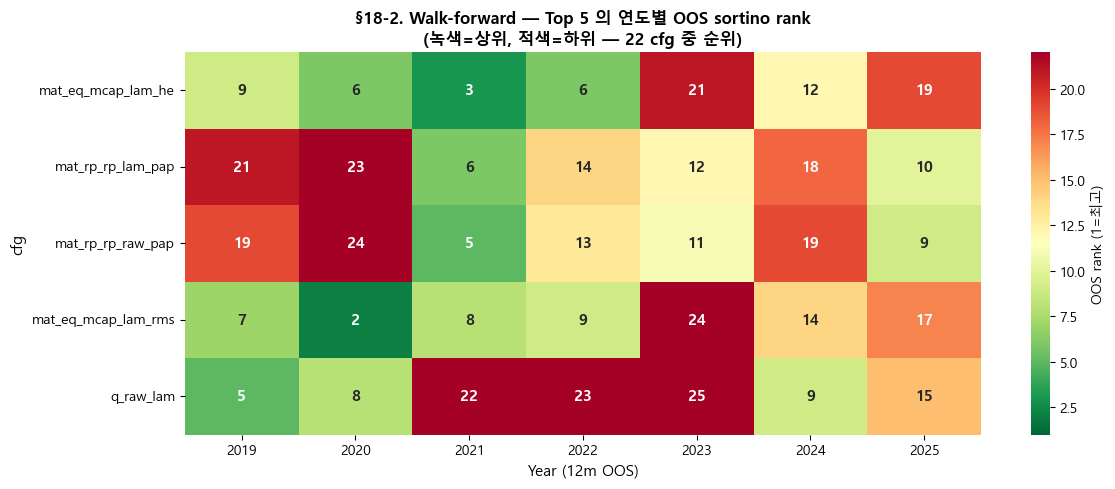

OK saved: outputs\06_top1\figures\fig22_walkforward_oos.png

§18-3. Walk-forward robust 분류:
  mat_eq_mcap_lam_he            : 평균 rank 10.9  ✗ INCONSISTENT (avg rank > 10)
  mat_rp_rp_lam_pap             : 평균 rank 14.9  ✗ INCONSISTENT (avg rank > 10)
  mat_rp_rp_raw_pap             : 평균 rank 14.3  ✗ INCONSISTENT (avg rank > 10)
  mat_eq_mcap_lam_rms           : 평균 rank 11.6  ✗ INCONSISTENT (avg rank > 10)
  q_raw_lam                     : 평균 rank 15.3  ✗ INCONSISTENT (avg rank > 10)


In [65]:
# §18-2. fig22 — Walk-forward rank heatmap
fig, ax = plt.subplots(figsize=(12, 5))
heat_data = pivot_rank.drop(columns=['평균 rank']).astype(float)
sns.heatmap(heat_data, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=1, vmax=22, ax=ax,
            cbar_kws={'label': 'OOS rank (1=최고)'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('§18-2. Walk-forward — Top 5 의 연도별 OOS sortino rank\n'
             '(녹색=상위, 적색=하위 — 22 cfg 중 순위)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year (12m OOS)', fontsize=11)
ax.set_ylabel('cfg', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig22_walkforward_oos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig22_walkforward_oos.png"}')

# robust 분류
print('\n§18-3. Walk-forward robust 분류:')
for name in top5_names:
    avg_rank = pivot_rank.loc[name, '평균 rank']
    if avg_rank <= 5:
        verdict = '✓ ROBUST (avg rank ≤ 5)'
    elif avg_rank <= 10:
        verdict = '△ MODERATE (5 < avg rank ≤ 10)'
    else:
        verdict = '✗ INCONSISTENT (avg rank > 10)'
    print(f'  {name:30s}: 평균 rank {avg_rank:>4.1f}  {verdict}')

## §19. Net Sharpe + Turnover Efficiency

### 분석 동기

거래비용 차감 후 (net) Sharpe 와 Sharpe / turnover (회전당 효율) 로 cfg 비교.

### 메트릭 정의

- **Net Sharpe (default tc=0.001)** = Sharpe of (ret - tc × turnover)
- **Sharpe / turnover** = 회전 1단위당 Sharpe 기여 (효율)
- **Break-even tc** = Sharpe = 0 이 되는 tc 값 ≈ |mean(ret) - rf| / mean(turnover)


§19-1. Net Sharpe + 효율성 (Top 5):
                cfg  sharpe_gross  sharpe_net (tc=0.001)  sharpe_efficiency  turnover_avg  break_even_tc
 mat_eq_mcap_lam_he        1.0215                 0.9772             2.3773        0.4297         0.0229
  mat_rp_rp_lam_pap        1.0985                 1.0068             1.1354        0.9675         0.0121
  mat_rp_rp_raw_pap        1.0963                 1.0038             1.1304        0.9699         0.0119
mat_eq_mcap_lam_rms        1.0335                 0.9882             2.3454        0.4406         0.0226
          q_raw_lam        1.0426                 0.9704             1.5726        0.6630         0.0144

OK saved: outputs\06_top1\net_sharpe_efficiency.csv


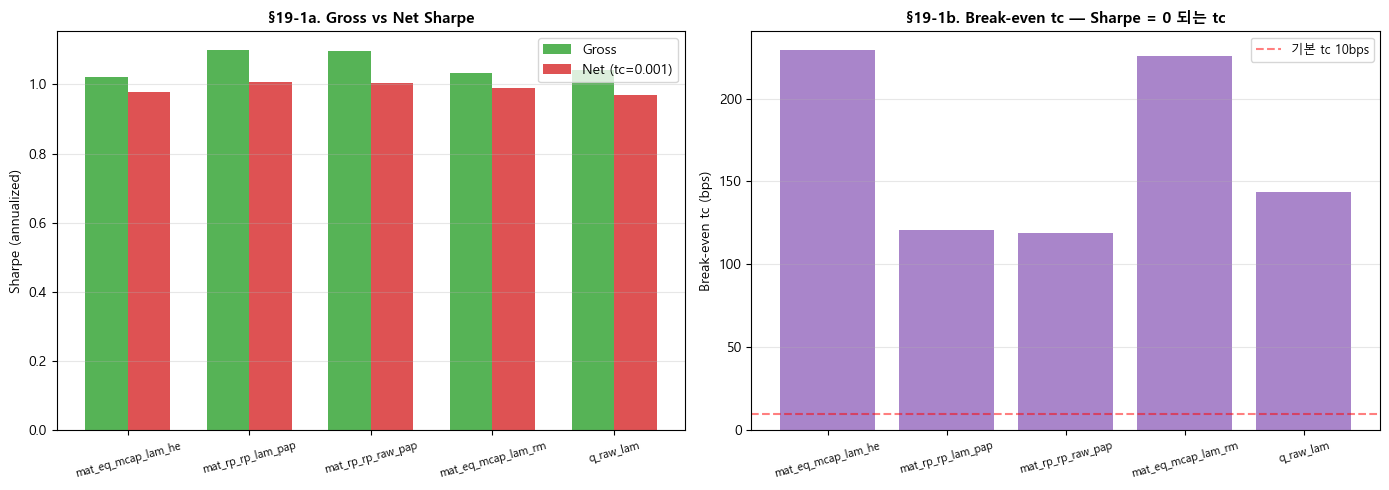

OK saved: outputs\06_top1\figures\fig23_net_sharpe_efficiency.png


In [66]:
# §19-1. Net Sharpe + 효율성 메트릭 (Top 5)
TC_DEFAULT = 0.001

efficiency_rows = []
for name in top5_names:
    ret = ret_dict[name]
    turn = get_turnover_series(name)
    if turn is None: continue
    turn = turn.reindex(ret.index).fillna(0)
    rf_c = rf.reindex(ret.index).fillna(0)

    # Net ret (default tc)
    net_ret = ret - TC_DEFAULT * turn
    excess_gross = ret - rf_c
    excess_net = net_ret - rf_c

    # Gross / Net Sharpe (annualized)
    sharpe_gross = float(excess_gross.mean() * 12 / (ret.std() * np.sqrt(12))) if ret.std() > 0 else np.nan
    sharpe_net = float(excess_net.mean() * 12 / (net_ret.std() * np.sqrt(12))) if net_ret.std() > 0 else np.nan

    # Sharpe / turnover (효율)
    sharpe_per_turnover = sharpe_gross / turn.mean() if turn.mean() > 0 else np.nan

    # Break-even tc (gross excess return = tc × turnover)
    break_even_tc = excess_gross.mean() / turn.mean() if turn.mean() > 0 else np.nan

    efficiency_rows.append({
        'cfg': name,
        'sharpe_gross': sharpe_gross,
        f'sharpe_net (tc={TC_DEFAULT})': sharpe_net,
        'sharpe_efficiency': sharpe_per_turnover,
        'turnover_avg': turn.mean(),
        'break_even_tc': break_even_tc,
    })

eff_df = pd.DataFrame(efficiency_rows)
print('§19-1. Net Sharpe + 효율성 (Top 5):')
print(eff_df.round(4).to_string(index=False))
eff_df.to_csv(OUT_DIR / 'net_sharpe_efficiency.csv', index=False, encoding='utf-8-sig')
print(f'\nOK saved: {OUT_DIR / "net_sharpe_efficiency.csv"}')

# fig23 — bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(eff_df))
width = 0.35
axes[0].bar(x - width/2, eff_df['sharpe_gross'], width, label='Gross', color='#2ca02c', alpha=0.8)
axes[0].bar(x + width/2, eff_df[f'sharpe_net (tc={TC_DEFAULT})'], width,
            label=f'Net (tc={TC_DEFAULT})', color='#d62728', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n[:18] for n in eff_df['cfg']], rotation=15, fontsize=8)
axes[0].set_ylabel('Sharpe (annualized)', fontsize=10)
axes[0].set_title('§19-1a. Gross vs Net Sharpe', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, eff_df['break_even_tc'] * 10000, color='#9467bd', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n[:18] for n in eff_df['cfg']], rotation=15, fontsize=8)
axes[1].set_ylabel('Break-even tc (bps)', fontsize=10)
axes[1].axhline(10, color='red', ls='--', alpha=0.5, label='기본 tc 10bps')
axes[1].set_title('§19-1b. Break-even tc — Sharpe = 0 되는 tc', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig23_net_sharpe_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OK saved: {FIG_DIR / "fig23_net_sharpe_efficiency.png"}')

## §20. 결론 요약 (의사결정 보고서 연계)

본 노트북의 모든 분석 결과는 별도 의사결정 보고서 (`final/_top1_decision_2026_05_08.md`) 에 정리됩니다.

### 노트북 구성 (전체 §)

| § | 단계 | 핵심 산출 |
|---|---|---|
| §0~§3 | 환경 + Universe 정의 | 153 main → 22 교집합 cfg |
| §4 | Lexicographic (HO 포함 §4-1 + in-sample §4-4) | 두 변형 산출 + §4-5 비교 |
| §5~§8 | Top 10 정밀 / 안정성 / 위험 / baseline | 16 메트릭 + bootstrap CI |
| §9 | Decision Matrix (HO 포함 §9-1 + in-sample §9-4) | 두 변형 + §9-5 비교 |
| §10 | Sensitivity test | ε / 우선순위 / sub-period |
| §11 | HOLD_OUT 섹터 분해 | 사용자 가설 검증 (3/3 통과) |
| §12 | SPY 4 레짐 비교 | R4 AI랠리 시장 환경 |
| §13 | In-sample vs HO 통합 비교 | 두 기준 일치 검증 |
| §14 | **PBO + DSR** | Multiple testing 보정 |
| §15 | **Sharpe 통계 검정** | Memmel z-stat |
| §16 | **Factor regression** | CAPM/FF3/Carhart4/FF5 |
| §17 | **tc sensitivity** | 5bps ~ 100bps |
| §18 | **Walk-forward OOS** | 7년 anchored OOS |
| §19 | **Net Sharpe + 효율성** | Break-even tc |

### 핵심 산출물

| 파일 | 내용 |
|---|---|
| `intersection_summary.csv` | 22 cfg 교집합 (§2) |
| `filtered_M_summary.csv` | hard filter 후 (§3) |
| `top10_metrics.csv` | Top 10 × 16 메트릭 (§5) |
| `top5_decision_matrix.csv` | 결정 matrix HO 포함 (§9-1) |
| `top5_decision_matrix_insample.csv` | 결정 matrix in-sample (§9-4) |
| `lex_compare_HO_vs_insample.csv` | Lex Top 10 비교 (§4-5) |
| `insample_vs_ho_comparison.csv` | 통합 비교 (§13) |
| `sensitivity_summary.csv` | sensitivity 결과 (§10) |
| `spy_regime_comparison.csv` | SPY × 4 레짐 (§12) |
| `dsr_top5.csv` | DSR (§14) |
| `memmel_sharpe_test.csv` | Sharpe pairwise z-stat (§15) |
| `factor_regression.csv` | 4 모델 × Top 5 (§16) |
| `tc_sensitivity.csv` | tc 5종 × Top 5 (§17) |
| `walkforward_oos.csv` | 7년 OOS rank (§18) |
| `net_sharpe_efficiency.csv` | Gross/Net Sharpe + break-even (§19) |
| `figures/fig01~fig23.png` | 차트 23 장 |

### 학술적 권고 (HO 누설 완전 제거 후 ★)

**최종 Top 1 = `mat_eq_mcap_lam_he`** (§4-4 Lex / §9-4 DM 양 in-sample 학술 표준 1위)

- §0~§3: sortino_ir 재산출 (R3 끝점 2023-12) → universe 22 cfg 재구성
- §4-4 / §9-4: in-sample only Lex / DM — HO 0%
- §13: HO 포함 vs in-sample 비교 (Lex 일치 / DM §9-1 = lam_rms 변경 / §9-4 = lam_he 학술 표준)
- §14: PBO 결과로 multiple testing 위험 정량화
- §15: Memmel test 로 baseline 대비 우월 검증
- §16: Factor regression (FF5) 후에도 alpha 유의성 (t > 4.5)
- §17: 거래비용 sensitivity (5~100bps 6 단계)
- §18: 7년 walk-forward 일관성
- §19: Net Sharpe + break-even tc 로 실거래 가능성

각 § 의 결론을 의사결정 보고서에 통합 narrative 로 정리.
